## Cell 1 — Dataset Loading & Initial Inspection

**Purpose:** Load the raw ICU dataset and establish baseline understanding before any processing.

**What it does:**
- Reads `Dataset.csv` into a pandas DataFrame
- Prints shape, column names, first 5 rows
- Calls `df.info()` for dtypes and non-null counts
- Reports missing values per column
- Shows target (`SepsisLabel`) class distribution

**Input:** `Dataset.csv` — PhysioNet 2019 sepsis challenge dataset

**Expected Output:**
- Shape: `(546123, 44)` — 546K hourly ICU records, 44 columns
- Target imbalance: ~97.83% negative, ~2.17% positive (45:1)
- Missing value hotspots: EtCO2 100%, most labs >80%, vitals 7–66%

**Why it matters:** Quantifies the class imbalance and missingness, which drive every downstream design decision.

In [1]:
import pandas as pd

df = pd.read_csv("Dataset.csv")

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["SepsisLabel"].value_counts())

Dataset Shape: (546123, 44)

Columns:
['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']

First 5 Rows:
   Unnamed: 0  Hour    HR  O2Sat  Temp    SBP   MAP   DBP  Resp  EtCO2  ...  \
0           0     0   NaN    NaN   NaN    NaN   NaN   NaN   NaN    NaN  ...   
1           1     1  65.0  100.0   NaN    NaN  72.0   NaN  16.5    NaN  ...   
2           2     2  78.0  100.0   NaN    NaN  42.5   NaN   NaN    NaN  ...   
3           3     3  73.0  100.0   NaN    NaN   NaN   NaN  17.0    NaN  ...   
4           4     4  70.0  100.0   NaN  129.0  74.0  69.0  14.0    NaN  ...   

   Fibrinog

## Cell 2 — Missing Value Report & Patient Count

**Purpose:** Produce a structured missing-value report and count unique patients.

**What it does:**
- Drops the stray `Unnamed: 0` index column
- Counts unique `Patient_ID` values
- Computes missing percentage per column, sorted descending

**Expected Output:**
- Unique patients: **14,057**
- ~27 columns have >80% missing values (all lab-related)
- Only ~16 columns have usable coverage

**Why it matters:** Identifies which columns must be dropped before modeling.

In [2]:
import pandas as pd
import numpy as np

# Make a copy
data = df.copy()

# 1. Remove unnecessary index column
data = data.drop(columns=["Unnamed: 0"], errors="ignore")

# 2. Check basic information
print("Shape after removing Unnamed column:", data.shape)

# 3. Check number of patients
print("\nTotal unique patients:", data["Patient_ID"].nunique())

# 4. Check missing value percentage
missing_percent = (data.isnull().sum() / len(data)) * 100

missing_report = pd.DataFrame({
    "Missing Values": data.isnull().sum(),
    "Missing Percentage": missing_percent
}).sort_values("Missing Percentage", ascending=False)

print("\nMissing Value Report:")
print(missing_report)

# 5. Target distribution
print("\nTarget Distribution:")
print(data["SepsisLabel"].value_counts())

print("\nTarget Percentage:")
print(data["SepsisLabel"].value_counts(normalize=True) * 100)

Shape after removing Unnamed column: (546123, 43)

Total unique patients: 14057

Missing Value Report:
                  Missing Values  Missing Percentage
EtCO2                     546123          100.000000
TroponinI                 545435           99.874021
Bilirubin_direct          545305           99.850217
Fibrinogen                541959           99.237534
Bilirubin_total           539405           98.769874
Alkalinephos              538173           98.544284
AST                       537944           98.502352
Lactate                   527440           96.578976
PTT                       519684           95.158783
SaO2                      519443           95.114654
Calcium                   518937           95.022001
Phosphate                 518517           94.945095
Platelets                 510532           93.482970
Creatinine                509911           93.369259
WBC                       505194           92.505534
Magnesium                 503732           92.237

## Cell 3 — Drop High-Missing Columns

**Purpose:** Remove columns with >80% missing values that cannot be reliably imputed.

**What it does:**
- Computes per-column missing fraction
- Drops every column exceeding 80% missing
- Prints the dropped columns and remaining shape

**Expected Output:**
- Dropped: `EtCO2, BaseExcess, HCO3, FiO2, pH, PaCO2, SaO2, AST, BUN, Alkalinephos, Calcium, Chloride, Creatinine, Bilirubin_direct, Glucose, Lactate, Magnesium, Phosphate, Potassium, Bilirubin_total, TroponinI, Hct, Hgb, PTT, WBC, Fibrinogen, Platelets`
- Remaining 16 columns: `Hour, HR, O2Sat, Temp, SBP, MAP, DBP, Resp, Age, Gender, Unit1, Unit2, HospAdmTime, ICULOS, SepsisLabel, Patient_ID`

**Why it matters:** Prevents unreliable imputation from injecting noise. Keeps only vitals + static context.

In [3]:
# Check columns that will be dropped (>80% missing values)

missing_percent = data.isnull().mean() * 100

high_missing_cols = missing_percent[missing_percent > 80].index.tolist()

print("Number of columns with >80% missing values:", len(high_missing_cols))

print("\nColumns to drop:")
for col in high_missing_cols:
    print(f"{col}: {missing_percent[col]:.2f}% missing")

# Drop those columns
data_clean = data.drop(columns=high_missing_cols)

print("\nOriginal shape:", data.shape)
print("Shape after dropping high-missing columns:", data_clean.shape)

print("\nRemaining columns:")
print(data_clean.columns.tolist())

Number of columns with >80% missing values: 27

Columns to drop:
EtCO2: 100.00% missing
BaseExcess: 89.66% missing
HCO3: 91.97% missing
FiO2: 85.98% missing
pH: 88.61% missing
PaCO2: 91.29% missing
SaO2: 95.11% missing
AST: 98.50% missing
BUN: 91.86% missing
Alkalinephos: 98.54% missing
Calcium: 95.02% missing
Chloride: 91.70% missing
Creatinine: 93.37% missing
Bilirubin_direct: 99.85% missing
Glucose: 87.86% missing
Lactate: 96.58% missing
Magnesium: 92.24% missing
Phosphate: 94.95% missing
Potassium: 89.19% missing
Bilirubin_total: 98.77% missing
TroponinI: 99.87% missing
Hct: 88.23% missing
Hgb: 91.20% missing
PTT: 95.16% missing
WBC: 92.51% missing
Fibrinogen: 99.24% missing
Platelets: 93.48% missing

Original shape: (546123, 43)
Shape after dropping high-missing columns: (546123, 16)

Remaining columns:
['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


## Cell 4 — Patient-Level Train/Test Split (First Version)

**Purpose:** Split patients (not rows) into train/test to prevent data leakage.

**What it does:**
- Aggregates one label per patient (max of SepsisLabel across the stay)
- Stratified 80/20 split of patient IDs
- Filters original rows by split
- Verifies zero patient overlap between sets

**Expected Output:**
- Train: 11,245 patients / 437,418 rows
- Test: 2,812 patients / 108,704 rows
- **Patient overlap: 0** ✅

**Why it matters:** A row-level split would leak the same patient's data across train and test — inflating metrics. Patient-level split is the correct methodology for ICU data.

In [4]:
from sklearn.model_selection import train_test_split

# Create one label per patient
# If a patient ever has SepsisLabel = 1, mark that patient as 1
patient_labels = (
    data_clean.groupby("Patient_ID")["SepsisLabel"]
    .max()
    .reset_index()
)

print("Total patients:", len(patient_labels))

print("\nPatient-level target distribution:")
print(patient_labels["SepsisLabel"].value_counts())

print("\nPatient-level target percentage:")
print(patient_labels["SepsisLabel"].value_counts(normalize=True) * 100)

# Split PATIENT IDs, not individual rows
train_patients, test_patients = train_test_split(
    patient_labels["Patient_ID"],
    test_size=0.20,
    random_state=42,
    stratify=patient_labels["SepsisLabel"]
)

# Create train and test datasets
train_data = data_clean[
    data_clean["Patient_ID"].isin(train_patients)
].copy()

test_data = data_clean[
    data_clean["Patient_ID"].isin(test_patients)
].copy()

# Check results
print("\n--- TRAIN DATA ---")
print("Rows:", train_data.shape[0])
print("Unique patients:", train_data["Patient_ID"].nunique())
print(train_data["SepsisLabel"].value_counts(normalize=True) * 100)

print("\n--- TEST DATA ---")
print("Rows:", test_data.shape[0])
print("Unique patients:", test_data["Patient_ID"].nunique())
print(test_data["SepsisLabel"].value_counts(normalize=True) * 100)

# Verify there is no patient overlap
overlap = set(train_data["Patient_ID"]).intersection(
    set(test_data["Patient_ID"])
)

print("\nPatient overlap between train and test:", len(overlap))

Total patients: 14057

Patient-level target distribution:
SepsisLabel
0.0    12818
1.0     1239
Name: count, dtype: int64

Patient-level target percentage:
SepsisLabel
0.0    91.185886
1.0     8.814114
Name: proportion, dtype: float64

--- TRAIN DATA ---
Rows: 437418
Unique patients: 11245
SepsisLabel
0.0    97.83388
1.0     2.16612
Name: proportion, dtype: float64

--- TEST DATA ---
Rows: 108704
Unique patients: 2812
SepsisLabel
0.0    97.815168
1.0     2.184832
Name: proportion, dtype: float64

Patient overlap between train and test: 0


## Cell 5 — Feature/Target Split & Median Imputation

**Purpose:** Separate features from target and impute missing values using training medians only.

**What it does:**
- Drops `SepsisLabel` and `Patient_ID` from X
- Computes medians from **training data only**
- Applies those medians to fill NaN in both train and test

**Expected Output:**
- X_train: `(437418, 14)`, X_test: `(108704, 14)`
- Zero remaining NaN after imputation

**Why it matters:** Computing medians from the full dataset would leak test statistics. Train-only imputation is standard practice.

In [5]:
# ============================================
# STEP: Separate Features and Target
# ============================================

# Patient_ID is used only for splitting.
# It must NOT be given to the ML model.

X_train = train_data.drop(
    columns=["SepsisLabel", "Patient_ID"]
).copy()

y_train = train_data["SepsisLabel"].copy()

X_test = test_data.drop(
    columns=["SepsisLabel", "Patient_ID"]
).copy()

y_test = test_data["SepsisLabel"].copy()


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


# ============================================
# Check remaining missing values
# ============================================

print("\nMissing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())


# ============================================
# Calculate medians ONLY from training data
# ============================================

train_medians = X_train.median(numeric_only=True)

print("\nTraining medians:")
print(train_medians)


# ============================================
# Apply training medians to both datasets
# ============================================

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)


# ============================================
# Verify missing values are removed
# ============================================

print("\nRemaining missing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nRemaining missing values in X_test:")
print(X_test.isnull().sum().sum())

X_train shape: (437418, 14)
y_train shape: (437418,)
X_test shape: (108704, 14)
y_test shape: (108704,)

Missing values in X_train:
Hour                0
HR              33798
O2Sat           52721
Temp           289301
SBP             66852
MAP             44468
DBP            209144
Resp            43030
Age                 0
Gender              0
Unit1          216882
Unit2          216882
HospAdmTime         0
ICULOS              0
dtype: int64

Missing values in X_test:
Hour               0
HR              8325
O2Sat          13083
Temp           72310
SBP            16351
MAP            11128
DBP            52308
Resp           10418
Age                0
Gender             0
Unit1          54532
Unit2          54532
HospAdmTime        0
ICULOS             0
dtype: int64

Training medians:
Hour            20.00
HR              84.00
O2Sat           98.00
Temp            37.06
SBP            119.00
MAP             77.00
DBP             58.50
Resp            18.00
Age             65

## Cell 6 — Random Forest Baseline (First Attempt)

**Purpose:** Train a simple Random Forest as a first baseline on raw features.

**What it does:**
- Instantiates `RandomForestClassifier(n_estimators=100, class_weight="balanced")`
- Fits on the 14 raw features (no engineering)

**Expected Output:** Model trained successfully.

**Why it matters:** Provides a low bar to beat — later we show engineered features + XGBoost significantly outperform.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ============================================
# Random Forest Baseline
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Training completed successfully.")

Training Random Forest...
Training completed successfully.


## Cell 7 — Random Forest Evaluation (First Attempt)

**Purpose:** Evaluate the RF baseline on raw features.

**What it does:**
- Predicts labels and probabilities on test set
- Computes accuracy, precision, recall, F1, ROC-AUC, PR-AUC
- Prints confusion matrix + classification report

**Expected Output:**
- Accuracy: 0.9753 (⚠️ misleading — dominated by majority class)
- **Recall: 2.44%** ❌ (misses 97.5% of sepsis cases)
- ROC-AUC: 0.7295, PR-AUC: 0.0707
- TP=58, FN=2,317

**Why it matters:** Demonstrates that raw features + RF is inadequate for this task — motivating feature engineering.

In [7]:
# ============================================
# Predictions
# ============================================

y_pred = rf_model.predict(X_test)

# Probability of Sepsis = 1
y_prob = rf_model.predict_proba(X_test)[:, 1]


# ============================================
# Evaluation Metrics
# ============================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)


print("====================================")
print("RANDOM FOREST BASELINE RESULTS")
print("====================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")


# ============================================
# Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ============================================
# Detailed Classification Report
# ============================================

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Sepsis", "Sepsis"],
    zero_division=0
))

RANDOM FOREST BASELINE RESULTS
Accuracy : 0.9753
Precision: 0.1349
Recall   : 0.0244
F1 Score : 0.0414
ROC-AUC  : 0.7295
PR-AUC   : 0.0707

Confusion Matrix:
[[105957    372]
 [  2317     58]]

Classification Report:
              precision    recall  f1-score   support

  Non-Sepsis       0.98      1.00      0.99    106329
      Sepsis       0.13      0.02      0.04      2375

    accuracy                           0.98    108704
   macro avg       0.56      0.51      0.51    108704
weighted avg       0.96      0.98      0.97    108704



## Cell 8 — RF Threshold Analysis

**Purpose:** Test whether lowering the decision threshold rescues the RF baseline.

**What it does:**
- Sweeps thresholds 0.01 to 0.50
- Reports precision, recall, F1 at each threshold

**Expected Output:**
- Even at threshold 0.01, precision stays below 3%
- Recall improves at the cost of precision, F1 remains poor

**Why it matters:** Shows that threshold tuning alone cannot fix a model that isn't learning the right signal.

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.40, 0.30, 0.20, 0.15, 0.10, 0.05, 0.02, 0.01]

print("==============================================")
print("THRESHOLD ANALYSIS")
print("==============================================")

print(
    f"{'Threshold':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
)

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    print(
        f"{threshold:<12.2f}"
        f"{precision:<12.4f}"
        f"{recall:<12.4f}"
        f"{f1:<12.4f}"
    )

THRESHOLD ANALYSIS
Threshold   Precision   Recall      F1          
0.50        0.1345      0.0269      0.0449      
0.40        0.1341      0.0703      0.0923      
0.30        0.1204      0.1444      0.1313      
0.20        0.1057      0.2463      0.1479      
0.15        0.0970      0.3204      0.1490      
0.10        0.0785      0.4118      0.1319      
0.05        0.0502      0.5794      0.0925      
0.02        0.0341      0.7971      0.0654      
0.01        0.0285      0.8977      0.0553      


## Cell 9 — Import XGBoost (Failed Attempt)

**Purpose:** Attempt to import XGBoost to use as a stronger baseline.

**What it does:** `import xgboost as xgb`

**Expected Output:** `ModuleNotFoundError: No module named 'xgboost'`

**Why it matters:** Logs the missing dependency — fixed in the next cell.

In [9]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)


ModuleNotFoundError: No module named 'xgboost'

## Cell 10 — Install XGBoost

**Purpose:** Install XGBoost into the current environment.

**What it does:** Runs `%pip install xgboost`

**Expected Output:** XGBoost 3.4.1 installed successfully.

**Why it matters:** Required dependency for gradient boosting models.

In [10]:
%pip install xgboost


   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 1.0/48.9 MB 3.8 MB/s eta 0:00:13
   - -------------------------------------- 1.8/48.9 MB 3.6 MB/s eta 0:00:13
   -- ------------------------------------- 2.6/48.9 MB 3.9 MB/s eta 0:00:12
   -- ------------------------------------- 3.4/48.9 MB 3.7 MB/s eta 0:00:13
   --- ------------------------------------ 4.5/48.9 MB 3.8 MB/s eta 0:00:12
   ---- ----------------------------------- 5.2/48.9 MB 3.9 MB/s eta 0:00:12
   ----- ---------------------------------- 6.3/48.9 MB 4.0 MB/s eta 0:00:11
   ----- ---------------------------------- 7.1/48.9 MB 4.0 MB/s eta 0:00:11
   ------ --------------------------------- 8.1/48.9 MB 4.1 MB/s eta 0:00:10
   ------- -------------------------------- 9.2/48.9 MB 4.2 MB/s eta 0:00:10
   -------- ------------------------------- 10.2/48.9 MB 4.3 MB/s eta 0:00:10
   -------- 

## Cell 11 — Verify XGBoost Installation

**Purpose:** Confirm XGBoost is available.

**What it does:** Imports and prints version.

**Expected Output:** `XGBoost version: 3.4.1`

**Why it matters:** Sanity check before training.

In [11]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


## Cell 12 — XGBoost Baseline (First Attempt)

**Purpose:** Train XGBoost on raw 14 features with class imbalance weighting.

**What it does:**
- Computes `scale_pos_weight = negatives / positives` (~45.17)
- Fits `XGBClassifier(n_estimators=300, max_depth=6, scale_pos_weight=45.17, eval_metric="aucpr")`

**Expected Output:** Model trained successfully.

**Why it matters:** XGBoost is expected to outperform RF — confirmed in the next cell.

In [12]:
from xgboost import XGBClassifier

# ============================================
# Calculate class imbalance ratio
# ============================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Non-Sepsis samples:", negative_count)
print("Sepsis samples:", positive_count)
print("Scale Pos Weight:", scale_pos_weight)


# ============================================
# XGBoost Model
# ============================================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="aucpr",

    random_state=42,
    n_jobs=-1
)

print("\nTraining XGBoost...")

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed successfully.")

Non-Sepsis samples: 427943
Sepsis samples: 9475
Scale Pos Weight: 45.16548812664907

Training XGBoost...
XGBoost training completed successfully.


## Cell 13 — XGBoost Evaluation (First Attempt)

**Purpose:** Evaluate the raw-feature XGBoost baseline.

**What it does:** Same metrics as RF evaluation.

**Expected Output:**
- Accuracy: 0.8387
- **Recall: 50.2%**, precision: 6.8%
- ROC-AUC: 0.7463, PR-AUC: 0.0806
- TP=1,193, FP=16,351, FN=1,182

**Why it matters:** XGBoost beats RF significantly on recall — but still far from clinically useful.

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ============================================
# XGBoost Predictions
# ============================================

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]


# ============================================
# Metrics
# ============================================

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
xgb_recall = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, zero_division=0)

xgb_roc_auc = roc_auc_score(y_test, xgb_prob)
xgb_pr_auc = average_precision_score(y_test, xgb_prob)


print("==============================================")
print("XGBOOST BASELINE RESULTS")
print("==============================================")

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")


# ============================================
# Confusion Matrix
# ============================================

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))


# ============================================
# Classification Report
# ============================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["Non-Sepsis", "Sepsis"],
        zero_division=0
    )
)

XGBOOST BASELINE RESULTS
Accuracy : 0.8387
Precision: 0.0680
Recall   : 0.5023
F1 Score : 0.1198
ROC-AUC  : 0.7463
PR-AUC   : 0.0806

Confusion Matrix:
[[89978 16351]
 [ 1182  1193]]

Classification Report:
              precision    recall  f1-score   support

  Non-Sepsis       0.99      0.85      0.91    106329
      Sepsis       0.07      0.50      0.12      2375

    accuracy                           0.84    108704
   macro avg       0.53      0.67      0.52    108704
weighted avg       0.97      0.84      0.89    108704



## Cell 14 — XGBoost Threshold Analysis

**Purpose:** Sweep decision thresholds on XGBoost predictions.

**What it does:** Tests thresholds 0.01 to 0.50.

**Expected Output:**
- At threshold 0.02, recall hits 100% but precision drops to 2.2%
- Indicates the model is barely better than random at low thresholds

**Why it matters:** Confirms raw features are insufficient.

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.40, 0.30, 0.20, 0.15, 0.10, 0.05, 0.02, 0.01]

print("==============================================")
print("XGBOOST THRESHOLD ANALYSIS")
print("==============================================")

print(
    f"{'Threshold':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
)

for threshold in thresholds:

    xgb_pred_threshold = (xgb_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        xgb_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        xgb_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        xgb_pred_threshold,
        zero_division=0
    )

    print(
        f"{threshold:<12.2f}"
        f"{precision:<12.4f}"
        f"{recall:<12.4f}"
        f"{f1:<12.4f}"
    )

XGBOOST THRESHOLD ANALYSIS
Threshold   Precision   Recall      F1          
0.50        0.0680      0.5023      0.1198      
0.40        0.0509      0.6084      0.0939      
0.30        0.0396      0.7343      0.0751      
0.20        0.0318      0.8539      0.0613      
0.15        0.0285      0.9082      0.0554      
0.10        0.0255      0.9621      0.0497      
0.05        0.0230      0.9966      0.0450      
0.02        0.0222      1.0000      0.0433      
0.01        0.0219      1.0000      0.0430      


## Cell 15 — Create 6h / 12h Future Sepsis Targets

**Purpose:** Reframe the problem from "is septic now" to "will be septic soon" — the core of an early warning system.

**What it does:**
- Sorts by Patient_ID, Hour
- For each row at time `t`: `Target_6h = 1` if SepsisLabel=1 in next 6 hours
- Similarly for `Target_12h` (next 12 hours)

**Expected Output:**
- Target_6h positive rate: **3.07%** (16,776 rows)
- Target_12h positive rate: **4.04%** (22,055 rows)
- Final shape: `(546123, 18)`

**Why it matters:** Matches the synopsis — predict 6–12 hour horizon, not current state.

In [15]:
# ============================================
# STEP: Create Future 6-Hour and 12-Hour Targets
# ============================================

import pandas as pd
import numpy as np

# Work on cleaned dataset
future_data = data_clean.copy()

# --------------------------------------------
# 1. Sort patient-wise and time-wise
# --------------------------------------------

future_data = future_data.sort_values(
    ["Patient_ID", "Hour"]
).reset_index(drop=True)

print("Dataset sorted successfully.")
print("Shape:", future_data.shape)


# --------------------------------------------
# 2. Create future sepsis targets
# --------------------------------------------

def create_future_target(group, horizon):
    """
    For each current hour t:
    target = 1 if SepsisLabel becomes 1
    during the following 'horizon' hours.
    """

    labels = group["SepsisLabel"].values
    hours = group["Hour"].values

    target = np.zeros(len(group), dtype=np.float32)

    for i in range(len(group)):

        current_hour = hours[i]

        # Future records only
        future_mask = (
            (hours > current_hour) &
            (hours <= current_hour + horizon)
        )

        if future_mask.any():
            target[i] = labels[future_mask].max()

    return pd.Series(
        target,
        index=group.index
    )


# --------------------------------------------
# 3. Generate 6-hour target
# --------------------------------------------

print("\nCreating 6-hour future target...")

future_data["Target_6h"] = (
    future_data
    .groupby("Patient_ID", group_keys=False)
    .apply(
        lambda group: create_future_target(group, 6),
        include_groups=False
    )
    .reset_index(level=0, drop=True)
)


# --------------------------------------------
# 4. Generate 12-hour target
# --------------------------------------------

print("Creating 12-hour future target...")

future_data["Target_12h"] = (
    future_data
    .groupby("Patient_ID", group_keys=False)
    .apply(
        lambda group: create_future_target(group, 12),
        include_groups=False
    )
    .reset_index(level=0, drop=True)
)


# --------------------------------------------
# 5. Check target distribution
# --------------------------------------------

print("\n============================================")
print("6-HOUR TARGET DISTRIBUTION")
print("============================================")

print(future_data["Target_6h"].value_counts())

print("\n6-Hour Target Percentage:")
print(
    future_data["Target_6h"]
    .value_counts(normalize=True) * 100
)


print("\n============================================")
print("12-HOUR TARGET DISTRIBUTION")
print("============================================")

print(future_data["Target_12h"].value_counts())

print("\n12-Hour Target Percentage:")
print(
    future_data["Target_12h"]
    .value_counts(normalize=True) * 100
)


# --------------------------------------------
# 6. Check final columns
# --------------------------------------------

print("\nFinal columns:")
print(future_data.columns.tolist())

print("\nFinal shape:")
print(future_data.shape)

Dataset sorted successfully.
Shape: (546123, 16)

Creating 6-hour future target...
Creating 12-hour future target...

6-HOUR TARGET DISTRIBUTION
Target_6h
0.0    529346
1.0     16776
Name: count, dtype: int64

6-Hour Target Percentage:
Target_6h
0.0    96.928159
1.0     3.071841
Name: proportion, dtype: float64

12-HOUR TARGET DISTRIBUTION
Target_12h
0.0    524067
1.0     22055
Name: count, dtype: int64

12-Hour Target Percentage:
Target_12h
0.0    95.961525
1.0     4.038475
Name: proportion, dtype: float64

Final columns:
['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID', 'Target_6h', 'Target_12h']

Final shape:
(546123, 18)


## Cell 16 — Create 70 Temporal Features

**Purpose:** Engineer time-series features capturing trends, not just snapshots.

**What it does:** For 7 vitals (HR, O2Sat, Temp, SBP, MAP, DBP, Resp):
- **Lags**: `_lag1, _lag3, _lag6` — value N hours ago
- **Changes**: `_change1h, _change3h, _change6h` — delta vs N hours ago
- **Rolling stats (3h window)**: `_mean3h, _std3h, _min3h, _max3h`

**Expected Output:**
- 70 new columns added → shape `(546123, 88)`
- Heavy missingness in new features (Temp lags ~88% missing)

**Why it matters:** Implements synopsis §4.2 (rate of change, rolling averages, variability). A rising respiratory rate is more informative than a single snapshot.

In [16]:
# ============================================
# STEP: Create Historical Trend Features
# ============================================

trend_data = future_data.copy()

# Make sure patient/time order is correct
trend_data = trend_data.sort_values(
    ["Patient_ID", "Hour"]
).reset_index(drop=True)

# --------------------------------------------
# Vital sign columns
# --------------------------------------------

vital_features = [
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "DBP",
    "Resp"
]

# --------------------------------------------
# Create lag features
# --------------------------------------------

for feature in vital_features:

    # Previous hour
    trend_data[f"{feature}_lag1"] = (
        trend_data.groupby("Patient_ID")[feature].shift(1)
    )

    # 3 hours ago
    trend_data[f"{feature}_lag3"] = (
        trend_data.groupby("Patient_ID")[feature].shift(3)
    )

    # 6 hours ago
    trend_data[f"{feature}_lag6"] = (
        trend_data.groupby("Patient_ID")[feature].shift(6)
    )


# --------------------------------------------
# Create change/trend features
# --------------------------------------------

for feature in vital_features:

    trend_data[f"{feature}_change1h"] = (
        trend_data[feature] -
        trend_data[f"{feature}_lag1"]
    )

    trend_data[f"{feature}_change3h"] = (
        trend_data[feature] -
        trend_data[f"{feature}_lag3"]
    )

    trend_data[f"{feature}_change6h"] = (
        trend_data[feature] -
        trend_data[f"{feature}_lag6"]
    )


# --------------------------------------------
# Rolling statistics
# --------------------------------------------

for feature in vital_features:

    grouped = trend_data.groupby("Patient_ID")[feature]

    trend_data[f"{feature}_mean3h"] = (
        grouped.transform(
            lambda x: x.rolling(3, min_periods=1).mean()
        )
    )

    trend_data[f"{feature}_std3h"] = (
        grouped.transform(
            lambda x: x.rolling(3, min_periods=1).std()
        )
    )

    trend_data[f"{feature}_min3h"] = (
        grouped.transform(
            lambda x: x.rolling(3, min_periods=1).min()
        )
    )

    trend_data[f"{feature}_max3h"] = (
        grouped.transform(
            lambda x: x.rolling(3, min_periods=1).max()
        )
    )


# --------------------------------------------
# Check result
# --------------------------------------------

print("Original shape:", future_data.shape)
print("New shape:", trend_data.shape)

print("\nNumber of new features:",
      trend_data.shape[1] - future_data.shape[1])

print("\nNew columns:")
new_columns = [
    col for col in trend_data.columns
    if col not in future_data.columns
]

print(new_columns)

print("\nMissing values in newly created features:")

print(
    trend_data[new_columns]
    .isnull()
    .sum()
    .sort_values(ascending=False)
    .head(30)
)

Original shape: (546123, 18)
New shape: (546123, 88)

Number of new features: 70

New columns:
['HR_lag1', 'HR_lag3', 'HR_lag6', 'O2Sat_lag1', 'O2Sat_lag3', 'O2Sat_lag6', 'Temp_lag1', 'Temp_lag3', 'Temp_lag6', 'SBP_lag1', 'SBP_lag3', 'SBP_lag6', 'MAP_lag1', 'MAP_lag3', 'MAP_lag6', 'DBP_lag1', 'DBP_lag3', 'DBP_lag6', 'Resp_lag1', 'Resp_lag3', 'Resp_lag6', 'HR_change1h', 'HR_change3h', 'HR_change6h', 'O2Sat_change1h', 'O2Sat_change3h', 'O2Sat_change6h', 'Temp_change1h', 'Temp_change3h', 'Temp_change6h', 'SBP_change1h', 'SBP_change3h', 'SBP_change6h', 'MAP_change1h', 'MAP_change3h', 'MAP_change6h', 'DBP_change1h', 'DBP_change3h', 'DBP_change6h', 'Resp_change1h', 'Resp_change3h', 'Resp_change6h', 'HR_mean3h', 'HR_std3h', 'HR_min3h', 'HR_max3h', 'O2Sat_mean3h', 'O2Sat_std3h', 'O2Sat_min3h', 'O2Sat_max3h', 'Temp_mean3h', 'Temp_std3h', 'Temp_min3h', 'Temp_max3h', 'SBP_mean3h', 'SBP_std3h', 'SBP_min3h', 'SBP_max3h', 'MAP_mean3h', 'MAP_std3h', 'MAP_min3h', 'MAP_max3h', 'DBP_mean3h', 'DBP_std3h'

## Cell 17 — First Patient-Wise 3-Way Split

**Purpose:** Split patients into train/validation/test without leakage.

**What it does:**
- Aggregates patient-level 6h labels
- Splits patients 80/20 (dev/test), then dev 80/20 (train/val)
- Verifies zero overlap between all three sets

**Expected Output:**
- Train: 8,996 patients / 349,260 rows
- Validation: 2,249 patients / 88,158 rows
- Test: 2,812 patients / 108,704 rows
- Zero overlap ✅

**Why it matters:** Validation set needed for threshold tuning without touching test.

In [17]:
# ============================================
# STEP: Patient-wise Train / Validation / Test
# ============================================

from sklearn.model_selection import train_test_split

# --------------------------------------------
# Create one label per patient
# --------------------------------------------

patient_labels_future = (
    trend_data
    .groupby("Patient_ID")["Target_6h"]
    .max()
    .reset_index()
)

print("Total patients:", len(patient_labels_future))

print("\nPatient-level 6h target:")
print(patient_labels_future["Target_6h"].value_counts())

print("\nPatient-level 6h target percentage:")
print(
    patient_labels_future["Target_6h"]
    .value_counts(normalize=True) * 100
)


# ============================================
# 1. First split: 80% development / 20% test
# ============================================

dev_patients, test_patients = train_test_split(
    patient_labels_future["Patient_ID"],
    test_size=0.20,
    random_state=42,
    stratify=patient_labels_future["Target_6h"]
)


# ============================================
# 2. Split development into train/validation
# ============================================

dev_labels = patient_labels_future[
    patient_labels_future["Patient_ID"].isin(dev_patients)
]

train_patients, val_patients = train_test_split(
    dev_labels["Patient_ID"],
    test_size=0.20,
    random_state=42,
    stratify=dev_labels["Target_6h"]
)


# ============================================
# 3. Create datasets
# ============================================

train_future = trend_data[
    trend_data["Patient_ID"].isin(train_patients)
].copy()

val_future = trend_data[
    trend_data["Patient_ID"].isin(val_patients)
].copy()

test_future = trend_data[
    trend_data["Patient_ID"].isin(test_patients)
].copy()


# ============================================
# 4. Display sizes
# ============================================

print("\n============================================")
print("TRAIN")
print("============================================")

print("Rows:", len(train_future))
print("Patients:", train_future["Patient_ID"].nunique())

print("\n6h Target:")
print(
    train_future["Target_6h"]
    .value_counts(normalize=True) * 100
)


print("\n============================================")
print("VALIDATION")
print("============================================")

print("Rows:", len(val_future))
print("Patients:", val_future["Patient_ID"].nunique())

print("\n6h Target:")
print(
    val_future["Target_6h"]
    .value_counts(normalize=True) * 100
)


print("\n============================================")
print("TEST")
print("============================================")

print("Rows:", len(test_future))
print("Patients:", test_future["Patient_ID"].nunique())

print("\n6h Target:")
print(
    test_future["Target_6h"]
    .value_counts(normalize=True) * 100
)


# ============================================
# 5. Check patient overlap
# ============================================

train_set = set(train_patients)
val_set = set(val_patients)
test_set = set(test_patients)

print("\n============================================")
print("PATIENT OVERLAP CHECK")
print("============================================")

print("Train ∩ Validation:",
      len(train_set.intersection(val_set)))

print("Train ∩ Test:",
      len(train_set.intersection(test_set)))

print("Validation ∩ Test:",
      len(val_set.intersection(test_set)))

Total patients: 14057

Patient-level 6h target:
Target_6h
0.0    12818
1.0     1239
Name: count, dtype: int64

Patient-level 6h target percentage:
Target_6h
0.0    91.185886
1.0     8.814114
Name: proportion, dtype: float64

TRAIN
Rows: 349260
Patients: 8996

6h Target:
Target_6h
0.0    96.935521
1.0     3.064479
Name: proportion, dtype: float64

VALIDATION
Rows: 88158
Patients: 2249

6h Target:
Target_6h
0.0    96.937317
1.0     3.062683
Name: proportion, dtype: float64

TEST
Rows: 108704
Patients: 2812

6h Target:
Target_6h
0.0    96.897078
1.0     3.102922
Name: proportion, dtype: float64

PATIENT OVERLAP CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


## Cell 18 — Feature Matrix Preparation

**Purpose:** Build X matrices with the 84 engineered features.

**What it does:**
- Drops `Patient_ID, SepsisLabel, Target_6h, Target_12h`
- Confirms 84 features present

**Expected Output:**
- X_train: `(349260, 84)`
- X_validation: `(88158, 84)`
- X_test: `(108704, 84)`

**Why it matters:** Locks in the feature schema.

In [18]:
# ============================================
# STEP: Prepare Features and Targets
# 6-Hour Future Prediction
# ============================================

# Columns that must NOT enter the model
drop_columns = [
    "Patient_ID",
    "SepsisLabel",
    "Target_6h",
    "Target_12h"
]

# --------------------------------------------
# Training
# --------------------------------------------

X_train_future = train_future.drop(
    columns=drop_columns,
    errors="ignore"
)

y_train_future = train_future["Target_6h"]


# --------------------------------------------
# Validation
# --------------------------------------------

X_val_future = val_future.drop(
    columns=drop_columns,
    errors="ignore"
)

y_val_future = val_future["Target_6h"]


# --------------------------------------------
# Test
# --------------------------------------------

X_test_future = test_future.drop(
    columns=drop_columns,
    errors="ignore"
)

y_test_future = test_future["Target_6h"]


# --------------------------------------------
# Check shapes
# --------------------------------------------

print("============================================")
print("FEATURE MATRIX SHAPES")
print("============================================")

print("X_train:", X_train_future.shape)
print("y_train:", y_train_future.shape)

print("X_validation:", X_val_future.shape)
print("y_validation:", y_val_future.shape)

print("X_test:", X_test_future.shape)
print("y_test:", y_test_future.shape)


print("\nNumber of features:", X_train_future.shape[1])

print("\nFeatures:")
print(X_train_future.columns.tolist())

FEATURE MATRIX SHAPES
X_train: (349260, 84)
y_train: (349260,)
X_validation: (88158, 84)
y_validation: (88158,)
X_test: (108704, 84)
y_test: (108704,)

Number of features: 84

Features:
['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'HR_lag1', 'HR_lag3', 'HR_lag6', 'O2Sat_lag1', 'O2Sat_lag3', 'O2Sat_lag6', 'Temp_lag1', 'Temp_lag3', 'Temp_lag6', 'SBP_lag1', 'SBP_lag3', 'SBP_lag6', 'MAP_lag1', 'MAP_lag3', 'MAP_lag6', 'DBP_lag1', 'DBP_lag3', 'DBP_lag6', 'Resp_lag1', 'Resp_lag3', 'Resp_lag6', 'HR_change1h', 'HR_change3h', 'HR_change6h', 'O2Sat_change1h', 'O2Sat_change3h', 'O2Sat_change6h', 'Temp_change1h', 'Temp_change3h', 'Temp_change6h', 'SBP_change1h', 'SBP_change3h', 'SBP_change6h', 'MAP_change1h', 'MAP_change3h', 'MAP_change6h', 'DBP_change1h', 'DBP_change3h', 'DBP_change6h', 'Resp_change1h', 'Resp_change3h', 'Resp_change6h', 'HR_mean3h', 'HR_std3h', 'HR_min3h', 'HR_max3h', 'O2Sat_mean3h', 'O2Sat_std3h', 'O2Sat_

## Cell 19 — Median Imputation (Train-Only)

**Purpose:** Fill remaining NaN with training medians.

**What it does:**
- Fits `SimpleImputer(strategy="median")` on train only
- Transforms validation and test

**Expected Output:** Zero NaN in all three sets.

**Why it matters:** Prevents leakage from validation/test statistics.

In [19]:
# ============================================
# STEP: Training-Only Median Imputation
# ============================================

from sklearn.impute import SimpleImputer

# Create imputer
imputer_future = SimpleImputer(strategy="median")

# --------------------------------------------
# FIT ONLY ON TRAINING DATA
# --------------------------------------------

X_train_future = pd.DataFrame(
    imputer_future.fit_transform(X_train_future),
    columns=X_train_future.columns,
    index=X_train_future.index
)

# --------------------------------------------
# TRANSFORM VALIDATION
# --------------------------------------------

X_val_future = pd.DataFrame(
    imputer_future.transform(X_val_future),
    columns=X_val_future.columns,
    index=X_val_future.index
)

# --------------------------------------------
# TRANSFORM TEST
# --------------------------------------------

X_test_future = pd.DataFrame(
    imputer_future.transform(X_test_future),
    columns=X_test_future.columns,
    index=X_test_future.index
)


# --------------------------------------------
# Verify
# --------------------------------------------

print("Remaining missing values:")

print(
    "Train:",
    X_train_future.isnull().sum().sum()
)

print(
    "Validation:",
    X_val_future.isnull().sum().sum()
)

print(
    "Test:",
    X_test_future.isnull().sum().sum()
)

Remaining missing values:
Train: 0
Validation: 0
Test: 0


## Cell 20 — Compute 6h Class Weight

**Purpose:** Compute the positive class weight for XGBoost.

**What it does:** `scale_pos_weight = negatives / positives`

**Expected Output:**
- Non-Sepsis: 338,557
- Future Sepsis: 10,703
- **scale_pos_weight = 31.63**

**Why it matters:** Tells XGBoost to weight positive examples more heavily to counter class imbalance.

In [20]:
# ============================================
# 6-HOUR XGBOOST
# Class Imbalance Calculation
# ============================================

negative_count = (y_train_future == 0).sum()
positive_count = (y_train_future == 1).sum()

scale_pos_weight_6h = negative_count / positive_count

print("6-Hour Training Target")
print("----------------------------")
print("Non-Sepsis:", negative_count)
print("Future Sepsis:", positive_count)
print("Scale Pos Weight:", scale_pos_weight_6h)

6-Hour Training Target
----------------------------
Non-Sepsis: 338557
Future Sepsis: 10703
Scale Pos Weight: 31.63197234420256


## Cell 21 — Train First 6h XGBoost

**Purpose:** Train the first XGBoost on the 84-feature set for 6h horizon.

**What it does:**
- `XGBClassifier(n_estimators=500, max_depth=6, scale_pos_weight=31.63)`
- Monitors validation AUC-PR per iteration

**Expected Output:**
- Train AUC-PR climbs toward 0.60
- Validation AUC-PR plateaus ~0.16 (overfitting visible)

**Why it matters:** First sign that 500 estimators + depth 6 overfit. Motivates regularization in Cell 31.

In [21]:
from xgboost import XGBClassifier

# ============================================
# 6-HOUR FUTURE SEPSIS XGBOOST
# ============================================

xgb_6h = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight_6h,

    objective="binary:logistic",
    eval_metric="aucpr",

    random_state=42,
    n_jobs=-1
)

print("Training 6-hour XGBoost...")

xgb_6h.fit(
    X_train_future,
    y_train_future,

    eval_set=[
        (X_train_future, y_train_future),
        (X_val_future, y_val_future)
    ],

    verbose=True
)

print("\n6-hour XGBoost training completed.")

Training 6-hour XGBoost...
[0]	validation_0-aucpr:0.15250	validation_1-aucpr:0.13689
[1]	validation_0-aucpr:0.15791	validation_1-aucpr:0.13598
[2]	validation_0-aucpr:0.16193	validation_1-aucpr:0.13808
[3]	validation_0-aucpr:0.16885	validation_1-aucpr:0.14655
[4]	validation_0-aucpr:0.17370	validation_1-aucpr:0.15109
[5]	validation_0-aucpr:0.17469	validation_1-aucpr:0.15238
[6]	validation_0-aucpr:0.17543	validation_1-aucpr:0.15258
[7]	validation_0-aucpr:0.17739	validation_1-aucpr:0.15288
[8]	validation_0-aucpr:0.17874	validation_1-aucpr:0.15346
[9]	validation_0-aucpr:0.18084	validation_1-aucpr:0.15470
[10]	validation_0-aucpr:0.18023	validation_1-aucpr:0.15334
[11]	validation_0-aucpr:0.18269	validation_1-aucpr:0.15412
[12]	validation_0-aucpr:0.18388	validation_1-aucpr:0.15573
[13]	validation_0-aucpr:0.18515	validation_1-aucpr:0.15399
[14]	validation_0-aucpr:0.18614	validation_1-aucpr:0.15376
[15]	validation_0-aucpr:0.18678	validation_1-aucpr:0.15470
[16]	validation_0-aucpr:0.18944	validat

## Cell 22 — Evaluate 6h XGBoost (Validation)

**Purpose:** Metrics on the validation set for the first 6h model.

**What it does:** Predicts, thresholds at 0.5, computes metrics.

**Expected Output:**
- Accuracy: 0.8808
- Precision: 12.4%, **Recall: 47.8%**, F1: 0.197
- ROC-AUC: 0.7755, PR-AUC: 0.1568

**Why it matters:** First indication the model has learned real signal (AUROC 0.78 > RF baseline).

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ============================================
# VALIDATION PREDICTION
# ============================================

val_prob_6h = xgb_6h.predict_proba(X_val_future)[:, 1]

val_pred_6h = (val_prob_6h >= 0.50).astype(int)


# ============================================
# METRICS
# ============================================

print("============================================")
print("6-HOUR XGBOOST - VALIDATION RESULTS")
print("============================================")

print(f"Accuracy : {accuracy_score(y_val_future, val_pred_6h):.4f}")

print(f"Precision: {precision_score(y_val_future, val_pred_6h, zero_division=0):.4f}")

print(f"Recall   : {recall_score(y_val_future, val_pred_6h, zero_division=0):.4f}")

print(f"F1 Score : {f1_score(y_val_future, val_pred_6h, zero_division=0):.4f}")

print(f"ROC-AUC  : {roc_auc_score(y_val_future, val_prob_6h):.4f}")

print(f"PR-AUC   : {average_precision_score(y_val_future, val_prob_6h):.4f}")


print("\nConfusion Matrix:")
print(confusion_matrix(y_val_future, val_pred_6h))


print("\nClassification Report:")
print(
    classification_report(
        y_val_future,
        val_pred_6h,
        target_names=["No Future Sepsis", "Future Sepsis"],
        zero_division=0
    )
)

6-HOUR XGBOOST - VALIDATION RESULTS
Accuracy : 0.8808
Precision: 0.1242
Recall   : 0.4778
F1 Score : 0.1972
ROC-AUC  : 0.7755
PR-AUC   : 0.1568

Confusion Matrix:
[[76362  9096]
 [ 1410  1290]]

Classification Report:
                  precision    recall  f1-score   support

No Future Sepsis       0.98      0.89      0.94     85458
   Future Sepsis       0.12      0.48      0.20      2700

        accuracy                           0.88     88158
       macro avg       0.55      0.69      0.57     88158
    weighted avg       0.96      0.88      0.91     88158



## Cell 23 — 6h Validation Threshold Analysis

**Purpose:** Find the threshold maximizing F1 on validation.

**What it does:** Sweeps thresholds 0.05–0.50, picks best F1.

**Expected Output:** Best threshold: 0.5, F1: 0.197

**Why it matters:** Locks in a threshold for test evaluation.

In [23]:
thresholds = [0.50, 0.40, 0.30, 0.25, 0.20, 0.15, 0.10, 0.05]

print("============================================")
print("6-HOUR VALIDATION THRESHOLD ANALYSIS")
print("============================================")

print(
    f"{'Threshold':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
)

threshold_results_6h = []

for threshold in thresholds:

    pred = (val_prob_6h >= threshold).astype(int)

    precision = precision_score(
        y_val_future, pred, zero_division=0
    )

    recall = recall_score(
        y_val_future, pred, zero_division=0
    )

    f1 = f1_score(
        y_val_future, pred, zero_division=0
    )

    threshold_results_6h.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    print(
        f"{threshold:<12.2f}"
        f"{precision:<12.4f}"
        f"{recall:<12.4f}"
        f"{f1:<12.4f}"
    )


best_threshold_6h = max(
    threshold_results_6h,
    key=lambda x: x["f1"]
)

print("\n============================================")
print("BEST 6-HOUR THRESHOLD")
print("============================================")

print("Threshold:", best_threshold_6h["threshold"])
print("Precision:", round(best_threshold_6h["precision"], 4))
print("Recall   :", round(best_threshold_6h["recall"], 4))
print("F1       :", round(best_threshold_6h["f1"], 4))

6-HOUR VALIDATION THRESHOLD ANALYSIS
Threshold   Precision   Recall      F1          
0.50        0.1242      0.4778      0.1972      
0.40        0.0948      0.5674      0.1625      
0.30        0.0737      0.6826      0.1330      
0.25        0.0647      0.7385      0.1190      
0.20        0.0563      0.7967      0.1052      
0.15        0.0492      0.8652      0.0930      
0.10        0.0413      0.9152      0.0791      
0.05        0.0343      0.9604      0.0663      

BEST 6-HOUR THRESHOLD
Threshold: 0.5
Precision: 0.1242
Recall   : 0.4778
F1       : 0.1972


## Cell 24 — Final 6h Test Evaluation (First Attempt)

**Purpose:** Evaluate the first 6h model on the test set.

**What it does:** Predicts with validation-locked threshold.

**Expected Output — DISASTER:**
- ROC-AUC: **0.5122** (near random)
- Precision: 2.3%, Recall: 13.9%

**Why it matters:** Exposes a critical bug — the model was trained on `Target_6h` but tested against `SepsisLabel` (the wrong target). Fix in Cell 25.

In [24]:
# ============================================
# FINAL 6-HOUR TEST EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Locked threshold from validation
FINAL_THRESHOLD_6H = best_threshold_6h["threshold"]

print("Locked 6-hour threshold:", FINAL_THRESHOLD_6H)

# --------------------------------------------
# Test probability
# --------------------------------------------

test_prob_6h = xgb_6h.predict_proba(
    X_test_future
)[:, 1]

# --------------------------------------------
# Test prediction
# --------------------------------------------

test_pred_6h = (
    test_prob_6h >= FINAL_THRESHOLD_6H
).astype(int)


# --------------------------------------------
# Final metrics
# --------------------------------------------

print("\n============================================")
print("FINAL 6-HOUR XGBOOST TEST RESULTS")
print("============================================")

print(
    f"Accuracy : "
    f"{accuracy_score(y_test, test_pred_6h):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test, test_pred_6h, zero_division=0):.4f}"
)

print(
    f"Recall   : "
    f"{recall_score(y_test, test_pred_6h, zero_division=0):.4f}"
)

print(
    f"F1 Score : "
    f"{f1_score(y_test, test_pred_6h, zero_division=0):.4f}"
)

print(
    f"ROC-AUC  : "
    f"{roc_auc_score(y_test, test_prob_6h):.4f}"
)

print(
    f"PR-AUC   : "
    f"{average_precision_score(y_test, test_prob_6h):.4f}"
)


print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        test_pred_6h
    )
)


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_pred_6h,
        target_names=[
            "No Future Sepsis",
            "Future Sepsis"
        ],
        zero_division=0
    )
)

Locked 6-hour threshold: 0.5

FINAL 6-HOUR XGBOOST TEST RESULTS
Accuracy : 0.8547
Precision: 0.0234
Recall   : 0.1385
F1 Score : 0.0400
ROC-AUC  : 0.5122
PR-AUC   : 0.0222

Confusion Matrix:
[[92575 13754]
 [ 2046   329]]

Classification Report:
                  precision    recall  f1-score   support

No Future Sepsis       0.98      0.87      0.92    106329
   Future Sepsis       0.02      0.14      0.04      2375

        accuracy                           0.85    108704
       macro avg       0.50      0.50      0.48    108704
    weighted avg       0.96      0.85      0.90    108704



## Cell 25 — Correct 6h Target (Major Fix)

**Purpose:** Rebuild future targets correctly — **only on currently non-septic rows**.

**What it does:**
- Rebuilds `Target_6h` / `Target_12h` on the original data
- **Filters out rows where SepsisLabel=1** (a currently septic row is not a prediction target)

**Expected Output:**
- Corrected shape: `(534272, 18)`
- Target_6h positive rate: **1.15%** (6,165 rows)
- Target_12h positive rate: **2.14%** (11,444 rows)

**Why it matters:** Early warning systems predict *future* sepsis for *currently stable* patients. Rows where the patient is already septic are not predictions — they're observations.

In [25]:
# ============================================
# CORRECTED 6-HOUR FUTURE TARGET
# Only currently NON-SEPTIC patients/rows
# ============================================

corrected_data = data_clean.copy()

# Sort by patient and ICU hour
corrected_data = corrected_data.sort_values(
    ["Patient_ID", "Hour"]
).reset_index(drop=True)


def create_future_target_correct(group, horizon):

    labels = group["SepsisLabel"].to_numpy()
    hours = group["Hour"].to_numpy()

    target = np.zeros(len(group), dtype=np.int8)

    for i in range(len(group)):

        current_hour = hours[i]

        # If currently septic, this row is NOT an early-warning sample
        if labels[i] == 1:
            continue

        # Look only into the future
        future_mask = (
            (hours > current_hour) &
            (hours <= current_hour + horizon)
        )

        if future_mask.any():

            # Future sepsis occurrence
            target[i] = labels[future_mask].max()

    return pd.Series(target, index=group.index)


# Create corrected targets
corrected_data["Target_6h"] = (
    corrected_data
    .groupby("Patient_ID", group_keys=False)
    .apply(
        lambda g: create_future_target_correct(g, 6),
        include_groups=False
    )
    .reset_index(level=0, drop=True)
)

corrected_data["Target_12h"] = (
    corrected_data
    .groupby("Patient_ID", group_keys=False)
    .apply(
        lambda g: create_future_target_correct(g, 12),
        include_groups=False
    )
    .reset_index(level=0, drop=True)
)


# --------------------------------------------
# Keep only currently non-septic rows
# --------------------------------------------

corrected_data = corrected_data[
    corrected_data["SepsisLabel"] == 0
].copy()


# --------------------------------------------
# Check results
# --------------------------------------------

print("============================================")
print("CORRECTED DATASET")
print("============================================")

print("Shape:", corrected_data.shape)

print("\nCurrent SepsisLabel:")
print(corrected_data["SepsisLabel"].value_counts())

print("\n6-Hour Target:")
print(corrected_data["Target_6h"].value_counts())

print("\n6-Hour Target Percentage:")
print(
    corrected_data["Target_6h"]
    .value_counts(normalize=True) * 100
)

print("\n12-Hour Target:")
print(corrected_data["Target_12h"].value_counts())

print("\n12-Hour Target Percentage:")
print(
    corrected_data["Target_12h"]
    .value_counts(normalize=True) * 100
)

CORRECTED DATASET
Shape: (534272, 18)

Current SepsisLabel:
SepsisLabel
0.0    534272
Name: count, dtype: int64

6-Hour Target:
Target_6h
0.0    528107
1.0      6165
Name: count, dtype: int64

6-Hour Target Percentage:
Target_6h
0.0    98.846093
1.0     1.153907
Name: proportion, dtype: float64

12-Hour Target:
Target_12h
0.0    522828
1.0     11444
Name: count, dtype: int64

12-Hour Target Percentage:
Target_12h
0.0    97.85802
1.0     2.14198
Name: proportion, dtype: float64


## Cell 26 — Rebuild Trend Features on Corrected Data

**Purpose:** Recreate all 70 temporal features on the corrected (non-septic-only) dataset.

**What it does:** Same lag/change/rolling logic as Cell 16.

**Expected Output:**
- Shape: `(534272, 88)`
- 70 new features regenerated

**Why it matters:** The feature pipeline must run on the corrected dataset.

In [26]:
# ============================================
# CORRECTED HISTORICAL TREND FEATURES
# ============================================

corrected_trend = corrected_data.copy()

# Sort chronologically within each patient
corrected_trend = corrected_trend.sort_values(
    ["Patient_ID", "Hour"]
).reset_index(drop=True)


# --------------------------------------------
# Vital signs
# --------------------------------------------

vital_features = [
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "DBP",
    "Resp"
]


# --------------------------------------------
# Lag features
# --------------------------------------------

for feature in vital_features:

    corrected_trend[f"{feature}_lag1"] = (
        corrected_trend.groupby("Patient_ID")[feature].shift(1)
    )

    corrected_trend[f"{feature}_lag3"] = (
        corrected_trend.groupby("Patient_ID")[feature].shift(3)
    )

    corrected_trend[f"{feature}_lag6"] = (
        corrected_trend.groupby("Patient_ID")[feature].shift(6)
    )


# --------------------------------------------
# Change features
# --------------------------------------------

for feature in vital_features:

    corrected_trend[f"{feature}_change1h"] = (
        corrected_trend[feature] -
        corrected_trend[f"{feature}_lag1"]
    )

    corrected_trend[f"{feature}_change3h"] = (
        corrected_trend[feature] -
        corrected_trend[f"{feature}_lag3"]
    )

    corrected_trend[f"{feature}_change6h"] = (
        corrected_trend[feature] -
        corrected_trend[f"{feature}_lag6"]
    )


# --------------------------------------------
# Rolling statistics
# --------------------------------------------

for feature in vital_features:

    grouped = corrected_trend.groupby("Patient_ID")[feature]

    corrected_trend[f"{feature}_mean3h"] = (
        grouped.transform(
            lambda x: x.rolling(3, min_periods=1).mean()
        )
    )

    corrected_trend[f"{feature}_std3h"] = (
        grouped.transform(
            lambda x: x.rolling(3, min_periods=1).std()
        )
    )

    corrected_trend[f"{feature}_min3h"] = (
        grouped.transform(
            lambda x: x.rolling(3, min_periods=1).min()
        )
    )

    corrected_trend[f"{feature}_max3h"] = (
        grouped.transform(
            lambda x: x.rolling(3, min_periods=1).max()
        )
    )


# --------------------------------------------
# Check
# --------------------------------------------

print("============================================")
print("CORRECTED TREND DATA")
print("============================================")

print("Original corrected shape:",
      corrected_data.shape)

print("New shape:",
      corrected_trend.shape)

print("Number of new features:",
      corrected_trend.shape[1] -
      corrected_data.shape[1])

print("\nCurrent SepsisLabel distribution:")
print(corrected_trend["SepsisLabel"].value_counts())

print("\n6h target:")
print(corrected_trend["Target_6h"].value_counts())

print("\n12h target:")
print(corrected_trend["Target_12h"].value_counts())

CORRECTED TREND DATA
Original corrected shape: (534272, 18)
New shape: (534272, 88)
Number of new features: 70

Current SepsisLabel distribution:
SepsisLabel
0.0    534272
Name: count, dtype: int64

6h target:
Target_6h
0.0    528107
1.0      6165
Name: count, dtype: int64

12h target:
Target_12h
0.0    522828
1.0     11444
Name: count, dtype: int64


## Cell 27 — Corrected Patient-Wise Split

**Purpose:** Redo the 80/10/10 patient split on corrected data.

**What it does:** Same splitting logic, correct dataset.

**Expected Output:**
- Train: 8,908 patients / 343,261 rows
- Validation: 2,228 patients / 86,397 rows
- Test: 2,784 patients / 104,614 rows
- Zero overlap ✅

**Why it matters:** Fresh, correct splits for the corrected dataset.

In [27]:
# ============================================
# CORRECTED PATIENT-WISE SPLIT
# ============================================

from sklearn.model_selection import train_test_split

# --------------------------------------------
# One label per patient for stratification
# --------------------------------------------

patient_labels_corrected = (
    corrected_trend
    .groupby("Patient_ID")
    .agg(
        Target_6h=("Target_6h", "max"),
        Target_12h=("Target_12h", "max")
    )
    .reset_index()
)

print("Total patients:",
      len(patient_labels_corrected))

print("\nPatient-level 6h distribution:")
print(
    patient_labels_corrected["Target_6h"]
    .value_counts()
)

print("\nPatient-level 12h distribution:")
print(
    patient_labels_corrected["Target_12h"]
    .value_counts()
)


# ============================================
# FIRST SPLIT
# 80% Development / 20% Test
# ============================================

dev_patients, test_patients = train_test_split(
    patient_labels_corrected["Patient_ID"],
    test_size=0.20,
    random_state=42,
    stratify=patient_labels_corrected["Target_6h"]
)


# ============================================
# SECOND SPLIT
# Development → 80% Train / 20% Validation
# ============================================

dev_labels = patient_labels_corrected[
    patient_labels_corrected["Patient_ID"].isin(dev_patients)
]

train_patients, val_patients = train_test_split(
    dev_labels["Patient_ID"],
    test_size=0.20,
    random_state=42,
    stratify=dev_labels["Target_6h"]
)


# ============================================
# CREATE DATASETS
# ============================================

corrected_train = corrected_trend[
    corrected_trend["Patient_ID"].isin(train_patients)
].copy()

corrected_val = corrected_trend[
    corrected_trend["Patient_ID"].isin(val_patients)
].copy()

corrected_test = corrected_trend[
    corrected_trend["Patient_ID"].isin(test_patients)
].copy()


# ============================================
# REPORT FUNCTION
# ============================================

def print_split_info(name, dataset):

    print("\n============================================")
    print(name)
    print("============================================")

    print("Rows:", len(dataset))
    print("Patients:", dataset["Patient_ID"].nunique())

    print("\n6h target:")
    print(
        dataset["Target_6h"]
        .value_counts(normalize=True)
        * 100
    )

    print("\n12h target:")
    print(
        dataset["Target_12h"]
        .value_counts(normalize=True)
        * 100
    )


print_split_info("TRAIN", corrected_train)
print_split_info("VALIDATION", corrected_val)
print_split_info("TEST", corrected_test)


# ============================================
# PATIENT OVERLAP CHECK
# ============================================

train_set = set(train_patients)
val_set = set(val_patients)
test_set = set(test_patients)

print("\n============================================")
print("PATIENT OVERLAP CHECK")
print("============================================")

print(
    "Train ∩ Validation:",
    len(train_set.intersection(val_set))
)

print(
    "Train ∩ Test:",
    len(train_set.intersection(test_set))
)

print(
    "Validation ∩ Test:",
    len(val_set.intersection(test_set))
)

Total patients: 13920

Patient-level 6h distribution:
Target_6h
0.0    12818
1.0     1102
Name: count, dtype: int64

Patient-level 12h distribution:
Target_12h
0.0    12818
1.0     1102
Name: count, dtype: int64

TRAIN
Rows: 343261
Patients: 8908

6h target:
Target_6h
0.0    98.852768
1.0     1.147232
Name: proportion, dtype: float64

12h target:
Target_12h
0.0    97.872173
1.0     2.127827
Name: proportion, dtype: float64

VALIDATION
Rows: 86397
Patients: 2228

6h target:
Target_6h
0.0    98.863386
1.0     1.136614
Name: proportion, dtype: float64

12h target:
Target_12h
0.0    97.908492
1.0     2.091508
Name: proportion, dtype: float64

TEST
Rows: 104614
Patients: 2784

6h target:
Target_6h
0.0    98.809911
1.0     1.190089
Name: proportion, dtype: float64

12h target:
Target_12h
0.0    97.769897
1.0     2.230103
Name: proportion, dtype: float64

PATIENT OVERLAP CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


## Cell 28 — 6h Feature Matrices & Imputation

**Purpose:** Build clean 6h matrices on corrected data.

**What it does:**
- Drops target/ID columns
- Median imputation (fit on train only)
- Computes `scale_pos_weight`

**Expected Output:**
- X_train_6h: `(343261, 84)`, positive rate: 1.15%
- `scale_pos_weight = 86.17`
- Zero missing values

**Why it matters:** Higher scale_pos_weight (86 vs 32 before) because corrected target has fewer positives.

In [28]:
# ============================================
# 6-HOUR MODEL FEATURE PREPARATION
# ============================================

from sklearn.impute import SimpleImputer

# --------------------------------------------
# Columns NOT used as model features
# --------------------------------------------

drop_cols = [
    "Patient_ID",
    "SepsisLabel",
    "Target_6h",
    "Target_12h"
]

# --------------------------------------------
# Create X / y
# --------------------------------------------

X_train_6h = corrected_train.drop(
    columns=drop_cols,
    errors="ignore"
)

y_train_6h = corrected_train["Target_6h"].astype(int)

X_val_6h = corrected_val.drop(
    columns=drop_cols,
    errors="ignore"
)

y_val_6h = corrected_val["Target_6h"].astype(int)

X_test_6h = corrected_test.drop(
    columns=drop_cols,
    errors="ignore"
)

y_test_6h = corrected_test["Target_6h"].astype(int)


# ============================================
# TRAIN-ONLY MEDIAN IMPUTATION
# ============================================

imputer_6h = SimpleImputer(strategy="median")

X_train_6h = pd.DataFrame(
    imputer_6h.fit_transform(X_train_6h),
    columns=X_train_6h.columns,
    index=X_train_6h.index
)

X_val_6h = pd.DataFrame(
    imputer_6h.transform(X_val_6h),
    columns=X_val_6h.columns,
    index=X_val_6h.index
)

X_test_6h = pd.DataFrame(
    imputer_6h.transform(X_test_6h),
    columns=X_test_6h.columns,
    index=X_test_6h.index
)


# ============================================
# CHECK
# ============================================

print("============================================")
print("6-HOUR FEATURE MATRICES")
print("============================================")

print("X_train:", X_train_6h.shape)
print("y_train:", y_train_6h.shape)

print("X_validation:", X_val_6h.shape)
print("y_validation:", y_val_6h.shape)

print("X_test:", X_test_6h.shape)
print("y_test:", y_test_6h.shape)

print("\nNumber of features:", X_train_6h.shape[1])

print("\nRemaining missing values:")
print(
    "Train:",
    X_train_6h.isnull().sum().sum()
)

print(
    "Validation:",
    X_val_6h.isnull().sum().sum()
)

print(
    "Test:",
    X_test_6h.isnull().sum().sum()
)


# ============================================
# CLASS BALANCE
# ============================================

negative = (y_train_6h == 0).sum()
positive = (y_train_6h == 1).sum()

scale_pos_weight_6h = negative / positive

print("\n============================================")
print("6-HOUR CLASS BALANCE")
print("============================================")

print("Non-Sepsis:", negative)
print("Future Sepsis:", positive)

print(
    "Positive percentage:",
    round(
        positive / len(y_train_6h) * 100,
        4
    ),
    "%"
)

print(
    "Scale Pos Weight:",
    round(scale_pos_weight_6h, 4)
)

6-HOUR FEATURE MATRICES
X_train: (343261, 84)
y_train: (343261,)
X_validation: (86397, 84)
y_validation: (86397,)
X_test: (104614, 84)
y_test: (104614,)

Number of features: 84

Remaining missing values:
Train: 0
Validation: 0
Test: 0

6-HOUR CLASS BALANCE
Non-Sepsis: 339323
Future Sepsis: 3938
Positive percentage: 1.1472 %
Scale Pos Weight: 86.1663


## Cell 29 — Train Corrected 6h XGBoost

**Purpose:** Train on corrected data.

**What it does:**
- `XGBClassifier(n_estimators=500, max_depth=5, scale_pos_weight=86.17)`

**Expected Output:**
- Train AUC-PR: ~0.37
- Val AUC-PR plateaus ~0.07

**Why it matters:** Still overfitting — motivates regularization in Cell 31.

In [29]:
from xgboost import XGBClassifier

# ============================================
# CORRECTED 6-HOUR XGBOOST
# ============================================

xgb_corrected_6h = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight_6h,

    objective="binary:logistic",
    eval_metric="aucpr",

    random_state=42,
    n_jobs=-1
)

print("============================================")
print("TRAINING CORRECTED 6-HOUR XGBOOST")
print("============================================")

xgb_corrected_6h.fit(
    X_train_6h,
    y_train_6h,

    eval_set=[
        (X_train_6h, y_train_6h),
        (X_val_6h, y_val_6h)
    ],

    verbose=True
)

print("\nTraining completed successfully.")

TRAINING CORRECTED 6-HOUR XGBOOST
[0]	validation_0-aucpr:0.05479	validation_1-aucpr:0.06373
[1]	validation_0-aucpr:0.05729	validation_1-aucpr:0.06339
[2]	validation_0-aucpr:0.06304	validation_1-aucpr:0.06999
[3]	validation_0-aucpr:0.06643	validation_1-aucpr:0.06648
[4]	validation_0-aucpr:0.06799	validation_1-aucpr:0.06760
[5]	validation_0-aucpr:0.07040	validation_1-aucpr:0.06808
[6]	validation_0-aucpr:0.07012	validation_1-aucpr:0.06838
[7]	validation_0-aucpr:0.07334	validation_1-aucpr:0.07151
[8]	validation_0-aucpr:0.07250	validation_1-aucpr:0.07128
[9]	validation_0-aucpr:0.07344	validation_1-aucpr:0.07242
[10]	validation_0-aucpr:0.07381	validation_1-aucpr:0.07262
[11]	validation_0-aucpr:0.07437	validation_1-aucpr:0.07316
[12]	validation_0-aucpr:0.07500	validation_1-aucpr:0.07297
[13]	validation_0-aucpr:0.07533	validation_1-aucpr:0.07317
[14]	validation_0-aucpr:0.07515	validation_1-aucpr:0.07280
[15]	validation_0-aucpr:0.07564	validation_1-aucpr:0.07268
[16]	validation_0-aucpr:0.07581	

## Cell 30 — Corrected 6h Validation Threshold Analysis

**Purpose:** Find optimal threshold.

**What it does:** Sweeps thresholds, reports precision/recall/F1.

**Expected Output:**
- Best F1 at threshold **0.7** (F1=0.143)
- **ROC-AUC: 0.7999** ✅, PR-AUC: 0.0634

**Why it matters:** ROC-AUC near 0.80 shows the corrected pipeline works.

In [30]:
# ============================================
# CORRECTED 6H - VALIDATION EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Validation probabilities
val_prob_corrected_6h = xgb_corrected_6h.predict_proba(
    X_val_6h
)[:, 1]

# --------------------------------------------
# Find best threshold based on F1
# --------------------------------------------

thresholds = [
    0.90, 0.80, 0.70, 0.60, 0.50,
    0.40, 0.30, 0.20, 0.15, 0.10,
    0.05, 0.02, 0.01
]

results = []

print("============================================")
print("CORRECTED 6H VALIDATION THRESHOLD ANALYSIS")
print("============================================")

print(
    f"{'Threshold':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
)

for threshold in thresholds:

    pred = (
        val_prob_corrected_6h >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_6h,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val_6h,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val_6h,
        pred,
        zero_division=0
    )

    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    print(
        f"{threshold:<12.2f}"
        f"{precision:<12.4f}"
        f"{recall:<12.4f}"
        f"{f1:<12.4f}"
    )


# --------------------------------------------
# Best F1 threshold
# --------------------------------------------

best_6h = max(
    results,
    key=lambda x: x["f1"]
)

print("\n============================================")
print("BEST VALIDATION THRESHOLD")
print("============================================")

print("Threshold :", best_6h["threshold"])
print("Precision :", round(best_6h["precision"], 4))
print("Recall    :", round(best_6h["recall"], 4))
print("F1        :", round(best_6h["f1"], 4))


# --------------------------------------------
# Threshold-independent metrics
# --------------------------------------------

print("\n============================================")
print("THRESHOLD-INDEPENDENT METRICS")
print("============================================")

print(
    "ROC-AUC :",
    round(
        roc_auc_score(
            y_val_6h,
            val_prob_corrected_6h
        ),
        4
    )
)

print(
    "PR-AUC  :",
    round(
        average_precision_score(
            y_val_6h,
            val_prob_corrected_6h
        ),
        4
    )
)

CORRECTED 6H VALIDATION THRESHOLD ANALYSIS
Threshold   Precision   Recall      F1          
0.90        0.1150      0.0601      0.0789      
0.80        0.1031      0.2240      0.1412      
0.70        0.0913      0.3340      0.1434      
0.60        0.0770      0.4379      0.1310      
0.50        0.0588      0.5367      0.1060      
0.40        0.0431      0.6222      0.0806      
0.30        0.0311      0.7016      0.0596      
0.20        0.0231      0.8106      0.0450      
0.15        0.0195      0.8646      0.0381      
0.10        0.0162      0.9104      0.0318      
0.05        0.0135      0.9674      0.0266      
0.02        0.0119      0.9898      0.0236      
0.01        0.0115      0.9969      0.0228      

BEST VALIDATION THRESHOLD
Threshold : 0.7
Precision : 0.0913
Recall    : 0.334
F1        : 0.1434

THRESHOLD-INDEPENDENT METRICS
ROC-AUC : 0.7999
PR-AUC  : 0.0634


## Cell 31 — Regularized 6h XGBoost (Early Stopping)

**Purpose:** Reduce overfitting with regularization and early stopping.

**What it does:**
- Adds `max_depth=3, learning_rate=0.03, min_child_weight=5, gamma=0.1, reg_alpha=0.1, reg_lambda=5.0`
- `early_stopping_rounds=50`

**Expected Output:**
- **Best iteration: 92**
- **Best validation PR-AUC: 0.0767** (up from 0.0634)

**Why it matters:** Regularization improves generalization and reduces training time.

In [31]:
# ============================================
# REGULARIZED 6-HOUR XGBOOST
# ============================================

from xgboost import XGBClassifier

xgb_final_6h = XGBClassifier(
    n_estimators=1000,

    max_depth=3,
    learning_rate=0.03,

    min_child_weight=5,
    gamma=0.1,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=5.0,

    scale_pos_weight=scale_pos_weight_6h,

    objective="binary:logistic",
    eval_metric="aucpr",

    random_state=42,
    n_jobs=-1,

    early_stopping_rounds=50
)

print("============================================")
print("TRAINING REGULARIZED 6H XGBOOST")
print("============================================")

xgb_final_6h.fit(
    X_train_6h,
    y_train_6h,

    eval_set=[
        (X_val_6h, y_val_6h)
    ],

    verbose=25
)

print("\n============================================")
print("TRAINING COMPLETE")
print("============================================")

print(
    "Best iteration:",
    xgb_final_6h.best_iteration
)

print(
    "Best validation PR-AUC:",
    xgb_final_6h.best_score
)

TRAINING REGULARIZED 6H XGBOOST
[0]	validation_0-aucpr:0.06036
[25]	validation_0-aucpr:0.06826
[50]	validation_0-aucpr:0.06642
[75]	validation_0-aucpr:0.07221
[100]	validation_0-aucpr:0.07425
[125]	validation_0-aucpr:0.07322
[142]	validation_0-aucpr:0.07189

TRAINING COMPLETE
Best iteration: 92
Best validation PR-AUC: 0.07669323633273493


## Cell 32 — Final 6h Validation Threshold Analysis

**Purpose:** Threshold tuning on the regularized model.

**What it does:** Sweeps thresholds, picks best F1.

**Expected Output:**
- Best threshold: **0.8**
- **ROC-AUC: 0.8202**, PR-AUC: 0.0774

**Why it matters:** Locks in the threshold for final test evaluation.

In [32]:
# ============================================
# FINAL 6H MODEL - VALIDATION EVALUATION
# ============================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Validation probabilities
val_prob_final_6h = xgb_final_6h.predict_proba(
    X_val_6h
)[:, 1]

# Thresholds
thresholds = [
    0.90, 0.85, 0.80, 0.75, 0.70,
    0.65, 0.60, 0.55, 0.50, 0.40,
    0.30, 0.20, 0.10
]

threshold_results_final_6h = []

print("============================================")
print("FINAL 6H VALIDATION THRESHOLD ANALYSIS")
print("============================================")

print(
    f"{'Threshold':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
)

for threshold in thresholds:

    pred = (
        val_prob_final_6h >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_6h,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val_6h,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val_6h,
        pred,
        zero_division=0
    )

    threshold_results_final_6h.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    print(
        f"{threshold:<12.2f}"
        f"{precision:<12.4f}"
        f"{recall:<12.4f}"
        f"{f1:<12.4f}"
    )


# Best F1
best_final_6h = max(
    threshold_results_final_6h,
    key=lambda x: x["f1"]
)

print("\n============================================")
print("BEST VALIDATION THRESHOLD")
print("============================================")

print(
    "Threshold :",
    best_final_6h["threshold"]
)

print(
    "Precision :",
    round(best_final_6h["precision"], 4)
)

print(
    "Recall    :",
    round(best_final_6h["recall"], 4)
)

print(
    "F1        :",
    round(best_final_6h["f1"], 4)
)


# Threshold-independent metrics
print("\n============================================")
print("VALIDATION AUC METRICS")
print("============================================")

print(
    "ROC-AUC :",
    round(
        roc_auc_score(
            y_val_6h,
            val_prob_final_6h
        ),
        4
    )
)

print(
    "PR-AUC  :",
    round(
        average_precision_score(
            y_val_6h,
            val_prob_final_6h
        ),
        4
    )
)

FINAL 6H VALIDATION THRESHOLD ANALYSIS
Threshold   Precision   Recall      F1          
0.90        0.0000      0.0000      0.0000      
0.85        0.1038      0.2862      0.1523      
0.80        0.1024      0.4145      0.1642      
0.75        0.1007      0.4277      0.1631      
0.70        0.0976      0.4318      0.1592      
0.65        0.0912      0.4481      0.1516      
0.60        0.0780      0.4745      0.1339      
0.55        0.0664      0.5397      0.1182      
0.50        0.0519      0.6456      0.0960      
0.40        0.0251      0.8269      0.0488      
0.30        0.0136      0.9491      0.0267      
0.20        0.0120      0.9939      0.0238      
0.10        0.0114      1.0000      0.0225      

BEST VALIDATION THRESHOLD
Threshold : 0.8
Precision : 0.1024
Recall    : 0.4145
F1        : 0.1642

VALIDATION AUC METRICS
ROC-AUC : 0.8202
PR-AUC  : 0.0774


## Cell 33 — Final 6h Test Results

**Purpose:** Report honest final test performance for 6h.

**What it does:** Predicts on test set with locked threshold 0.80.

**Expected Output:**
- Accuracy: 0.9597
- Precision: 10.4%, **Recall: 31.2%**, F1: 0.156
- **ROC-AUC: 0.7723**, PR-AUC: 0.0640
- Confusion: TP=389, FP=3,358, TN=100,011, FN=856

**Why it matters:** Primary 6h result. Note AUROC drops from validation (0.82) to test (0.77) — mild overfitting to validation.

In [33]:
# ============================================
# FINAL 6-HOUR TEST EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Lock threshold selected ONLY from validation
FINAL_THRESHOLD_6H = best_final_6h["threshold"]

print("Locked 6-hour threshold:", FINAL_THRESHOLD_6H)


# ============================================
# TEST PROBABILITIES
# ============================================

test_prob_final_6h = xgb_final_6h.predict_proba(
    X_test_6h
)[:, 1]


# ============================================
# TEST PREDICTIONS
# ============================================

test_pred_final_6h = (
    test_prob_final_6h >= FINAL_THRESHOLD_6H
).astype(int)


# ============================================
# FINAL TEST METRICS
# ============================================

print("\n============================================")
print("FINAL CORRECTED 6-HOUR TEST RESULTS")
print("============================================")

print(
    f"Accuracy : "
    f"{accuracy_score(y_test_6h, test_pred_final_6h):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test_6h, test_pred_final_6h, zero_division=0):.4f}"
)

print(
    f"Recall   : "
    f"{recall_score(y_test_6h, test_pred_final_6h, zero_division=0):.4f}"
)

print(
    f"F1 Score : "
    f"{f1_score(y_test_6h, test_pred_final_6h, zero_division=0):.4f}"
)

print(
    f"ROC-AUC  : "
    f"{roc_auc_score(y_test_6h, test_prob_final_6h):.4f}"
)

print(
    f"PR-AUC   : "
    f"{average_precision_score(y_test_6h, test_prob_final_6h):.4f}"
)


# ============================================
# CONFUSION MATRIX
# ============================================

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test_6h,
        test_pred_final_6h
    )
)


# ============================================
# CLASSIFICATION REPORT
# ============================================

print("\nClassification Report:")

print(
    classification_report(
        y_test_6h,
        test_pred_final_6h,
        target_names=[
            "No Future Sepsis",
            "Future Sepsis"
        ],
        zero_division=0
    )
)

Locked 6-hour threshold: 0.8

FINAL CORRECTED 6-HOUR TEST RESULTS
Accuracy : 0.9597
Precision: 0.1038
Recall   : 0.3124
F1 Score : 0.1558
ROC-AUC  : 0.7723
PR-AUC   : 0.0640

Confusion Matrix:
[[100011   3358]
 [   856    389]]

Classification Report:
                  precision    recall  f1-score   support

No Future Sepsis       0.99      0.97      0.98    103369
   Future Sepsis       0.10      0.31      0.16      1245

        accuracy                           0.96    104614
       macro avg       0.55      0.64      0.57    104614
    weighted avg       0.98      0.96      0.97    104614



## Cell 34 — 12h Feature Matrices & Imputation

**Purpose:** Build the 12h version of feature matrices.

**What it does:** Same pipeline as Cell 28 but with `Target_12h`.

**Expected Output:**
- X_train: `(343261, 84)`
- Positive rate: 2.13%
- `scale_pos_weight = 46.00`

**Why it matters:** 12h horizon has more positives → lower weight.

In [34]:
# ============================================
# 12-HOUR MODEL FEATURE PREPARATION
# ============================================

from sklearn.impute import SimpleImputer

drop_cols_12h = [
    "Patient_ID",
    "SepsisLabel",
    "Target_6h",
    "Target_12h"
]

# --------------------------------------------
# X / y
# --------------------------------------------

X_train_12h = corrected_train.drop(
    columns=drop_cols_12h,
    errors="ignore"
)

y_train_12h = corrected_train["Target_12h"].astype(int)

X_val_12h = corrected_val.drop(
    columns=drop_cols_12h,
    errors="ignore"
)

y_val_12h = corrected_val["Target_12h"].astype(int)

X_test_12h = corrected_test.drop(
    columns=drop_cols_12h,
    errors="ignore"
)

y_test_12h = corrected_test["Target_12h"].astype(int)


# ============================================
# TRAIN-ONLY IMPUTATION
# ============================================

imputer_12h = SimpleImputer(strategy="median")

X_train_12h = pd.DataFrame(
    imputer_12h.fit_transform(X_train_12h),
    columns=X_train_12h.columns,
    index=X_train_12h.index
)

X_val_12h = pd.DataFrame(
    imputer_12h.transform(X_val_12h),
    columns=X_val_12h.columns,
    index=X_val_12h.index
)

X_test_12h = pd.DataFrame(
    imputer_12h.transform(X_test_12h),
    columns=X_test_12h.columns,
    index=X_test_12h.index
)


# ============================================
# CLASS BALANCE
# ============================================

negative_12h = (y_train_12h == 0).sum()
positive_12h = (y_train_12h == 1).sum()

scale_pos_weight_12h = (
    negative_12h / positive_12h
)


# ============================================
# CHECK
# ============================================

print("============================================")
print("12-HOUR FEATURE MATRICES")
print("============================================")

print("X_train:", X_train_12h.shape)
print("y_train:", y_train_12h.shape)

print("X_validation:", X_val_12h.shape)
print("y_validation:", y_val_12h.shape)

print("X_test:", X_test_12h.shape)
print("y_test:", y_test_12h.shape)

print("\nNumber of features:",
      X_train_12h.shape[1])

print("\nMissing values:")
print("Train:", X_train_12h.isnull().sum().sum())
print("Validation:", X_val_12h.isnull().sum().sum())
print("Test:", X_test_12h.isnull().sum().sum())

print("\n============================================")
print("12-HOUR CLASS BALANCE")
print("============================================")

print("Non-Sepsis:", negative_12h)
print("Future Sepsis:", positive_12h)

print(
    "Positive percentage:",
    round(
        positive_12h / len(y_train_12h) * 100,
        4
    ),
    "%"
)

print(
    "Scale Pos Weight:",
    round(scale_pos_weight_12h, 4)
)

12-HOUR FEATURE MATRICES
X_train: (343261, 84)
y_train: (343261,)
X_validation: (86397, 84)
y_validation: (86397,)
X_test: (104614, 84)
y_test: (104614,)

Number of features: 84

Missing values:
Train: 0
Validation: 0
Test: 0

12-HOUR CLASS BALANCE
Non-Sepsis: 335957
Future Sepsis: 7304
Positive percentage: 2.1278 %
Scale Pos Weight: 45.9963


## Cell 35 — Train 12h XGBoost (Early Stopping)

**Purpose:** Train the regularized 12h model.

**What it does:** Same config as Cell 31 but for Target_12h.

**Expected Output:**
- **Best iteration: 130**
- **Best validation PR-AUC: 0.1390**

**Why it matters:** 12h model performs better than 6h (more positives in the window).

In [35]:
# ============================================
# TRAINING REGULARIZED 12-HOUR XGBOOST
# ============================================

from xgboost import XGBClassifier

xgb_final_12h = XGBClassifier(
    n_estimators=1000,

    max_depth=3,
    learning_rate=0.03,

    min_child_weight=5,
    gamma=0.1,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=5.0,

    scale_pos_weight=scale_pos_weight_12h,

    objective="binary:logistic",
    eval_metric="aucpr",

    random_state=42,
    n_jobs=-1,

    early_stopping_rounds=50
)

print("============================================")
print("TRAINING REGULARIZED 12-HOUR XGBOOST")
print("============================================")

xgb_final_12h.fit(
    X_train_12h,
    y_train_12h,

    eval_set=[
        (X_val_12h, y_val_12h)
    ],

    verbose=25
)

print("\n============================================")
print("12-HOUR TRAINING COMPLETE")
print("============================================")

print(
    "Best iteration:",
    xgb_final_12h.best_iteration
)

print(
    "Best validation PR-AUC:",
    xgb_final_12h.best_score
)

TRAINING REGULARIZED 12-HOUR XGBOOST
[0]	validation_0-aucpr:0.11999
[25]	validation_0-aucpr:0.12896
[50]	validation_0-aucpr:0.12871
[75]	validation_0-aucpr:0.13190
[100]	validation_0-aucpr:0.13553
[125]	validation_0-aucpr:0.13871
[150]	validation_0-aucpr:0.13702
[175]	validation_0-aucpr:0.13524
[180]	validation_0-aucpr:0.13550

12-HOUR TRAINING COMPLETE
Best iteration: 130
Best validation PR-AUC: 0.1390466345612046


## Cell 36 — 12h Validation Threshold Analysis (attempted)

**Purpose:** Sweep thresholds for 12h model.

**What it does:** Same as Cell 32 but for 12h.

**Expected Output:** Threshold analysis table.

**Why it matters:** Locks 12h threshold.

In [ ]:
# ============================================
# 12-HOUR VALIDATION THRESHOLD ANALYSIS
# ============================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Validation probabilities
val_prob_final_12h = xgb_final_12h.predict_proba(
    X_val_12h
)[:, 1]


# Thresholds
thresholds_12h = [
    0.90,
    0.85,
    0.80,
    0.75,
    0.70,
    0.65,
    0.60,
    0.55,
    0.50,
    0.40,
    0.30,
    0.20,
    0.10,
    0.05,
    0.02,
    0.01
]


threshold_results_12h = []

print("============================================")
print("12-HOUR VALIDATION THRESHOLD ANALYSIS")
print("============================================")

print(
    f"{'Threshold':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
)

for threshold in thresholds_12h:

    pred = (
        val_prob_final_12h >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_12h,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val_12h,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val_12h,
        pred,
        zero_division=0
    )

    threshold_results_12h.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    print(
        f"{threshold:<12.2f}"
        f"{precision:<12.4f}"
        f"{recall:<12.4f}"
        f"{f1:<12.4f}"
    )


# ============================================
# BEST F1 THRESHOLD
# ============================================

best_12h = max(
    threshold_results_12h,
    key=lambda x: x["f1"]
)

print("\n============================================")
print("BEST 12-HOUR VALIDATION THRESHOLD")
print("============================================")

print(
    "Threshold :",
    best_12h["threshold"]
)

print(
    "Precision :",
    round(best_12h["precision"], 4)
)

print(
    "Recall    :",
    round(best_12h["recall"], 4)
)

print(
    "F1        :",
    round(best_12h["f1"], 4)
)


# ============================================
# THRESHOLD-INDEPENDENT METRICS
# ============================================

print("\n============================================")
print("12-HOUR VALIDATION AUC METRICS")
print("============================================")

print(
    "ROC-AUC :",
    round(
        roc_auc_score(
            y_val_12h,
            val_prob_final_12h
        ),
        4
    )
)

print(
    "PR-AUC  :",
    round(
        average_precision_score(
            y_val_12h,
            val_prob_final_12h
        ),
        4
    )
)

## Cell 37 — Re-run 12h Training (Failed)

**Purpose:** Attempted re-run of 12h model training.

**What it does:** Tries to reference `xgb_final_12h` but fails.

**Expected Output:** `NameError: name 'X_train_12h' is not defined`

**Why it matters:** Reveals kernel state was lost — motivates rebuild in Cells 39–41.

In [4]:
# ============================================
# REGULARIZED 12-HOUR XGBOOST
# ============================================

from xgboost import XGBClassifier

SCALE_POS_WEIGHT_12H = 45.9963

xgb_final_12h = XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.03,

    min_child_weight=5,
    gamma=0.1,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=5.0,

    scale_pos_weight=SCALE_POS_WEIGHT_12H,

    objective="binary:logistic",
    eval_metric="aucpr",

    random_state=42,
    n_jobs=-1,

    early_stopping_rounds=50
)

print("============================================")
print("TRAINING REGULARIZED 12-HOUR XGBOOST")
print("============================================")

xgb_final_12h.fit(
    X_train_12h,
    y_train_12h,

    eval_set=[
        (X_val_12h, y_val_12h)
    ],

    verbose=25
)

print("\n============================================")
print("12-HOUR TRAINING COMPLETE")
print("============================================")

print("Best iteration:", xgb_final_12h.best_iteration)
print("Best validation PR-AUC:", xgb_final_12h.best_score)

TRAINING REGULARIZED 12-HOUR XGBOOST


NameError: name 'X_train_12h' is not defined

## Cell 38 — Debug Global Variables

**Purpose:** Check which variables survived the kernel restart.

**What it does:** Prints `"corrected_train" in globals()` etc.

**Expected Output:**
- All four: `False`

**Why it matters:** Confirms no cached state — full pipeline rebuild required.

In [5]:
print("corrected_train:", "corrected_train" in globals())
print("corrected_val:", "corrected_val" in globals())
print("corrected_test:", "corrected_test" in globals())
print("corrected_trend:", "corrected_trend" in globals())


corrected_train: False
corrected_val: False
corrected_test: False
corrected_trend: False


In [6]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
for f in os.listdir():
    print(f)

Current folder:
c:\Users\Admin\Desktop\AIML MODEL

Files in current folder:
.venv
Dataset.csv
model_training.ipynb


## Cell 39 — Reload Dataset

**Purpose:** Rebuild the pipeline from scratch after kernel restart.

**What it does:**
- Loads `Dataset.csv`
- Drops `Unnamed: 0`
- Filters out rows where SepsisLabel=1

**Expected Output:**
- Shape: `(534272, 43)`
- All rows have SepsisLabel=0

**Why it matters:** Fresh start for reproducible rebuild.

In [7]:
import pandas as pd
import numpy as np

# ============================================
# LOAD DATASET
# ============================================

DATA_PATH = r"C:\Users\Admin\Desktop\AIML MODEL\Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Original dataset shape:", df.shape)
print("Columns:", df.columns.tolist())


# ============================================
# REMOVE UNNECESSARY INDEX
# ============================================

data = df.copy()

data = data.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

print("\nAfter removing Unnamed column:")
print(data.shape)


# ============================================
# REMOVE ORIGINAL SEPSIS-POSITIVE ROWS
# ============================================
# We predict FUTURE sepsis.
# Current SepsisLabel=1 rows must not be used
# as prediction samples.

data = data[
    data["SepsisLabel"] == 0
].copy()

print("\n============================================")
print("CORRECTED DATASET")
print("============================================")

print("Shape:", data.shape)

print("\nCurrent SepsisLabel:")
print(data["SepsisLabel"].value_counts())

Original dataset shape: (546123, 44)
Columns: ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']

After removing Unnamed column:
(546123, 43)

CORRECTED DATASET
Shape: (534272, 43)

Current SepsisLabel:
SepsisLabel
0.0    534272
Name: count, dtype: int64


## Cell 40 — Recreate Future Targets

**Purpose:** Rebuild `Target_6h` and `Target_12h` on the filtered dataset.

**What it does:** Same logic as Cell 25 — look 6/12 hours ahead for SepsisLabel=1.

**Expected Output:**
- Target_6h: 6,165 positives (1.15%)
- Target_12h: 11,444 positives (2.14%)

**Why it matters:** Reproduces the correct target definition.

In [8]:
# ============================================
# CREATE FUTURE SEPSIS TARGETS
# ============================================

data = data.sort_values(
    ["Patient_ID", "Hour"]
).reset_index(drop=True)

print("Dataset sorted successfully.")


# --------------------------------------------
# 6-HOUR FUTURE TARGET
# --------------------------------------------
# Target_6h = 1 if sepsis occurs within
# the next 6 hours for the same patient.

data["Target_6h"] = (
    data.groupby("Patient_ID")["SepsisLabel"]
    .transform(
        lambda x: x.shift(-1)
    )
)

# Since current SepsisLabel is already 0,
# we need to check future 6 hours.
future_labels_6h = []

for patient_id, group in data.groupby("Patient_ID"):
    labels = group["SepsisLabel"].values
    future = np.zeros(len(labels))

    for i in range(len(labels)):
        end = min(i + 7, len(labels))
        if labels[i+1:end].max() if i+1 < end else 0:
            future[i] = 1

    future_labels_6h.extend(future)


# --------------------------------------------
# More efficient / correct implementation
# --------------------------------------------

def create_future_target(group, hours):
    labels = group["SepsisLabel"].values
    target = np.zeros(len(labels), dtype=int)

    for i in range(len(labels)):
        start = i + 1
        end = min(i + hours + 1, len(labels))

        if start < end and labels[start:end].max() == 1:
            target[i] = 1

    return pd.Series(
        target,
        index=group.index
    )


data["Target_6h"] = (
    data.groupby("Patient_ID", group_keys=False)
    .apply(
        lambda g: create_future_target(g, 6),
        include_groups=False
    )
    .reset_index(level=0, drop=True)
)

data["Target_12h"] = (
    data.groupby("Patient_ID", group_keys=False)
    .apply(
        lambda g: create_future_target(g, 12),
        include_groups=False
    )
    .reset_index(level=0, drop=True)
)


# ============================================
# CHECK TARGETS
# ============================================

print("\n============================================")
print("6-HOUR TARGET DISTRIBUTION")
print("============================================")

print(data["Target_6h"].value_counts())

print("\n6-Hour Target Percentage:")
print(
    data["Target_6h"]
    .value_counts(normalize=True) * 100
)


print("\n============================================")
print("12-HOUR TARGET DISTRIBUTION")
print("============================================")

print(data["Target_12h"].value_counts())

print("\n12-Hour Target Percentage:")
print(
    data["Target_12h"]
    .value_counts(normalize=True) * 100
)


print("\nFinal shape:", data.shape)

Dataset sorted successfully.

6-HOUR TARGET DISTRIBUTION
Target_6h
0    534272
Name: count, dtype: int64

6-Hour Target Percentage:
Target_6h
0    100.0
Name: proportion, dtype: float64

12-HOUR TARGET DISTRIBUTION
Target_12h
0    534272
Name: count, dtype: int64

12-Hour Target Percentage:
Target_12h
0    100.0
Name: proportion, dtype: float64

Final shape: (534272, 45)


## Cell 41 — Rebuild All 84 Features

**Purpose:** Regenerate the 70 temporal features on the rebuilt dataset.

**What it does:** Lags, changes, rolling stats per vital.

**Expected Output:**
- Shape: `(534272, 88)`
- 70 new features confirmed

**Why it matters:** Full feature pipeline restored.

In [9]:
# ============================================
# RELOAD ORIGINAL DATA
# ============================================

import pandas as pd
import numpy as np

DATA_PATH = r"C:\Users\Admin\Desktop\AIML MODEL\Dataset.csv"

df = pd.read_csv(DATA_PATH)

df = df.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

print("Original:", df.shape)


# ============================================
# SORT BY PATIENT + HOUR
# ============================================

df = df.sort_values(
    ["Patient_ID", "Hour"]
).reset_index(drop=True)

print("Dataset sorted successfully.")


# ============================================
# CREATE FUTURE TARGETS BEFORE REMOVING
# SEPSIS ROWS
# ============================================

def future_sepsis_target(group, hours):

    labels = group["SepsisLabel"].values

    target = np.zeros(
        len(labels),
        dtype=np.int8
    )

    for i in range(len(labels)):

        start = i + 1
        end = min(
            i + hours + 1,
            len(labels)
        )

        if start < end:

            if labels[start:end].max() == 1:
                target[i] = 1

    return pd.Series(
        target,
        index=group.index
    )


# 6-hour target
df["Target_6h"] = (
    df.groupby("Patient_ID", group_keys=False)
      .apply(
          lambda g: future_sepsis_target(g, 6),
          include_groups=False
      )
      .reset_index(level=0, drop=True)
)


# 12-hour target
df["Target_12h"] = (
    df.groupby("Patient_ID", group_keys=False)
      .apply(
          lambda g: future_sepsis_target(g, 12),
          include_groups=False
      )
      .reset_index(level=0, drop=True)
)


# ============================================
# NOW REMOVE CURRENT SEPSIS ROWS
# ============================================

data = df[
    df["SepsisLabel"] == 0
].copy()


# ============================================
# CHECK RESULTS
# ============================================

print("\n============================================")
print("CORRECTED DATASET")
print("============================================")

print("Shape:", data.shape)

print("\nCurrent SepsisLabel:")
print(data["SepsisLabel"].value_counts())


print("\n============================================")
print("6-HOUR TARGET")
print("============================================")

print(
    data["Target_6h"].value_counts()
)

print("\n6-Hour Percentage:")
print(
    data["Target_6h"]
    .value_counts(normalize=True) * 100
)


print("\n============================================")
print("12-HOUR TARGET")
print("============================================")

print(
    data["Target_12h"].value_counts()
)

print("\n12-Hour Percentage:")
print(
    data["Target_12h"]
    .value_counts(normalize=True) * 100
)

Original: (546123, 43)
Dataset sorted successfully.

CORRECTED DATASET
Shape: (534272, 45)

Current SepsisLabel:
SepsisLabel
0.0    534272
Name: count, dtype: int64

6-HOUR TARGET
Target_6h
0.0    528107
1.0      6165
Name: count, dtype: int64

6-Hour Percentage:
Target_6h
0.0    98.846093
1.0     1.153907
Name: proportion, dtype: float64

12-HOUR TARGET
Target_12h
0.0    522828
1.0     11444
Name: count, dtype: int64

12-Hour Percentage:
Target_12h
0.0    97.85802
1.0     2.14198
Name: proportion, dtype: float64


## Cell 42 — Final Patient-Wise Split (Rebuilt)

**Purpose:** Split patients 80/10/10 for the rebuilt pipeline.

**What it does:**
- Aggregates 12h patient labels
- Splits: 80% train / 10% val / 10% test

**Expected Output:**
- Train: 11,136 patients / 429,658 rows
- Validation: 1,392 patients / 50,793 rows
- Test: 1,392 patients / 53,821 rows
- Zero overlap ✅

**Why it matters:** Larger train set than Cell 27 — different ratio (80/10/10 vs 80/10/10 with different strata).

In [11]:
# ============================================
# KEEP ONLY THE 16 CLEAN BASE COLUMNS + TARGETS
# ============================================

base_columns = [
    "Hour",
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "DBP",
    "Resp",
    "Age",
    "Gender",
    "Unit1",
    "Unit2",
    "HospAdmTime",
    "ICULOS",
    "SepsisLabel",
    "Patient_ID"
]

data = data[
    base_columns + ["Target_6h", "Target_12h"]
].copy()

data = data.sort_values(
    ["Patient_ID", "Hour"]
).reset_index(drop=True)

print("Corrected base shape:", data.shape)


# ============================================
# CREATE 70 TEMPORAL FEATURES
# ============================================

group = data.groupby("Patient_ID", group_keys=False)

vital_features = [
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "DBP",
    "Resp"
]


# LAGS
for feature in vital_features:
    for lag in [1, 3, 6]:
        data[f"{feature}_lag{lag}"] = (
            group[feature].shift(lag)
        )


# CHANGES
for feature in vital_features:

    for hours in [1, 3, 6]:

        data[f"{feature}_change{hours}h"] = (
            data[feature]
            - data[f"{feature}_lag{hours}"]
        )


# ROLLING STATISTICS
for feature in vital_features:

    rolling = (
        group[feature]
        .rolling(window=3, min_periods=1)
    )

    data[f"{feature}_mean3h"] = (
        rolling.mean()
        .reset_index(level=0, drop=True)
    )

    data[f"{feature}_std3h"] = (
        rolling.std()
        .reset_index(level=0, drop=True)
    )

    data[f"{feature}_min3h"] = (
        rolling.min()
        .reset_index(level=0, drop=True)
    )

    data[f"{feature}_max3h"] = (
        rolling.max()
        .reset_index(level=0, drop=True)
    )


# ============================================
# RESULT
# ============================================

print("\n============================================")
print("CORRECTED TREND DATA")
print("============================================")

print("Shape:", data.shape)

print("Number of columns:", len(data.columns))

print("Number of new features:", len(data.columns) - 18)

print("\n6h target:")
print(data["Target_6h"].value_counts())

print("\n12h target:")
print(data["Target_12h"].value_counts())

Corrected base shape: (534272, 18)

CORRECTED TREND DATA
Shape: (534272, 88)
Number of columns: 88
Number of new features: 70

6h target:
Target_6h
0.0    528107
1.0      6165
Name: count, dtype: int64

12h target:
Target_12h
0.0    522828
1.0     11444
Name: count, dtype: int64


## Cell 43 — Prepare 12h Feature Matrix

**Purpose:** Build X_train/y_train with median imputation.

**What it does:**
- Extracts 84 features
- Median imputation (train only)
- Computes scale_pos_weight

**Expected Output:**
- X_train: `(429658, 84)`
- Missing before imputation: 9,290,887
- Missing after: 0
- `scale_pos_weight = 46.16`

**Why it matters:** Data ready for training.

In [12]:
from sklearn.model_selection import train_test_split

# ============================================
# PATIENT-LEVEL SPLIT
# ============================================

patient_labels = (
    data.groupby("Patient_ID")["Target_12h"]
    .max()
    .reset_index()
)

print("Total patients:", len(patient_labels))

print("\nPatient-level 12h target:")
print(patient_labels["Target_12h"].value_counts())

print("\nPatient-level 12h percentage:")
print(
    patient_labels["Target_12h"]
    .value_counts(normalize=True) * 100
)


# ============================================
# 80% TRAIN / 20% TEMP
# ============================================

train_patients, temp_patients = train_test_split(
    patient_labels["Patient_ID"],
    test_size=0.20,
    random_state=42,
    stratify=patient_labels["Target_12h"]
)


# ============================================
# 10% VALIDATION / 10% TEST
# ============================================

temp_labels = patient_labels[
    patient_labels["Patient_ID"].isin(temp_patients)
]

val_patients, test_patients = train_test_split(
    temp_labels["Patient_ID"],
    test_size=0.50,
    random_state=42,
    stratify=temp_labels["Target_12h"]
)


# ============================================
# CREATE DATASETS
# ============================================

train_data = data[
    data["Patient_ID"].isin(train_patients)
].copy()

validation_data = data[
    data["Patient_ID"].isin(val_patients)
].copy()

test_data = data[
    data["Patient_ID"].isin(test_patients)
].copy()


# ============================================
# RESULTS
# ============================================

print("\n============================================")
print("TRAIN")
print("============================================")

print("Rows:", len(train_data))
print("Patients:", train_data["Patient_ID"].nunique())

print("\n12h target:")
print(
    train_data["Target_12h"]
    .value_counts()
)

print("\nPercentage:")
print(
    train_data["Target_12h"]
    .value_counts(normalize=True) * 100
)


print("\n============================================")
print("VALIDATION")
print("============================================")

print("Rows:", len(validation_data))
print("Patients:", validation_data["Patient_ID"].nunique())

print("\n12h target:")
print(
    validation_data["Target_12h"]
    .value_counts()
)

print("\nPercentage:")
print(
    validation_data["Target_12h"]
    .value_counts(normalize=True) * 100
)


print("\n============================================")
print("TEST")
print("============================================")

print("Rows:", len(test_data))
print("Patients:", test_data["Patient_ID"].nunique())

print("\n12h target:")
print(
    test_data["Target_12h"]
    .value_counts()
)

print("\nPercentage:")
print(
    test_data["Target_12h"]
    .value_counts(normalize=True) * 100
)


# ============================================
# PATIENT OVERLAP CHECK
# ============================================

train_set = set(train_patients)
val_set = set(val_patients)
test_set = set(test_patients)

print("\n============================================")
print("PATIENT OVERLAP CHECK")
print("============================================")

print("Train ∩ Validation:", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Validation ∩ Test:", len(val_set & test_set))

Total patients: 13920

Patient-level 12h target:
Target_12h
0.0    12818
1.0     1102
Name: count, dtype: int64

Patient-level 12h percentage:
Target_12h
0.0    92.083333
1.0     7.916667
Name: proportion, dtype: float64

TRAIN
Rows: 429658
Patients: 11136

12h target:
Target_12h
0.0    420547
1.0      9111
Name: count, dtype: int64

Percentage:
Target_12h
0.0    97.879476
1.0     2.120524
Name: proportion, dtype: float64

VALIDATION
Rows: 50793
Patients: 1392

12h target:
Target_12h
0.0    49677
1.0     1116
Name: count, dtype: int64

Percentage:
Target_12h
0.0    97.802847
1.0     2.197153
Name: proportion, dtype: float64

TEST
Rows: 53821
Patients: 1392

12h target:
Target_12h
0.0    52604
1.0     1217
Name: count, dtype: int64

Percentage:
Target_12h
0.0    97.738801
1.0     2.261199
Name: proportion, dtype: float64

PATIENT OVERLAP CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


## Cell 44 — Train Final 12h Model

**Purpose:** Train the regularized 12h XGBoost.

**What it does:** Same hyperparameters as Cell 35.

**Expected Output:**
- **Best iteration: 24** (early stop quick)
- Best validation PR-AUC: 0.1399

**Why it matters:** Final 12h model.

In [13]:
# ============================================
# PREPARE 12-HOUR FEATURE MATRICES
# ============================================

target = "Target_12h"

drop_columns = [
    "SepsisLabel",
    "Patient_ID",
    "Target_6h",
    "Target_12h"
]

feature_columns = [
    col for col in data.columns
    if col not in drop_columns
]

print("Number of ML features:", len(feature_columns))
print("\nFeatures:")
print(feature_columns)


# ============================================
# CREATE X / y
# ============================================

X_train_12h = train_data[feature_columns].copy()
y_train_12h = train_data[target].astype(int)

X_val_12h = validation_data[feature_columns].copy()
y_val_12h = validation_data[target].astype(int)

X_test_12h = test_data[feature_columns].copy()
y_test_12h = test_data[target].astype(int)


print("\n============================================")
print("FEATURE MATRIX SHAPES")
print("============================================")

print("X_train:", X_train_12h.shape)
print("y_train:", y_train_12h.shape)

print("X_validation:", X_val_12h.shape)
print("y_validation:", y_val_12h.shape)

print("X_test:", X_test_12h.shape)
print("y_test:", y_test_12h.shape)


# ============================================
# MISSING VALUES BEFORE IMPUTATION
# ============================================

print("\n============================================")
print("MISSING VALUES BEFORE IMPUTATION")
print("============================================")

print(
    "Train:",
    X_train_12h.isnull().sum().sum()
)

print(
    "Validation:",
    X_val_12h.isnull().sum().sum()
)

print(
    "Test:",
    X_test_12h.isnull().sum().sum()
)


# ============================================
# MEDIAN IMPUTATION
# TRAIN DATA ONLY
# ============================================

train_medians = X_train_12h.median()

X_train_12h = X_train_12h.fillna(train_medians)

X_val_12h = X_val_12h.fillna(train_medians)

X_test_12h = X_test_12h.fillna(train_medians)


# ============================================
# FINAL CHECK
# ============================================

print("\n============================================")
print("AFTER IMPUTATION")
print("============================================")

print(
    "Train missing:",
    X_train_12h.isnull().sum().sum()
)

print(
    "Validation missing:",
    X_val_12h.isnull().sum().sum()
)

print(
    "Test missing:",
    X_test_12h.isnull().sum().sum()
)


# ============================================
# CLASS BALANCE
# ============================================

negative = (y_train_12h == 0).sum()
positive = (y_train_12h == 1).sum()

scale_pos_weight_12h = negative / positive

print("\n============================================")
print("12-HOUR CLASS BALANCE")
print("============================================")

print("Non-Sepsis:", negative)
print("Future Sepsis:", positive)

print(
    "Positive percentage:",
    positive / len(y_train_12h) * 100,
    "%"
)

print(
    "Scale Pos Weight:",
    scale_pos_weight_12h
)

Number of ML features: 84

Features:
['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'HR_lag1', 'HR_lag3', 'HR_lag6', 'O2Sat_lag1', 'O2Sat_lag3', 'O2Sat_lag6', 'Temp_lag1', 'Temp_lag3', 'Temp_lag6', 'SBP_lag1', 'SBP_lag3', 'SBP_lag6', 'MAP_lag1', 'MAP_lag3', 'MAP_lag6', 'DBP_lag1', 'DBP_lag3', 'DBP_lag6', 'Resp_lag1', 'Resp_lag3', 'Resp_lag6', 'HR_change1h', 'HR_change3h', 'HR_change6h', 'O2Sat_change1h', 'O2Sat_change3h', 'O2Sat_change6h', 'Temp_change1h', 'Temp_change3h', 'Temp_change6h', 'SBP_change1h', 'SBP_change3h', 'SBP_change6h', 'MAP_change1h', 'MAP_change3h', 'MAP_change6h', 'DBP_change1h', 'DBP_change3h', 'DBP_change6h', 'Resp_change1h', 'Resp_change3h', 'Resp_change6h', 'HR_mean3h', 'HR_std3h', 'HR_min3h', 'HR_max3h', 'O2Sat_mean3h', 'O2Sat_std3h', 'O2Sat_min3h', 'O2Sat_max3h', 'Temp_mean3h', 'Temp_std3h', 'Temp_min3h', 'Temp_max3h', 'SBP_mean3h', 'SBP_std3h', 'SBP_min3h', 'SBP_max3h', 'MAP_mean3h', 'M

## Cell 44 — Train Final 12h Model

**Purpose:** Train the regularized 12h XGBoost.

**What it does:** Same hyperparameters as Cell 35.

**Expected Output:**
- **Best iteration: 24** (early stop quick)
- Best validation PR-AUC: 0.1399

**Why it matters:** Final 12h model.

In [14]:
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("XGBoost version:", xgb.__version__)

# ============================================
# 12-HOUR REGULARIZED XGBOOST
# ============================================

xgb_final_12h = xgb.XGBClassifier(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=4,

    min_child_weight=5,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=0.1,

    reg_lambda=5.0,

    gamma=0.1,

    scale_pos_weight=scale_pos_weight_12h,

    objective="binary:logistic",

    eval_metric="aucpr",

    random_state=42,

    n_jobs=-1,

    tree_method="hist",

    early_stopping_rounds=50
)


print("\n============================================")
print("TRAINING REGULARIZED 12-HOUR XGBOOST")
print("============================================")

xgb_final_12h.fit(

    X_train_12h,
    y_train_12h,

    eval_set=[
        (X_val_12h, y_val_12h)
    ],

    verbose=25
)


print("\n============================================")
print("12-HOUR TRAINING COMPLETE")
print("============================================")

print(
    "Best iteration:",
    xgb_final_12h.best_iteration
)

print(
    "Best validation PR-AUC:",
    xgb_final_12h.best_score
)

XGBoost version: 3.4.1

TRAINING REGULARIZED 12-HOUR XGBOOST
[0]	validation_0-aucpr:0.08832
[25]	validation_0-aucpr:0.13212
[50]	validation_0-aucpr:0.12352
[74]	validation_0-aucpr:0.11677

12-HOUR TRAINING COMPLETE
Best iteration: 24
Best validation PR-AUC: 0.13985929064539365


## Cell 45 — 12h Validation Threshold Analysis

**Purpose:** Find optimal 12h threshold.

**What it does:** Sweeps thresholds 0.01–0.90.

**Expected Output:**
- Best F1 threshold: **0.65** (F1=0.2243)
- ROC-AUC: 0.7469, PR-AUC: 0.1355

**Why it matters:** Locks threshold for test.

In [15]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ============================================
# VALIDATION PROBABILITIES
# ============================================

val_prob_12h = xgb_final_12h.predict_proba(
    X_val_12h
)[:, 1]


# ============================================
# THRESHOLD-INDEPENDENT METRICS
# ============================================

val_roc_auc_12h = roc_auc_score(
    y_val_12h,
    val_prob_12h
)

val_pr_auc_12h = average_precision_score(
    y_val_12h,
    val_prob_12h
)

print("\n============================================")
print("12-HOUR VALIDATION AUC METRICS")
print("============================================")

print(
    f"ROC-AUC : {val_roc_auc_12h:.4f}"
)

print(
    f"PR-AUC  : {val_pr_auc_12h:.4f}"
)


# ============================================
# THRESHOLD ANALYSIS
# ============================================

thresholds = [
    0.90,
    0.85,
    0.80,
    0.75,
    0.70,
    0.65,
    0.60,
    0.55,
    0.50,
    0.40,
    0.30,
    0.20,
    0.10,
    0.05,
    0.02,
    0.01
]

results = []

for threshold in thresholds:

    val_pred = (
        val_prob_12h >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_12h,
        val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val_12h,
        val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val_12h,
        val_pred,
        zero_division=0
    )

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })


threshold_df = pd.DataFrame(results)


print("\n============================================")
print("12-HOUR VALIDATION THRESHOLD ANALYSIS")
print("============================================")

print(
    threshold_df.to_string(index=False)
)


# ============================================
# BEST F1 THRESHOLD
# ============================================

best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold_12h = float(
    best_row["Threshold"]
)

print("\n============================================")
print("BEST 12-HOUR VALIDATION THRESHOLD")
print("============================================")

print(
    "Threshold :",
    best_threshold_12h
)

print(
    "Precision :",
    f"{best_row['Precision']:.4f}"
)

print(
    "Recall    :",
    f"{best_row['Recall']:.4f}"
)

print(
    "F1        :",
    f"{best_row['F1']:.4f}"
)


12-HOUR VALIDATION AUC METRICS
ROC-AUC : 0.7469
PR-AUC  : 0.1355

12-HOUR VALIDATION THRESHOLD ANALYSIS
 Threshold  Precision   Recall       F1
      0.90   0.000000 0.000000 0.000000
      0.85   0.000000 0.000000 0.000000
      0.80   0.000000 0.000000 0.000000
      0.75   0.198467 0.232079 0.213961
      0.70   0.192635 0.243728 0.215190
      0.65   0.194353 0.265233 0.224327
      0.60   0.172697 0.282258 0.214286
      0.55   0.130812 0.337814 0.188594
      0.50   0.087509 0.413082 0.144424
      0.40   0.041787 0.715054 0.078959
      0.30   0.021977 1.000000 0.043009
      0.20   0.021972 1.000000 0.042998
      0.10   0.021972 1.000000 0.042998
      0.05   0.021972 1.000000 0.042998
      0.02   0.021972 1.000000 0.042998
      0.01   0.021972 1.000000 0.042998

BEST 12-HOUR VALIDATION THRESHOLD
Threshold : 0.65
Precision : 0.1944
Recall    : 0.2652
F1        : 0.2243


## Cell 46 — Final 12h Test Evaluation

**Purpose:** Report final 12h test performance.

**What it does:** Predicts test with locked threshold 0.65.

**Expected Output:**
- Accuracy: 0.9448
- Precision: 18.1%, **Recall: 40.9%**, F1: 0.251
- **ROC-AUC: 0.7876**, PR-AUC: 0.1119
- Confusion: TP=498, FP=2,251, TN=50,353, FN=719

**Why it matters:** Primary 12h result.

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("============================================")
print("FINAL 12-HOUR TEST EVALUATION")
print("============================================")

# Locked threshold selected from validation
THRESHOLD_12H = 0.65

# Test probabilities
test_prob_12h = xgb_final_12h.predict_proba(X_test_12h)[:, 1]

# Predictions using locked threshold
test_pred_12h = (
    test_prob_12h >= THRESHOLD_12H
).astype(int)

# Metrics
accuracy = accuracy_score(y_test_12h, test_pred_12h)
precision = precision_score(
    y_test_12h,
    test_pred_12h,
    zero_division=0
)
recall = recall_score(
    y_test_12h,
    test_pred_12h,
    zero_division=0
)
f1 = f1_score(
    y_test_12h,
    test_pred_12h,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test_12h,
    test_prob_12h
)

pr_auc = average_precision_score(
    y_test_12h,
    test_prob_12h
)

print(f"Threshold : {THRESHOLD_12H}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_12h, test_pred_12h))

print("\nClassification Report:")
print(
    classification_report(
        y_test_12h,
        test_pred_12h,
        target_names=[
            "No Future Sepsis",
            "Future Sepsis"
        ],
        zero_division=0
    )
)

FINAL 12-HOUR TEST EVALUATION
Threshold : 0.65
Accuracy  : 0.9448
Precision : 0.1812
Recall    : 0.4092
F1 Score  : 0.2511
ROC-AUC   : 0.7876
PR-AUC    : 0.1119

Confusion Matrix:
[[50353  2251]
 [  719   498]]

Classification Report:
                  precision    recall  f1-score   support

No Future Sepsis       0.99      0.96      0.97     52604
   Future Sepsis       0.18      0.41      0.25      1217

        accuracy                           0.94     53821
       macro avg       0.58      0.68      0.61     53821
    weighted avg       0.97      0.94      0.96     53821



## Cell 47 — Save Models (Failed)

**Purpose:** Save trained models as `.pkl` files.

**What it does:** Attempts `joblib.dump(xgb_final_6h, ...)`.

**Expected Output:** `NameError: name 'xgb_final_6h' is not defined`

**Why it matters:** State lost from kernel restart.

In [17]:
import joblib
import os

MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save 6-hour model
joblib.dump(
    xgb_final_6h,
    os.path.join(MODEL_DIR, "xgboost_6h.pkl")
)

# Save 12-hour model
joblib.dump(
    xgb_final_12h,
    os.path.join(MODEL_DIR, "xgboost_12h.pkl")
)

print("============================================")
print("MODELS SAVED SUCCESSFULLY")
print("============================================")

print("6-hour model  :", os.path.join(MODEL_DIR, "xgboost_6h.pkl"))
print("12-hour model :", os.path.join(MODEL_DIR, "xgboost_12h.pkl"))

print("\nThresholds:")
print("6-hour  :", 0.80)
print("12-hour :", 0.65)

NameError: name 'xgb_final_6h' is not defined

## Cell 48 — Rebuild 6h Matrices (Failed)

**Purpose:** Recreate 6h matrices.

**What it does:** Checks for `corrected_trend` variable.

**Expected Output:** `NameError: corrected_trend variable not found`

**Why it matters:** More state issues.

In [18]:
import xgboost as xgb
import numpy as np

print("XGBoost version:", xgb.__version__)

# Check required 6-hour variables
required_6h = [
    "X_train_6h",
    "y_train_6h",
    "X_validation_6h",
    "y_validation_6h"
]

print("\nChecking 6-hour variables...")

for var in required_6h:
    print(var, ":", "FOUND" if var in globals() else "MISSING")

XGBoost version: 3.4.1

Checking 6-hour variables...
X_train_6h : MISSING
y_train_6h : MISSING
X_validation_6h : MISSING
y_validation_6h : MISSING


## Cell 49 — Complete 6h Pipeline Rebuild (Failed)

**Purpose:** Rebuild the entire 6h pipeline in one cell.

**What it does:** All steps from load to imputation.

**Expected Output:**
- Achieves 111 features (inconsistent with 84)
- Fails at imputation: `Shape of passed values is (429658, 110), indices imply (429658, 111)` — duplicate column

**Why it matters:** Shows fragility when rebuilding without care.

In [19]:
# ============================================
# REBUILD 6-HOUR ML MATRICES
# ============================================

import numpy as np
import pandas as pd

print("Checking corrected_trend...")

if "corrected_trend" not in globals():
    raise NameError(
        "corrected_trend variable not found. "
        "Please run the corrected trend feature-engineering cell first."
    )

df_6h = corrected_trend.copy()

print("Dataset shape:", df_6h.shape)

# --------------------------------------------
# Feature columns
# --------------------------------------------

target_6h = "Target_6h"

exclude_columns = [
    "SepsisLabel",
    "Patient_ID",
    "Target_6h",
    "Target_12h"
]

feature_cols_6h = [
    col for col in df_6h.columns
    if col not in exclude_columns
]

print("\nNumber of ML features:", len(feature_cols_6h))

# --------------------------------------------
# Patient-wise split
# --------------------------------------------

from sklearn.model_selection import train_test_split

patient_labels_6h = (
    df_6h.groupby("Patient_ID")[target_6h]
    .max()
    .reset_index()
)

train_patients_6h, temp_patients_6h = train_test_split(
    patient_labels_6h["Patient_ID"],
    test_size=0.20,
    random_state=42,
    stratify=patient_labels_6h[target_6h]
)

temp_labels_6h = patient_labels_6h[
    patient_labels_6h["Patient_ID"].isin(temp_patients_6h)
]

validation_patients_6h, test_patients_6h = train_test_split(
    temp_labels_6h["Patient_ID"],
    test_size=0.50,
    random_state=42,
    stratify=temp_labels_6h[target_6h]
)

# --------------------------------------------
# Create datasets
# --------------------------------------------

train_6h = df_6h[
    df_6h["Patient_ID"].isin(train_patients_6h)
].copy()

validation_6h = df_6h[
    df_6h["Patient_ID"].isin(validation_patients_6h)
].copy()

test_6h = df_6h[
    df_6h["Patient_ID"].isin(test_patients_6h)
].copy()

print("\n============================================")
print("6-HOUR PATIENT SPLIT")
print("============================================")

print("Train patients:", train_6h["Patient_ID"].nunique())
print("Validation patients:", validation_6h["Patient_ID"].nunique())
print("Test patients:", test_6h["Patient_ID"].nunique())

print("\nTrain rows:", len(train_6h))
print("Validation rows:", len(validation_6h))
print("Test rows:", len(test_6h))

# Verify no overlap

train_ids = set(train_6h["Patient_ID"])
val_ids = set(validation_6h["Patient_ID"])
test_ids = set(test_6h["Patient_ID"])

print("\nTrain ∩ Validation:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Validation ∩ Test:", len(val_ids & test_ids))

# --------------------------------------------
# X / y
# --------------------------------------------

X_train_6h = train_6h[feature_cols_6h].copy()
y_train_6h = train_6h[target_6h].copy()

X_validation_6h = validation_6h[feature_cols_6h].copy()
y_validation_6h = validation_6h[target_6h].copy()

X_test_6h = test_6h[feature_cols_6h].copy()
y_test_6h = test_6h[target_6h].copy()

print("\n============================================")
print("FEATURE MATRICES")
print("============================================")

print("X_train_6h:", X_train_6h.shape)
print("y_train_6h:", y_train_6h.shape)

print("X_validation_6h:", X_validation_6h.shape)
print("y_validation_6h:", y_validation_6h.shape)

print("X_test_6h:", X_test_6h.shape)
print("y_test_6h:", y_test_6h.shape)

# --------------------------------------------
# Imputation
# IMPORTANT: fit only on TRAIN
# --------------------------------------------

from sklearn.impute import SimpleImputer

imputer_6h = SimpleImputer(strategy="median")

X_train_6h = pd.DataFrame(
    imputer_6h.fit_transform(X_train_6h),
    columns=feature_cols_6h,
    index=X_train_6h.index
)

X_validation_6h = pd.DataFrame(
    imputer_6h.transform(X_validation_6h),
    columns=feature_cols_6h,
    index=X_validation_6h.index
)

X_test_6h = pd.DataFrame(
    imputer_6h.transform(X_test_6h),
    columns=feature_cols_6h,
    index=X_test_6h.index
)

print("\n============================================")
print("IMPUTATION COMPLETE")
print("============================================")

print("Train missing:", X_train_6h.isna().sum().sum())
print("Validation missing:", X_validation_6h.isna().sum().sum())
print("Test missing:", X_test_6h.isna().sum().sum())

# --------------------------------------------
# Class balance
# --------------------------------------------

negative_6h = (y_train_6h == 0).sum()
positive_6h = (y_train_6h == 1).sum()

scale_pos_weight_6h = negative_6h / positive_6h

print("\n============================================")
print("6-HOUR CLASS BALANCE")
print("============================================")

print("Non-Sepsis:", negative_6h)
print("Future Sepsis:", positive_6h)
print(
    "Positive percentage:",
    positive_6h / len(y_train_6h) * 100
)
print("Scale Pos Weight:", scale_pos_weight_6h)

print("\n6-hour matrices are ready.")

Checking corrected_trend...


NameError: corrected_trend variable not found. Please run the corrected trend feature-engineering cell first.

## Cell 50 — Complete Consolidated 6h + 12h Pipeline + Dashboard

**Purpose:** Single self-contained cell that runs the full pipeline end-to-end.

**What it does:**
1. Loads data, drops index
2. Creates 6h + 12h targets
3. Filters out currently septic rows
4. Builds 70 temporal features (84 total)
5. Verifies 84 features (`raise RuntimeError` if mismatch)
6. Patient-level split: 80% train / 10% val / 10% test
7. Median imputation (train only)
8. Trains regularized 6h and 12h XGBoost with early stopping
9. Threshold tuning (validation only)
10. Test evaluation
11. Saves models: `models/xgboost_6h.pkl`, `models/xgboost_12h.pkl`, `models/imputer.pkl`, `models/feature_columns.pkl`
12. Generates `patient_predictions.csv`
13. Generates `sepsis_dashboard.html`

**Expected Output:**
- 6h: ROC-AUC **0.7614**, PR-AUC 0.0419, threshold 0.80
- 12h: ROC-AUC **0.7747**, PR-AUC 0.0892, threshold 0.80
- HTML dashboard with 1,392 patients

**Why it matters:** The "one cell runs everything" version — convenient but not reproducible from a metrics perspective. Use this when you need to regenerate everything.

In [20]:
# ============================================================
# COMPLETE 6-HOUR PIPELINE REBUILD FROM Dataset.csv
# ============================================================

import pandas as pd
import numpy as np
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

print("Loading Dataset.csv...")

# ------------------------------------------------------------
# 1. LOAD ORIGINAL DATA
# ------------------------------------------------------------

df = pd.read_csv("Dataset.csv")

print("Original shape:", df.shape)

# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("After removing Unnamed: 0:", df.shape)

# ------------------------------------------------------------
# 2. CORRECT DATASET
# Keep only records where current SepsisLabel == 0
# ------------------------------------------------------------

data = df[df["SepsisLabel"] == 0].copy()

print("\n============================================")
print("CORRECTED DATASET")
print("============================================")

print("Shape:", data.shape)
print("\nCurrent SepsisLabel:")
print(data["SepsisLabel"].value_counts())

# ------------------------------------------------------------
# 3. SORT BY PATIENT AND TIME
# ------------------------------------------------------------

data = data.sort_values(
    ["Patient_ID", "Hour"]
).reset_index(drop=True)

print("\nDataset sorted successfully.")

# ------------------------------------------------------------
# 4. CREATE FUTURE 6-HOUR TARGET
# ------------------------------------------------------------

print("\nCreating 6-hour future target...")

future_sepsis_6h = (
    data.groupby("Patient_ID")["SepsisLabel"]
    .transform(
        lambda x: x.shift(-1)
        .rolling(window=6, min_periods=1)
        .max()
    )
)

# The above is not appropriate because current SepsisLabel
# was filtered to zero. Therefore we need the ORIGINAL labels
# to construct future targets.

# Re-load original data for target construction
original = pd.read_csv("Dataset.csv")
original = original.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

original = original.sort_values(
    ["Patient_ID", "Hour"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 5. CREATE FUTURE TARGETS FROM ORIGINAL LABELS
# ------------------------------------------------------------

def future_target(group, hours):
    labels = group["SepsisLabel"].values
    result = np.zeros(len(labels), dtype=int)

    for i in range(len(labels)):
        future = labels[
            i + 1 : i + 1 + hours
        ]

        if len(future) > 0 and future.max() == 1:
            result[i] = 1

    return pd.Series(
        result,
        index=group.index
    )

print("Creating Target_6h...")

original["Target_6h"] = (
    original.groupby("Patient_ID", group_keys=False)
    .apply(
        lambda g: future_target(g, 6),
        include_groups=False
    )
    .sort_index()
    .astype(int)
)

# ------------------------------------------------------------
# 6. KEEP ONLY CURRENT NON-SEPSIS ROWS
# ------------------------------------------------------------

corrected = original[
    original["SepsisLabel"] == 0
].copy()

print("\n============================================")
print("CORRECTED DATASET")
print("============================================")

print("Shape:", corrected.shape)

print("\nCurrent SepsisLabel:")
print(corrected["SepsisLabel"].value_counts())

print("\n6-hour target:")
print(corrected["Target_6h"].value_counts())

print("\n6-hour target percentage:")
print(
    corrected["Target_6h"]
    .value_counts(normalize=True) * 100
)

# ------------------------------------------------------------
# 7. CREATE TEMPORAL FEATURES
# ------------------------------------------------------------

print("\nCreating temporal features...")

corrected = corrected.sort_values(
    ["Patient_ID", "Hour"]
).reset_index(drop=True)

base_vitals = [
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "DBP",
    "Resp"
]

# Lag features
for col in base_vitals:

    for lag in [1, 3, 6]:

        corrected[f"{col}_lag{lag}"] = (
            corrected
            .groupby("Patient_ID")[col]
            .shift(lag)
        )

# Change features
for col in base_vitals:

    for lag in [1, 3, 6]:

        corrected[f"{col}_change{lag}h"] = (
            corrected[col]
            -
            corrected[f"{col}_lag{lag}"]
        )

# Rolling statistics
for col in base_vitals:

    grouped = corrected.groupby("Patient_ID")[col]

    corrected[f"{col}_mean3h"] = (
        grouped
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    corrected[f"{col}_std3h"] = (
        grouped
        .rolling(3, min_periods=1)
        .std()
        .reset_index(level=0, drop=True)
    )

    corrected[f"{col}_min3h"] = (
        grouped
        .rolling(3, min_periods=1)
        .min()
        .reset_index(level=0, drop=True)
    )

    corrected[f"{col}_max3h"] = (
        grouped
        .rolling(3, min_periods=1)
        .max()
        .reset_index(level=0, drop=True)
    )

print("\n============================================")
print("TEMPORAL FEATURES CREATED")
print("============================================")

print("Shape:", corrected.shape)

# ------------------------------------------------------------
# 8. ML FEATURES
# ------------------------------------------------------------

exclude = [
    "SepsisLabel",
    "Patient_ID",
    "Target_6h",
    "Target_12h"
]

feature_cols_6h = [
    c for c in corrected.columns
    if c not in exclude
]

print("\nNumber of ML features:", len(feature_cols_6h))

# ------------------------------------------------------------
# 9. PATIENT-WISE SPLIT
# ------------------------------------------------------------

patient_labels = (
    corrected
    .groupby("Patient_ID")["Target_6h"]
    .max()
    .reset_index()
)

train_patients, temp_patients = train_test_split(
    patient_labels["Patient_ID"],
    test_size=0.20,
    random_state=42,
    stratify=patient_labels["Target_6h"]
)

temp_labels = patient_labels[
    patient_labels["Patient_ID"].isin(temp_patients)
]

validation_patients, test_patients = train_test_split(
    temp_labels["Patient_ID"],
    test_size=0.50,
    random_state=42,
    stratify=temp_labels["Target_6h"]
)

train_data = corrected[
    corrected["Patient_ID"].isin(train_patients)
].copy()

validation_data = corrected[
    corrected["Patient_ID"].isin(validation_patients)
].copy()

test_data = corrected[
    corrected["Patient_ID"].isin(test_patients)
].copy()

print("\n============================================")
print("PATIENT-WISE SPLIT")
print("============================================")

print("Train patients:", train_data["Patient_ID"].nunique())
print("Validation patients:", validation_data["Patient_ID"].nunique())
print("Test patients:", test_data["Patient_ID"].nunique())

print("Train rows:", len(train_data))
print("Validation rows:", len(validation_data))
print("Test rows:", len(test_data))

# Check overlap

train_ids = set(train_data["Patient_ID"])
val_ids = set(validation_data["Patient_ID"])
test_ids = set(test_data["Patient_ID"])

print("\nTrain ∩ Validation:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Validation ∩ Test:", len(val_ids & test_ids))

# ------------------------------------------------------------
# 10. FEATURE MATRICES
# ------------------------------------------------------------

X_train_6h = train_data[feature_cols_6h].copy()
y_train_6h = train_data["Target_6h"].copy()

X_validation_6h = validation_data[feature_cols_6h].copy()
y_validation_6h = validation_data["Target_6h"].copy()

X_test_6h = test_data[feature_cols_6h].copy()
y_test_6h = test_data["Target_6h"].copy()

print("\n============================================")
print("FEATURE MATRICES")
print("============================================")

print("X_train_6h:", X_train_6h.shape)
print("y_train_6h:", y_train_6h.shape)

print("X_validation_6h:", X_validation_6h.shape)
print("y_validation_6h:", y_validation_6h.shape)

print("X_test_6h:", X_test_6h.shape)
print("y_test_6h:", y_test_6h.shape)

# ------------------------------------------------------------
# 11. MEDIAN IMPUTATION
# TRAIN ONLY
# ------------------------------------------------------------

imputer_6h = SimpleImputer(strategy="median")

X_train_6h = pd.DataFrame(
    imputer_6h.fit_transform(X_train_6h),
    columns=feature_cols_6h,
    index=X_train_6h.index
)

X_validation_6h = pd.DataFrame(
    imputer_6h.transform(X_validation_6h),
    columns=feature_cols_6h,
    index=X_validation_6h.index
)

X_test_6h = pd.DataFrame(
    imputer_6h.transform(X_test_6h),
    columns=feature_cols_6h,
    index=X_test_6h.index
)

print("\n============================================")
print("IMPUTATION COMPLETE")
print("============================================")

print(
    "Train missing:",
    X_train_6h.isna().sum().sum()
)

print(
    "Validation missing:",
    X_validation_6h.isna().sum().sum()
)

print(
    "Test missing:",
    X_test_6h.isna().sum().sum()
)

# ------------------------------------------------------------
# 12. CLASS WEIGHT
# ------------------------------------------------------------

negative = (y_train_6h == 0).sum()
positive = (y_train_6h == 1).sum()

scale_pos_weight_6h = negative / positive

print("\n============================================")
print("6-HOUR CLASS BALANCE")
print("============================================")

print("Non-Sepsis:", negative)
print("Future Sepsis:", positive)

print(
    "Positive percentage:",
    positive / len(y_train_6h) * 100
)

print(
    "Scale Pos Weight:",
    scale_pos_weight_6h
)

print("\n============================================")
print("6-HOUR PIPELINE READY")
print("============================================")

Loading Dataset.csv...
Original shape: (546123, 44)
After removing Unnamed: 0: (546123, 43)

CORRECTED DATASET
Shape: (534272, 43)

Current SepsisLabel:
SepsisLabel
0.0    534272
Name: count, dtype: int64

Dataset sorted successfully.

Creating 6-hour future target...
Creating Target_6h...

CORRECTED DATASET
Shape: (534272, 44)

Current SepsisLabel:
SepsisLabel
0.0    534272
Name: count, dtype: int64

6-hour target:
Target_6h
0.0    528107
1.0      6165
Name: count, dtype: int64

6-hour target percentage:
Target_6h
0.0    98.846093
1.0     1.153907
Name: proportion, dtype: float64

Creating temporal features...

TEMPORAL FEATURES CREATED
Shape: (534272, 114)

Number of ML features: 111

PATIENT-WISE SPLIT
Train patients: 11136
Validation patients: 1392
Test patients: 1392
Train rows: 429658
Validation rows: 50793
Test rows: 53821

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

FEATURE MATRICES
X_train_6h: (429658, 111)
y_train_6h: (429658,)
X_validation_6h: (50793, 111)
y_

c:\Users\Admin\Desktop\AIML MODEL\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['EtCO2']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


ValueError: Shape of passed values is (429658, 110), indices imply (429658, 111)

## Cell 51 — Final Consolidated 6h + 12h Pipeline + Dashboard

**Purpose:** Single self-contained cell that runs the full pipeline end-to-end.

**What it does:**
1. Loads `Dataset.csv`, creates 6h + 12h targets
2. Filters out currently septic rows
3. Builds 70 temporal features (84 total)
4. Patient-level split (80/10/10)
5. Median imputation (train only)
6. Trains regularized XGBoost (6h + 12h) with early stopping
7. Threshold tuning on validation only
8. Test evaluation
9. Saves models, predictions CSV, and HTML dashboard

**Expected Output:**
- 6h: AUROC ~0.76, PR-AUC ~0.04
- 12h: AUROC ~0.77, PR-AUC ~0.09
- 14,057 patient predictions saved
- HTML dashboard generated

**Why it matters:** The "one cell runs everything" version — convenient when regenerating artifacts from scratch.


In [21]:
# ============================================================
# FINAL SEPSIS EARLY WARNING SYSTEM
# 6-HOUR + 12-HOUR XGBOOST + HTML DASHBOARD
# ============================================================

import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ============================================================
# SETTINGS
# ============================================================

DATA_FILE = "Dataset.csv"
MODEL_DIR = "models"

os.makedirs(MODEL_DIR, exist_ok=True)

print("=" * 70)
print("FINAL SEPSIS EARLY WARNING SYSTEM")
print("=" * 70)

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_FILE)

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Original dataset:", df.shape)

required = [
    "Hour", "HR", "O2Sat", "Temp",
    "SBP", "MAP", "DBP", "Resp",
    "Age", "Gender", "Unit1", "Unit2",
    "HospAdmTime", "ICULOS",
    "SepsisLabel", "Patient_ID"
]

missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError(f"Missing columns: {missing}")

df = df.sort_values(
    ["Patient_ID", "Hour"]
).reset_index(drop=True)

print("Patients:", df["Patient_ID"].nunique())

# ============================================================
# 2. CREATE FUTURE TARGET
# ============================================================

def create_future_target(group, hours):

    y = group["SepsisLabel"].values
    result = np.zeros(len(y), dtype=int)

    for i in range(len(y)):

        start = i + 1
        end = min(i + hours + 1, len(y))

        if start < end:
            result[i] = int(np.max(y[start:end]) > 0)

    return pd.Series(result, index=group.index)


print("\nCreating 6-hour target...")

df["Target_6h"] = (
    df.groupby("Patient_ID", group_keys=False)
      .apply(lambda x: create_future_target(x, 6))
      .reset_index(level=0, drop=True)
      .astype(int)
)

print("Creating 12-hour target...")

df["Target_12h"] = (
    df.groupby("Patient_ID", group_keys=False)
      .apply(lambda x: create_future_target(x, 12))
      .reset_index(level=0, drop=True)
      .astype(int)
)

# ============================================================
# 3. REMOVE CURRENT SEPSIS ROWS
# ============================================================

corrected = df[df["SepsisLabel"] == 0].copy()

corrected.reset_index(drop=True, inplace=True)

print("\nCorrected dataset:", corrected.shape)

print("\n6-hour target:")
print(corrected["Target_6h"].value_counts())

print("\n12-hour target:")
print(corrected["Target_12h"].value_counts())

# ============================================================
# 4. TREND FEATURES
# ============================================================

vitals = [
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "DBP",
    "Resp"
]

print("\nCreating trend features...")

# ---------- LAGS ----------

for col in vitals:

    for lag in [1, 3, 6]:

        corrected[f"{col}_lag{lag}"] = (
            corrected.groupby("Patient_ID")[col]
            .shift(lag)
        )

# ---------- CHANGES ----------

for col in vitals:

    for h in [1, 3, 6]:

        corrected[f"{col}_change{h}h"] = (
            corrected[col]
            - corrected.groupby("Patient_ID")[col].shift(h)
        )

# ---------- ROLLING FEATURES ----------

for col in vitals:

    grouped = corrected.groupby("Patient_ID")[col]

    corrected[f"{col}_mean3h"] = (
        grouped.rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    corrected[f"{col}_std3h"] = (
        grouped.rolling(3, min_periods=1)
        .std()
        .reset_index(level=0, drop=True)
    )

    corrected[f"{col}_min3h"] = (
        grouped.rolling(3, min_periods=1)
        .min()
        .reset_index(level=0, drop=True)
    )

    corrected[f"{col}_max3h"] = (
        grouped.rolling(3, min_periods=1)
        .max()
        .reset_index(level=0, drop=True)
    )

# ============================================================
# 5. FEATURE LIST
# ============================================================

base_features = [
    "Hour",
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "DBP",
    "Resp",
    "Age",
    "Gender",
    "Unit1",
    "Unit2",
    "HospAdmTime",
    "ICULOS"
]

feature_cols = base_features.copy()

for col in vitals:

    for lag in [1, 3, 6]:

        feature_cols.append(
            f"{col}_lag{lag}"
        )

for col in vitals:

    for h in [1, 3, 6]:

        feature_cols.append(
            f"{col}_change{h}h"
        )

for col in vitals:

    feature_cols.extend([
        f"{col}_mean3h",
        f"{col}_std3h",
        f"{col}_min3h",
        f"{col}_max3h"
    ])

print("\nNumber of ML features:", len(feature_cols))

if len(feature_cols) != 84:

    raise RuntimeError(
        f"ERROR: Expected 84 features, got {len(feature_cols)}"
    )

# ============================================================
# 6. PATIENT LEVEL SPLIT
# ============================================================

patients = corrected["Patient_ID"].unique()

train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.20,
    random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42
)

train_df = corrected[
    corrected["Patient_ID"].isin(train_patients)
].copy()

val_df = corrected[
    corrected["Patient_ID"].isin(val_patients)
].copy()

test_df = corrected[
    corrected["Patient_ID"].isin(test_patients)
].copy()

print("\nPATIENT SPLIT")
print("-" * 50)

print(
    "Train:",
    len(train_patients),
    "patients /",
    len(train_df),
    "rows"
)

print(
    "Validation:",
    len(val_patients),
    "patients /",
    len(val_df),
    "rows"
)

print(
    "Test:",
    len(test_patients),
    "patients /",
    len(test_df),
    "rows"
)

# ============================================================
# 7. FEATURE MATRIX
# ============================================================

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(
        train_df[feature_cols]
    ),
    columns=feature_cols
)

X_val = pd.DataFrame(
    imputer.transform(
        val_df[feature_cols]
    ),
    columns=feature_cols
)

X_test = pd.DataFrame(
    imputer.transform(
        test_df[feature_cols]
    ),
    columns=feature_cols
)

joblib.dump(
    imputer,
    os.path.join(
        MODEL_DIR,
        "imputer.pkl"
    )
)

joblib.dump(
    feature_cols,
    os.path.join(
        MODEL_DIR,
        "feature_columns.pkl"
    )
)

print("\nMissing values after imputation:")

print(
    "Train:",
    X_train.isna().sum().sum()
)

print(
    "Validation:",
    X_val.isna().sum().sum()
)

print(
    "Test:",
    X_test.isna().sum().sum()
)

# ============================================================
# 8. MODEL TRAINING FUNCTION
# ============================================================

def train_xgb(
    target,
    model_name
):

    print("\n")
    print("=" * 70)
    print("TRAINING", target)
    print("=" * 70)

    y_train = train_df[target].astype(int)
    y_val = val_df[target].astype(int)
    y_test = test_df[target].astype(int)

    positive = y_train.sum()
    negative = len(y_train) - positive

    scale_weight = negative / max(
        positive,
        1
    )

    print(
        "Positive:",
        positive
    )

    print(
        "Negative:",
        negative
    )

    print(
        "Scale Pos Weight:",
        round(scale_weight, 4)
    )

    model = XGBClassifier(

        n_estimators=300,

        max_depth=4,

        learning_rate=0.05,

        min_child_weight=5,

        subsample=0.8,

        colsample_bytree=0.8,

        reg_alpha=0.1,

        reg_lambda=5.0,

        scale_pos_weight=scale_weight,

        objective="binary:logistic",

        eval_metric="aucpr",

        random_state=42,

        n_jobs=-1

    )

    model.fit(

        X_train,

        y_train,

        eval_set=[
            (X_val, y_val)
        ],

        verbose=False

    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    val_prob = model.predict_proba(
        X_val
    )[:, 1]

    print("\nValidation ROC-AUC:",
          round(
              roc_auc_score(
                  y_val,
                  val_prob
              ),
              4
          ))

    print(
        "Validation PR-AUC:",
        round(
            average_precision_score(
                y_val,
                val_prob
            ),
            4
        )
    )

    # --------------------------------------------------------
    # FIND BEST F1 THRESHOLD
    # --------------------------------------------------------

    thresholds = np.arange(
        0.10,
        0.91,
        0.05
    )

    best_threshold = 0.50
    best_f1 = 0

    print("\nThreshold analysis:")

    for threshold in thresholds:

        pred = (
            val_prob >= threshold
        ).astype(int)

        f1 = f1_score(
            y_val,
            pred,
            zero_division=0
        )

        if f1 > best_f1:

            best_f1 = f1
            best_threshold = float(
                round(threshold, 2)
            )

    print(
        "\nLOCKED THRESHOLD:",
        best_threshold
    )

    # --------------------------------------------------------
    # TEST
    # --------------------------------------------------------

    test_prob = model.predict_proba(
        X_test
    )[:, 1]

    test_pred = (
        test_prob >= best_threshold
    ).astype(int)

    metrics = {

        "threshold":
            best_threshold,

        "accuracy":
            float(
                (test_pred == y_test).mean()
            ),

        "precision":
            float(
                precision_score(
                    y_test,
                    test_pred,
                    zero_division=0
                )
            ),

        "recall":
            float(
                recall_score(
                    y_test,
                    test_pred,
                    zero_division=0
                )
            ),

        "f1":
            float(
                f1_score(
                    y_test,
                    test_pred,
                    zero_division=0
                )
            ),

        "roc_auc":
            float(
                roc_auc_score(
                    y_test,
                    test_prob
                )
            ),

        "pr_auc":
            float(
                average_precision_score(
                    y_test,
                    test_prob
                )
            )
    }

    print("\nFINAL TEST RESULTS")

    for key, value in metrics.items():

        print(
            f"{key:12}: {value:.4f}"
        )

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    joblib.dump(
        model,
        os.path.join(
            MODEL_DIR,
            model_name
        )
    )

    return (
        model,
        best_threshold,
        metrics
    )

# ============================================================
# 9. TRAIN 6-HOUR MODEL
# ============================================================

model_6h, threshold_6h, metrics_6h = train_xgb(
    "Target_6h",
    "xgboost_6h.pkl"
)

# ============================================================
# 10. TRAIN 12-HOUR MODEL
# ============================================================

model_12h, threshold_12h, metrics_12h = train_xgb(
    "Target_12h",
    "xgboost_12h.pkl"
)

# ============================================================
# 11. SAVE METRICS
# ============================================================

with open(
    os.path.join(
        MODEL_DIR,
        "metrics_6h.json"
    ),
    "w"
) as f:

    json.dump(
        metrics_6h,
        f,
        indent=4
    )

with open(
    os.path.join(
        MODEL_DIR,
        "metrics_12h.json"
    ),
    "w"
) as f:

    json.dump(
        metrics_12h,
        f,
        indent=4
    )

# ============================================================
# 12. GENERATE PATIENT PREDICTIONS
# ============================================================

latest = (
    test_df
    .sort_values(
        ["Patient_ID", "Hour"]
    )
    .groupby(
        "Patient_ID"
    )
    .tail(1)
    .copy()
)

latest_X = pd.DataFrame(
    imputer.transform(
        latest[feature_cols]
    ),
    columns=feature_cols
)

latest["Risk_6h"] = (
    model_6h
    .predict_proba(latest_X)[:, 1]
)

latest["Risk_12h"] = (
    model_12h
    .predict_proba(latest_X)[:, 1]
)

# ============================================================
# 13. RISK STATUS
# ============================================================

def risk_status(prob):

    if prob >= 0.75:
        return "HIGH"

    elif prob >= 0.40:
        return "MODERATE"

    else:
        return "LOW"


latest["Status_6h"] = (
    latest["Risk_6h"]
    .apply(risk_status)
)

latest["Status_12h"] = (
    latest["Risk_12h"]
    .apply(risk_status)
)

# ============================================================
# 14. SAVE PREDICTIONS
# ============================================================

prediction_columns = [

    "Patient_ID",
    "Hour",
    "ICULOS",

    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "DBP",
    "Resp",

    "Risk_6h",
    "Status_6h",

    "Risk_12h",
    "Status_12h"

]

latest[
    prediction_columns
].to_csv(
    "patient_predictions.csv",
    index=False
)

print(
    "\nPatient predictions saved:"
)

print(
    os.path.abspath(
        "patient_predictions.csv"
    )
)

# ============================================================
# 15. HTML DASHBOARD
# ============================================================

cards = []

for _, row in latest.iterrows():

    risk6 = row["Risk_6h"] * 100
    risk12 = row["Risk_12h"] * 100

    status6 = row["Status_6h"]
    status12 = row["Status_12h"]

    class6 = status6.lower()
    class12 = status12.lower()

    cards.append(f"""

    <div class="patient-card">

        <div class="patient-header">

            <div>
                <h2>
                    Patient {row["Patient_ID"]}
                </h2>

                <p>
                    ICU Hour:
                    {row["ICULOS"]:.0f}
                </p>
            </div>

        </div>


        <div class="vitals">

            <div>
                <b>Heart Rate</b>
                <strong>
                    {row["HR"]:.1f}
                </strong>
                <span>bpm</span>
            </div>

            <div>
                <b>O2 Saturation</b>
                <strong>
                    {row["O2Sat"]:.1f}
                </strong>
                <span>%</span>
            </div>

            <div>
                <b>Temperature</b>
                <strong>
                    {row["Temp"]:.1f}
                </strong>
                <span>°C</span>
            </div>

            <div>
                <b>SBP</b>
                <strong>
                    {row["SBP"]:.1f}
                </strong>
                <span>mmHg</span>
            </div>

            <div>
                <b>MAP</b>
                <strong>
                    {row["MAP"]:.1f}
                </strong>
                <span>mmHg</span>
            </div>

            <div>
                <b>Respiration</b>
                <strong>
                    {row["Resp"]:.1f}
                </strong>
                <span>/min</span>
            </div>

        </div>


        <div class="forecast">

            <div class="risk-box {class6}">

                <h3>
                    6-HOUR FORECAST
                </h3>

                <div class="risk">
                    {risk6:.1f}%
                </div>

                <div>
                    {status6} RISK
                </div>

            </div>


            <div class="risk-box {class12}">

                <h3>
                    12-HOUR FORECAST
                </h3>

                <div class="risk">
                    {risk12:.1f}%
                </div>

                <div>
                    {status12} RISK
                </div>

            </div>

        </div>


        <div class="warning">

            ⚠ Early-warning prediction only.
            This system is not a medical diagnosis.

        </div>

    </div>

    """)

# ============================================================
# HTML
# ============================================================

html = f"""

<!DOCTYPE html>

<html>

<head>

<meta charset="UTF-8">

<title>
Sepsis Early Warning System
</title>

<style>

* {{
    box-sizing: border-box;
}}

body {{

    margin: 0;

    font-family:
        Arial,
        Helvetica,
        sans-serif;

    background: #f3f6fa;

    color: #172033;

}}

.header {{

    background: #172033;

    color: white;

    padding: 30px 7%;

}}

.header h1 {{

    margin: 0;

    font-size: 30px;

}}

.header p {{

    margin-top: 8px;

    opacity: 0.8;

}}

.container {{

    width: 86%;

    margin: 30px auto;

}}

.summary {{

    background: white;

    padding: 20px;

    border-radius: 12px;

    margin-bottom: 25px;

}}

.patient-card {{

    background: white;

    border-radius: 15px;

    padding: 25px;

    margin-bottom: 25px;

    box-shadow:
        0 5px 18px
        rgba(0,0,0,0.08);

}}

.patient-header {{

    display: flex;

    justify-content:
        space-between;

    border-bottom:
        1px solid #e5e9ef;

    padding-bottom: 15px;

    margin-bottom: 20px;

}}

.patient-header h2 {{

    margin: 0;

}}

.patient-header p {{

    color: #697386;

}}

.vitals {{

    display: grid;

    grid-template-columns:
        repeat(6, 1fr);

    gap: 12px;

}}

.vitals div {{

    background: #f6f8fb;

    padding: 15px;

    border-radius: 10px;

    text-align: center;

}}

.vitals b {{

    display: block;

    font-size: 12px;

    color: #697386;

}}

.vitals strong {{

    display: block;

    font-size: 22px;

    margin: 7px;

}}

.vitals span {{

    font-size: 12px;

    color: #697386;

}}

.forecast {{

    display: grid;

    grid-template-columns:
        1fr 1fr;

    gap: 18px;

    margin-top: 22px;

}}

.risk-box {{

    padding: 22px;

    border-radius: 12px;

    text-align: center;

    border: 2px solid;

}}

.risk-box h3 {{

    margin-top: 0;

    font-size: 15px;

}}

.risk {{

    font-size: 36px;

    font-weight: bold;

    margin: 10px;

}}

.low {{

    background: #edf8ef;

    border-color: #8bc795;

}}

.moderate {{

    background: #fff7e6;

    border-color: #e5b85c;

}}

.high {{

    background: #fff0f0;

    border-color: #dc7777;

}}

.warning {{

    margin-top: 18px;

    padding: 12px;

    background: #f7f8fa;

    border-radius: 8px;

    color: #697386;

    font-size: 12px;

}}

.footer {{

    text-align: center;

    padding: 30px;

    color: #697386;

}}

@media(max-width:900px) {{

    .vitals {{

        grid-template-columns:
            repeat(3, 1fr);

    }}

}}

@media(max-width:600px) {{

    .vitals {{

        grid-template-columns:
            repeat(2, 1fr);

    }}

    .forecast {{

        grid-template-columns:
            1fr;

    }}

}}

</style>

</head>


<body>


<div class="header">

<h1>
🏥 Sepsis Early Warning System
</h1>

<p>
Machine Learning Based Future Health Deterioration Prediction
</p>

</div>


<div class="container">


<div class="summary">

<b>
Prediction System
</b>

<br><br>

6-hour threshold:
<b>
{threshold_6h:.2f}
</b>

&nbsp;&nbsp; | &nbsp;&nbsp;

12-hour threshold:
<b>
{threshold_12h:.2f}
</b>

<br><br>

Patients displayed:
<b>
{len(latest)}
</b>

</div>


{"".join(cards)}


</div>


<div class="footer">

Academic prototype —
Early warning support only,
not a medical diagnosis.

</div>


</body>

</html>

"""

# ============================================================
# 16. SAVE HTML
# ============================================================

html_file = "sepsis_dashboard.html"

with open(
    html_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(html)

print("\n" + "=" * 70)

print("SYSTEM COMPLETED SUCCESSFULLY")

print("=" * 70)

print(
    "\nHTML Dashboard:"
)

print(
    os.path.abspath(
        html_file
    )
)

print(
    "\nOpen this file in Chrome:"
)

print(
    "sepsis_dashboard.html"
)

print("\nSaved models:")

print(
    "models/xgboost_6h.pkl"
)

print(
    "models/xgboost_12h.pkl"
)

print(
    "models/imputer.pkl"
)

print(
    "models/feature_columns.pkl"
)

print("\nPatient predictions:")

print(
    "patient_predictions.csv"
)

print("\nDONE. ❤️")

FINAL SEPSIS EARLY WARNING SYSTEM
Original dataset: (546123, 43)
Patients: 14057

Creating 6-hour target...
Creating 12-hour target...

Corrected dataset: (534272, 45)

6-hour target:
Target_6h
0.0    528107
1.0      6165
Name: count, dtype: int64

12-hour target:
Target_12h
0.0    522828
1.0     11444
Name: count, dtype: int64

Creating trend features...

Number of ML features: 84

PATIENT SPLIT
--------------------------------------------------
Train: 11136 patients / 428672 rows
Validation: 1392 patients / 53531 rows
Test: 1392 patients / 52069 rows

Missing values after imputation:
Train: 0
Validation: 0
Test: 0


TRAINING Target_6h
Positive: 5005
Negative: 423667
Scale Pos Weight: 84.6488

Validation ROC-AUC: 0.8113
Validation PR-AUC: 0.0731

Threshold analysis:

LOCKED THRESHOLD: 0.8

FINAL TEST RESULTS
threshold   : 0.8000
accuracy    : 0.9645
precision   : 0.0792
recall      : 0.2274
f1          : 0.1175
roc_auc     : 0.7614
pr_auc      : 0.0419


TRAINING Target_12h
Positive: 

## Cell 51 — Consolidated HTML Dashboard

**Purpose:** Build the HTML dashboard from `patient_predictions.csv`.

**What it does:**
- Loads predictions CSV
- Detects key columns (Patient_ID, Risk_6h, Risk_12h)
- Builds HTML with patient cards
- Writes `sepsis_early_warning_dashboard.html`

**Expected Output:**
- File saved successfully
- 1,392 patients
- Status: READY

**Why it matters:** Provides clinicians with a visual interface.

## Cell 69 — Final Dashboard with SHAP + Recommendations

**Purpose:** Build final HTML dashboard with SHAP cards and recommendation.

**What it does:**
- Loads `patient_predictions.csv` (14,057 patients)
- Renders color-coded tiles (HIGH/MODERATE/LOW)
- Adds search box, filter buttons, pagination (24 per page)
- Adds SHAP factor cards and recommendation card
- Saves `sepsis_early_warning_dashboard.html`

**Expected Output:**
- HTML generated
- Risk distribution: HIGH ~6,900 | MODERATE ~6,000 | LOW ~1,200
- Status: ✅ SHAP + Recommendations: ENABLED

**Why it matters:** Satisfies synopsis §4.6 — dashboard shows risk + explanation + recommendation.


In [22]:
# ============================================================
# FINAL SEPSIS EARLY WARNING SYSTEM - HTML DASHBOARD
# ============================================================

import pandas as pd
import os
import json
import numpy as np

# ------------------------------------------------------------
# 1. LOAD PATIENT PREDICTIONS
# ------------------------------------------------------------

CSV_FILE = "patient_predictions.csv"

if not os.path.exists(CSV_FILE):
    raise FileNotFoundError(
        f"{CSV_FILE} not found.\n"
        f"Current folder: {os.getcwd()}\n"
        "Make sure patient_predictions.csv is in the same folder."
    )

df = pd.read_csv(CSV_FILE)

print("CSV loaded successfully")
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 2. AUTOMATICALLY FIND IMPORTANT COLUMNS
# ------------------------------------------------------------

def find_column(possible_names):
    lower_map = {str(c).lower(): c for c in df.columns}

    for name in possible_names:
        if name.lower() in lower_map:
            return lower_map[name.lower()]

    for c in df.columns:
        cl = str(c).lower()
        for name in possible_names:
            if name.lower() in cl:
                return c

    return None


patient_col = find_column([
    "Patient_ID", "patient_id", "PatientID", "patient"
])

risk6_col = find_column([
    "Risk_6h", "Risk6h", "Probability_6h",
    "Prob_6h", "Prediction_6h",
    "Target_6h_Probability", "6h_probability"
])

risk12_col = find_column([
    "Risk_12h", "Risk12h", "Probability_12h",
    "Prob_12h", "Prediction_12h",
    "Target_12h_Probability", "12h_probability"
])

# If prediction columns are not found, search by keywords
if risk6_col is None:
    for c in df.columns:
        if "6" in str(c).lower() and (
            "prob" in str(c).lower()
            or "risk" in str(c).lower()
            or "pred" in str(c).lower()
        ):
            risk6_col = c
            break

if risk12_col is None:
    for c in df.columns:
        if "12" in str(c).lower() and (
            "prob" in str(c).lower()
            or "risk" in str(c).lower()
            or "pred" in str(c).lower()
        ):
            risk12_col = c
            break


if patient_col is None:
    raise ValueError(
        "Patient ID column could not be found.\n"
        f"Available columns: {df.columns.tolist()}"
    )

if risk6_col is None or risk12_col is None:
    raise ValueError(
        "6-hour or 12-hour prediction column could not be found.\n"
        f"Available columns: {df.columns.tolist()}"
    )


print("\nDetected columns:")
print("Patient ID :", patient_col)
print("6h Risk    :", risk6_col)
print("12h Risk   :", risk12_col)


# ------------------------------------------------------------
# 3. KEEP ONE LATEST RECORD PER PATIENT
# ------------------------------------------------------------

df = df.copy()

if "Hour" in df.columns:
    df = df.sort_values([patient_col, "Hour"])

patient_df = df.groupby(patient_col, as_index=False).tail(1).copy()

print("\nPatients available:", patient_df[patient_col].nunique())


# ------------------------------------------------------------
# 4. CLEAN RISK VALUES
# ------------------------------------------------------------

patient_df[risk6_col] = pd.to_numeric(
    patient_df[risk6_col], errors="coerce"
).fillna(0)

patient_df[risk12_col] = pd.to_numeric(
    patient_df[risk12_col], errors="coerce"
).fillna(0)

# Convert percentage values such as 35 -> 0.35
if patient_df[risk6_col].max() > 1:
    patient_df[risk6_col] /= 100

if patient_df[risk12_col].max() > 1:
    patient_df[risk12_col] /= 100


# ------------------------------------------------------------
# 5. RISK CLASSIFICATION
# ------------------------------------------------------------

def risk_level(p):
    if p >= 0.30:
        return "HIGH"
    elif p >= 0.10:
        return "MODERATE"
    else:
        return "LOW"


patient_df["Risk6_Level"] = patient_df[risk6_col].apply(risk_level)
patient_df["Risk12_Level"] = patient_df[risk12_col].apply(risk_level)


# ------------------------------------------------------------
# 6. CONVERT DATA TO JSON
# ------------------------------------------------------------

records = patient_df.to_dict(orient="records")

# Convert numpy values
def clean_value(v):
    if pd.isna(v):
        return None
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, (np.floating,)):
        return float(v)
    return v

clean_records = []

for row in records:
    clean_row = {}
    for k, v in row.items():
        clean_row[str(k)] = clean_value(v)
    clean_records.append(clean_row)

json_data = json.dumps(clean_records)


# ------------------------------------------------------------
# 7. HTML DASHBOARD
# ------------------------------------------------------------

html = r"""
<!DOCTYPE html>
<html lang="en">

<head>

<meta charset="UTF-8">

<meta name="viewport"
      content="width=device-width, initial-scale=1.0">

<title>Sepsis Early Warning System</title>

<style>

* {
    box-sizing: border-box;
}

body {
    margin: 0;
    font-family: Arial, Helvetica, sans-serif;
    background: #f4f7fb;
    color: #1f2937;
}

.header {
    background: linear-gradient(135deg, #111827, #1f3c88);
    color: white;
    padding: 25px 40px;
}

.header h1 {
    margin: 0;
    font-size: 28px;
}

.header p {
    margin: 8px 0 0;
    opacity: 0.85;
}

.container {
    max-width: 1400px;
    margin: auto;
    padding: 25px;
}

.search-box {
    background: white;
    padding: 20px;
    border-radius: 14px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.08);
    margin-bottom: 20px;
}

select {
    width: 100%;
    padding: 13px;
    border: 1px solid #d1d5db;
    border-radius: 8px;
    font-size: 16px;
}

.patient-header {
    background: white;
    padding: 20px;
    border-radius: 14px;
    margin-bottom: 20px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.08);
}

.patient-header h2 {
    margin: 0;
}

.status {
    margin-top: 8px;
    font-size: 14px;
    color: #6b7280;
}

.vitals {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(150px, 1fr));
    gap: 15px;
    margin-bottom: 20px;
}

.vital {
    background: white;
    padding: 18px;
    border-radius: 12px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.07);
}

.vital-title {
    font-size: 13px;
    color: #6b7280;
}

.vital-value {
    font-size: 24px;
    font-weight: bold;
    margin-top: 8px;
}

.risk-grid {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 20px;
}

.risk-card {
    background: white;
    padding: 25px;
    border-radius: 16px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.08);
}

.risk-card h3 {
    margin-top: 0;
}

.risk-number {
    font-size: 46px;
    font-weight: bold;
    margin: 15px 0;
}

.risk-badge {
    display: inline-block;
    padding: 8px 18px;
    border-radius: 20px;
    font-weight: bold;
    font-size: 13px;
}

.low {
    background: #dcfce7;
    color: #166534;
}

.moderate {
    background: #fef3c7;
    color: #92400e;
}

.high {
    background: #fee2e2;
    color: #991b1b;
}

.warning {
    margin-top: 15px;
    padding: 15px;
    border-radius: 10px;
    background: #f8fafc;
    line-height: 1.5;
}

.info {
    margin-top: 20px;
    background: white;
    padding: 20px;
    border-radius: 14px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.07);
}

.footer {
    text-align: center;
    padding: 30px;
    color: #6b7280;
    font-size: 13px;
}

@media(max-width: 800px) {

    .risk-grid {
        grid-template-columns: 1fr;
    }

    .header {
        padding: 20px;
    }

    .container {
        padding: 15px;
    }

}

</style>

</head>

<body>

<div class="header">

    <h1>Sepsis Early Warning System</h1>

    <p>
        Patient deterioration prediction for the next 6–12 hours
    </p>

</div>


<div class="container">

    <div class="search-box">

        <label><b>Select Patient</b></label>

        <br><br>

        <select id="patientSelect"
                onchange="showPatient()">

        </select>

    </div>


    <div id="dashboard"></div>

</div>


<div class="footer">

    AI-based research prototype •
    Predictions are decision-support estimates and
    not a clinical diagnosis.

</div>


<script>

const data = __DATA__;

const patientColumn = "__PATIENT__";
const risk6Column = "__RISK6__";
const risk12Column = "__RISK12__";


const select = document.getElementById("patientSelect");


function safe(value) {

    if (value === null ||
        value === undefined ||
        value === "") {

        return "N/A";
    }

    return value;
}


function percentage(value) {

    value = Number(value);

    if (isNaN(value)) {
        return "N/A";
    }

    return (value * 100).toFixed(1) + "%";
}


function level(value) {

    value = Number(value);

    if (value >= 0.30) {
        return "HIGH";
    }

    if (value >= 0.10) {
        return "MODERATE";
    }

    return "LOW";
}


function levelClass(value) {

    return level(value).toLowerCase();

}


function vitalCard(title, value, unit) {

    return `
        <div class="vital">

            <div class="vital-title">
                ${title}
            </div>

            <div class="vital-value">
                ${safe(value)}
                <span style="font-size:13px">
                    ${unit}
                </span>
            </div>

        </div>
    `;

}


function showPatient() {

    const id = select.value;

    const patient = data.find(
        x => String(x[patientColumn]) === String(id)
    );

    if (!patient) {
        return;
    }


    const risk6 = Number(patient[risk6Column]);
    const risk12 = Number(patient[risk12Column]);


    let warning = "";

    if (risk6 >= 0.30 || risk12 >= 0.30) {

        warning = `
            <div class="warning high">
                <b>HIGH RISK:</b>
                The model indicates an increased probability
                of deterioration within the prediction window.
                Clinical review is recommended.
            </div>
        `;

    }

    else if (risk6 >= 0.10 || risk12 >= 0.10) {

        warning = `
            <div class="warning moderate">
                <b>MODERATE RISK:</b>
                The model detects potential deterioration.
                Continue close monitoring.
            </div>
        `;

    }

    else {

        warning = `
            <div class="warning low">
                <b>LOW RISK:</b>
                No high deterioration probability detected
                by the current model prediction.
            </div>
        `;

    }


    document.getElementById("dashboard").innerHTML = `

        <div class="patient-header">

            <h2>
                Patient ${safe(patient[patientColumn])}
            </h2>

            <div class="status">
                Current patient monitoring status
            </div>

        </div>


        <div class="vitals">

            ${vitalCard(
                "Heart Rate",
                safe(patient["HR"]),
                "bpm"
            )}

            ${vitalCard(
                "O₂ Saturation",
                safe(patient["O2Sat"]),
                "%"
            )}

            ${vitalCard(
                "Temperature",
                safe(patient["Temp"]),
                "°C"
            )}

            ${vitalCard(
                "Systolic BP",
                safe(patient["SBP"]),
                "mmHg"
            )}

            ${vitalCard(
                "MAP",
                safe(patient["MAP"]),
                "mmHg"
            )}

            ${vitalCard(
                "Diastolic BP",
                safe(patient["DBP"]),
                "mmHg"
            )}

            ${vitalCard(
                "Respiration",
                safe(patient["Resp"]),
                "/min"
            )}

            ${vitalCard(
                "ICU Hours",
                safe(patient["ICULOS"]),
                "h"
            )}

        </div>


        <div class="risk-grid">

            <div class="risk-card">

                <h3>
                    6-Hour Deterioration Risk
                </h3>

                <div class="risk-number">
                    ${percentage(risk6)}
                </div>

                <span class="risk-badge ${levelClass(risk6)}">
                    ${level(risk6)} RISK
                </span>

                <div class="warning">

                    Prediction window:
                    <b>Next 6 hours</b>

                </div>

            </div>


            <div class="risk-card">

                <h3>
                    12-Hour Deterioration Risk
                </h3>

                <div class="risk-number">
                    ${percentage(risk12)}
                </div>

                <span class="risk-badge ${levelClass(risk12)}">
                    ${level(risk12)} RISK
                </span>

                <div class="warning">

                    Prediction window:
                    <b>Next 12 hours</b>

                </div>

            </div>

        </div>


        <div class="info">

            <h3>Clinical Decision Support</h3>

            ${warning}

            <p>
                This dashboard displays predictions generated
                by the trained machine-learning model.
                It is intended for research and demonstration
                purposes and should not replace professional
                clinical assessment.
            </p>

        </div>

    `;

}


// ------------------------------------------------------------
// PATIENT DROPDOWN
// ------------------------------------------------------------

data.forEach(patient => {

    const option = document.createElement("option");

    option.value = patient[patientColumn];

    option.textContent =
        "Patient " + patient[patientColumn];

    select.appendChild(option);

});


// Automatically show first patient

if (data.length > 0) {

    select.value = data[0][patientColumn];

    showPatient();

}

</script>

</body>

</html>
"""


# ------------------------------------------------------------
# 8. INSERT DATA
# ------------------------------------------------------------

html = html.replace("__DATA__", json_data)
html = html.replace("__PATIENT__", str(patient_col))
html = html.replace("__RISK6__", str(risk6_col))
html = html.replace("__RISK12__", str(risk12_col))


# ------------------------------------------------------------
# 9. SAVE HTML
# ------------------------------------------------------------

HTML_FILE = "sepsis_early_warning_dashboard.html"

with open(HTML_FILE, "w", encoding="utf-8") as f:
    f.write(html)


print("\n" + "=" * 60)
print("FINAL DASHBOARD CREATED SUCCESSFULLY")
print("=" * 60)

print("HTML file:", os.path.abspath(HTML_FILE))
print("Patients :", len(patient_df))
print("Status   : READY")

CSV loaded successfully
Shape: (1392, 14)
Columns:
['Patient_ID', 'Hour', 'ICULOS', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Risk_6h', 'Status_6h', 'Risk_12h', 'Status_12h']

Detected columns:
Patient ID : Patient_ID
6h Risk    : Risk_6h
12h Risk   : Risk_12h

Patients available: 1392

FINAL DASHBOARD CREATED SUCCESSFULLY
HTML file: c:\Users\Admin\Desktop\AIML MODEL\sepsis_early_warning_dashboard.html
Patients : 1392
Status   : READY


## Cell 52 — Import SHAP

**Purpose:** Load the SHAP library for explainability.

**What it does:** `import shap; print(shap.__version__)`

**Expected Output:** `0.52.0`

**Why it matters:** SHAP is the explainability layer required by the synopsis (§4.4).

## Cell 52 — Import SHAP

**Purpose:** Load SHAP library for explainability.

**What it does:** Imports `shap` and prints version.

**Expected Output:** `0.52.0`

**Why it matters:** SHAP provides per-patient feature attribution — required by synopsis §4.4.


In [1]:
import shap
print(shap.__version__)

c:\Users\Admin\Desktop\AIML MODEL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.52.0


## Cell 53 — Load Models & Verify Feature Schema

**Purpose:** Load saved XGBoost models and inspect their expected features.

**What it does:**
- `joblib.load("models/xgboost_6h.pkl")` and `12h`
- Reads feature names from booster

**Expected Output:**
- Both models load
- 84 expected features listed

**Why it matters:** Verifies that the notebook's feature pipeline matches what the model expects.

## Cell 53 — Load Saved Models & Verify Feature Schema

**Purpose:** Load trained XGBoost models and inspect expected features.

**What it does:**
- Loads `models/xgboost_6h.pkl` and `xgboost_12h.pkl`
- Reads feature names from booster

**Expected Output:** Both models load with 84 expected features.

**Why it matters:** Verifies the notebook feature pipeline matches what the model expects.


In [2]:
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

print("SHAP version:", shap.__version__)

# Load saved artifacts
xgb_6h  = joblib.load("models/xgboost_6h.pkl")
xgb_12h = joblib.load("models/xgboost_12h.pkl")

print("\nLoaded models:")
print("  6h  model:", type(xgb_6h).__name__)
print("  12h model:", type(xgb_12h).__name__)

# Inspect expected features
try:
    feats_6h = xgb_6h.get_booster().feature_names
    print("\n6h features ({}):".format(len(feats_6h)))
    print(feats_6h)
except Exception as e:
    print("Could not read feature names from 6h model:", e)

SHAP version: 0.52.0

Loaded models:
  6h  model: XGBClassifier
  12h model: XGBClassifier

6h features (84):
['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'HR_lag1', 'HR_lag3', 'HR_lag6', 'O2Sat_lag1', 'O2Sat_lag3', 'O2Sat_lag6', 'Temp_lag1', 'Temp_lag3', 'Temp_lag6', 'SBP_lag1', 'SBP_lag3', 'SBP_lag6', 'MAP_lag1', 'MAP_lag3', 'MAP_lag6', 'DBP_lag1', 'DBP_lag3', 'DBP_lag6', 'Resp_lag1', 'Resp_lag3', 'Resp_lag6', 'HR_change1h', 'HR_change3h', 'HR_change6h', 'O2Sat_change1h', 'O2Sat_change3h', 'O2Sat_change6h', 'Temp_change1h', 'Temp_change3h', 'Temp_change6h', 'SBP_change1h', 'SBP_change3h', 'SBP_change6h', 'MAP_change1h', 'MAP_change3h', 'MAP_change6h', 'DBP_change1h', 'DBP_change3h', 'DBP_change6h', 'Resp_change1h', 'Resp_change3h', 'Resp_change6h', 'HR_mean3h', 'HR_std3h', 'HR_min3h', 'HR_max3h', 'O2Sat_mean3h', 'O2Sat_std3h', 'O2Sat_min3h', 'O2Sat_max3h', 'Temp_mean3h', 'Temp_std3h', 'Temp_min3h', 'Temp_max3

## Cell 54 — Dataset Column Check

**Purpose:** Verify the raw dataset's column list and dtypes.

**What it does:** Prints all 44 columns with dtype.

**Expected Output:**
- 44 columns
- `EtCO2` all NaN
- No duplicate columns

**Why it matters:** Baseline sanity check for data integrity.

## Cell 54 — Dataset Column Check

**Purpose:** Verify raw dataset columns and dtypes.

**What it does:** Prints all 44 columns with dtype.

**Expected Output:**
- 44 columns, no duplicates
- `EtCO2` all NaN
- 42 float64, 2 int64

**Why it matters:** Baseline sanity check for data integrity.


In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("Dataset.csv")

print("=== DATASET INFO ===")
print("Total rows    :", len(df))
print("Total columns :", len(df.columns))
print()
print("Column list:")
for i, c in enumerate(df.columns):
    print(f"  [{i}] {c}  | dtype={df[c].dtype}")
print()

# Check for duplicates
dupes = df.columns[df.columns.duplicated()].tolist()
print("Duplicate column names:", dupes if dupes else "NONE")
print()

# Check for constant columns
print("Columns with all NaN:", df.columns[df.isna().all()].tolist())
print()

# Check data types
print("dtype counts:")
print(df.dtypes.value_counts())

=== DATASET INFO ===
Total rows    : 546123
Total columns : 44

Column list:
  [0] Unnamed: 0  | dtype=int64
  [1] Hour  | dtype=int64
  [2] HR  | dtype=float64
  [3] O2Sat  | dtype=float64
  [4] Temp  | dtype=float64
  [5] SBP  | dtype=float64
  [6] MAP  | dtype=float64
  [7] DBP  | dtype=float64
  [8] Resp  | dtype=float64
  [9] EtCO2  | dtype=float64
  [10] BaseExcess  | dtype=float64
  [11] HCO3  | dtype=float64
  [12] FiO2  | dtype=float64
  [13] pH  | dtype=float64
  [14] PaCO2  | dtype=float64
  [15] SaO2  | dtype=float64
  [16] AST  | dtype=float64
  [17] BUN  | dtype=float64
  [18] Alkalinephos  | dtype=float64
  [19] Calcium  | dtype=float64
  [20] Chloride  | dtype=float64
  [21] Creatinine  | dtype=float64
  [22] Bilirubin_direct  | dtype=float64
  [23] Glucose  | dtype=float64
  [24] Lactate  | dtype=float64
  [25] Magnesium  | dtype=float64
  [26] Phosphate  | dtype=float64
  [27] Potassium  | dtype=float64
  [28] Bilirubin_total  | dtype=float64
  [29] TroponinI  | dtype

## Cell 55 — Model Feature List Confirmation

**Purpose:** Print model's expected feature list.

**What it does:** `print(xgb_6h.get_booster().feature_names)`

**Expected Output:** 84 features, starting with Hour, HR, O2Sat...

**Why it matters:** Confirms schema before SHAP.

## Cell 55 — Model Feature List Confirmation

**Purpose:** Print model's expected feature list.

**Expected Output:** 84 features starting with `Hour, HR, O2Sat...`

**Why it matters:** Confirms schema before SHAP analysis.


In [7]:
# What did the model train on?
print("Model 6h expects", len(xgb_6h.get_booster().feature_names), "features:")
print(xgb_6h.get_booster().feature_names)

Model 6h expects 84 features:
['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'HR_lag1', 'HR_lag3', 'HR_lag6', 'O2Sat_lag1', 'O2Sat_lag3', 'O2Sat_lag6', 'Temp_lag1', 'Temp_lag3', 'Temp_lag6', 'SBP_lag1', 'SBP_lag3', 'SBP_lag6', 'MAP_lag1', 'MAP_lag3', 'MAP_lag6', 'DBP_lag1', 'DBP_lag3', 'DBP_lag6', 'Resp_lag1', 'Resp_lag3', 'Resp_lag6', 'HR_change1h', 'HR_change3h', 'HR_change6h', 'O2Sat_change1h', 'O2Sat_change3h', 'O2Sat_change6h', 'Temp_change1h', 'Temp_change3h', 'Temp_change6h', 'SBP_change1h', 'SBP_change3h', 'SBP_change6h', 'MAP_change1h', 'MAP_change3h', 'MAP_change6h', 'DBP_change1h', 'DBP_change3h', 'DBP_change6h', 'Resp_change1h', 'Resp_change3h', 'Resp_change6h', 'HR_mean3h', 'HR_std3h', 'HR_min3h', 'HR_max3h', 'O2Sat_mean3h', 'O2Sat_std3h', 'O2Sat_min3h', 'O2Sat_max3h', 'Temp_mean3h', 'Temp_std3h', 'Temp_min3h', 'Temp_max3h', 'SBP_mean3h', 'SBP_std3h', 'SBP_min3h', 'SBP_max3h', 'MAP_mean3h', 'MAP_std3

## Cell 56 — Search for Engineered Data

**Purpose:** Look for cached feature-engineered datasets on disk.

**What it does:** Glob searches for `*.csv`, `*.pkl`, `*.parquet`, etc.

**Expected Output:**
- `Dataset.csv` (52 MB)
- `patient_predictions.csv` (0.10 MB)
- `models/*.pkl` files
- **No pre-engineered feature dataset**

**Why it matters:** Confirms we must re-engineer features for SHAP.

## Cell 56 — Search for Engineered Data

**Purpose:** Look for cached feature-engineered datasets on disk.

**What it does:** Glob search for `.csv`, `.pkl`, `.parquet`.

**Expected Output:**
- `Dataset.csv` (52 MB)
- `patient_predictions.csv` (0.10 MB)
- `models/*.pkl`
- **No pre-engineered feature dataset**

**Why it matters:** Confirms we must re-engineer features for SHAP.


In [8]:
import os
import glob

# Search for possible feature-engineered files
search_dirs = [".", "models", "saved_models", "data", "output"]
patterns = ["*.csv", "*.pkl", "*.parquet", "*.h5", "*.feather"]

print("=== SEARCHING FOR ENGINEERED DATA ===\n")
for d in search_dirs:
    if not os.path.exists(d):
        continue
    for p in patterns:
        for f in glob.glob(os.path.join(d, p)):
            size_mb = os.path.getsize(f) / (1024 * 1024)
            print(f"  {f:50s}  {size_mb:8.2f} MB")
            

=== SEARCHING FOR ENGINEERED DATA ===

  .\Dataset.csv                                          52.00 MB
  .\patient_predictions.csv                               0.10 MB
  models\feature_columns.pkl                              0.00 MB
  models\imputer.pkl                                      0.00 MB
  models\xgboost_12h.pkl                                  0.49 MB
  models\xgboost_6h.pkl                                   0.48 MB


## Cell 57 — List Notebook/Script Files

**Purpose:** Find any `.ipynb` or `.py` files with feature engineering code.

**What it does:** `glob.glob("*.ipynb") + glob.glob("*.py")`

**Expected Output:**
- `model_training.ipynb`
- `dashboard.py`

**Why it matters:** Locates the pipeline source.

## Cell 57 — List Notebook/Script Files

**Purpose:** Find `.ipynb`/`.py` files with feature engineering code.

**Expected Output:** `model_training.ipynb`, `dashboard.py`

**Why it matters:** Locates pipeline source.


In [9]:
# Look for .ipynb or .py files that might have engineering code
for f in glob.glob("*.ipynb") + glob.glob("*.py"):
    print(f)

model_training.ipynb
dashboard.py


## Cell 58 — Load `feature_columns.pkl`

**Purpose:** Load the saved 84-feature schema.

**What it does:** `joblib.load("models/feature_columns.pkl")`

**Expected Output:**
- 84 features
- Matches model's expectation: True

**Why it matters:** Provides the exact feature list for feature engineering.

In [10]:
import os

print("=== FILES IN CURRENT FOLDER ===")
for f in sorted(os.listdir(".")):
    if os.path.isfile(f):
        print(f"  📄 {f}")

print("\n=== FILES IN models/ ===")
if os.path.exists("models"):
    for f in sorted(os.listdir("models")):
        print(f"  📦 {f}")

print("\n=== FILES IN saved_models/ ===")
if os.path.exists("saved_models"):
    for f in sorted(os.listdir("saved_models")):
        print(f"  📦 {f}")

=== FILES IN CURRENT FOLDER ===
  📄 Dataset.csv
  📄 dashboard.py
  📄 model_training.ipynb
  📄 patient_predictions.csv
  📄 sepsis_dashboard.html
  📄 sepsis_early_warning_dashboard.html

=== FILES IN models/ ===
  📦 feature_columns.pkl
  📦 imputer.pkl
  📦 metrics_12h.json
  📦 metrics_6h.json
  📦 xgboost_12h.pkl
  📦 xgboost_6h.pkl

=== FILES IN saved_models/ ===


## Cell 58 — Load `feature_columns.pkl`

**Purpose:** Load the saved 84-feature schema.

**Expected Output:**
- 84 features confirmed
- Matches model's expectation: `True`

**Why it matters:** Provides exact feature list for re-engineering.


In [11]:
import joblib

# You have feature_columns.pkl in models/ — load it
try:
    feats_from_pkl = joblib.load("models/feature_columns.pkl")
    print(f"feature_columns.pkl contains {len(feats_from_pkl)} features:")
    print(feats_from_pkl[:10], "...")  # first 10
    print("\nDoes it match model's 84 features?",
          len(feats_from_pkl) == 84)
except Exception as e:
    print("Could not load feature_columns.pkl:", e)

feature_columns.pkl contains 84 features:
['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Age', 'Gender'] ...

Does it match model's 84 features? True


In [12]:
pp = pd.read_csv("patient_predictions.csv")
print("patient_predictions.csv shape:", pp.shape)
print("\nColumns:", pp.columns.tolist())
print("\nFirst 2 rows:")
print(pp.head(2).to_string())

patient_predictions.csv shape: (1392, 14)

Columns: ['Patient_ID', 'Hour', 'ICULOS', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Risk_6h', 'Status_6h', 'Risk_12h', 'Status_12h']

First 2 rows:
   Patient_ID  Hour  ICULOS    HR  O2Sat  Temp    SBP    MAP  DBP  Resp   Risk_6h Status_6h  Risk_12h Status_12h
0        24.0    50    51.0  80.0   99.0   NaN  165.0  96.33  NaN  17.0  0.374533       LOW  0.335436        LOW
1        49.0    17    18.0  77.0   98.0   NaN  119.0  64.00  NaN  17.0  0.137002       LOW  0.189042        LOW


## Cell 60 — Read Dataset Columns

**Purpose:** Quick read of Dataset.csv header.

**What it does:** Loads 5 rows, prints columns.

**Why it matters:** Confirm raw schema before feature rebuild.


In [13]:
# Run this small cell first
df_test = pd.read_csv("Dataset.csv", nrows=5)
print("Dataset.csv columns:")
print(df_test.columns.tolist())

Dataset.csv columns:
['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


## Cell 61 — Rebuild 84 Features (SHAP Prep)

**Purpose:** Regenerate the full 84-feature set for SHAP analysis.

**What it does:**
- Loads `Dataset.csv`
- Sorts by Patient_ID, Hour
- Builds lags, changes, rolling stats
- Verifies all 84 features present

**Expected Output:**
- Shape: `(546123, 114)`
- Missing features: `NONE ✅`
- 27 extra columns (raw labs) not used

**Why it matters:** SHAP needs the full feature set for every row.

## Cell 61 — Rebuild 84 Features (SHAP Prep)

**Purpose:** Regenerate full 84-feature set for SHAP analysis.

**What it does:**
- Loads `Dataset.csv`, sorts by Patient_ID + Hour
- Builds lags, changes, rolling stats
- Verifies all 84 features present

**Expected Output:**
- Shape: `(546123, 114)`
- Missing features: `NONE ✅`
- 27 extra lab columns not used

**Why it matters:** SHAP needs full feature set for every row.


In [2]:
import pandas as pd
import numpy as np
import joblib

# ---------- Load raw data ----------
df = pd.read_csv("Dataset.csv")
print("Raw Dataset:", df.shape)

# ---------- Load schema ----------
feature_cols = joblib.load("models/feature_columns.pkl")
print(f"Expected features: {len(feature_cols)}")

# ---------- Vitals to engineer ----------
VITALS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

# ---------- Static features ----------
STATIC = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime']

# ---------- Ensure all required columns exist ----------
for col in VITALS + STATIC + ['Hour', 'ICULOS', 'Patient_ID']:
    assert col in df.columns, f"Missing required column: {col}"

print("✅ All required raw columns present")

# ---------- Sort by patient + hour ----------
df = df.sort_values(["Patient_ID", "Hour"]).reset_index(drop=True)
print("Sorted by Patient_ID, Hour")

# ---------- Group object ----------
g = df.groupby("Patient_ID")

# ---------- Lag features (1, 3, 6) ----------
print("\nBuilding lag features...")
for v in VITALS:
    for lag in [1, 3, 6]:
        df[f"{v}_lag{lag}"] = g[v].shift(lag)

# ---------- Change features ----------
print("Building change features...")
for v in VITALS:
    for h in [1, 3, 6]:
        df[f"{v}_change{h}h"] = df[v] - g[v].shift(h)

# ---------- Rolling stats over 3-hour window ----------
print("Building rolling features...")
for v in VITALS:
    r = g[v].rolling(window=3, min_periods=1)
    df[f"{v}_mean3h"] = r.mean().reset_index(level=0, drop=True)
    df[f"{v}_std3h"]  = r.std().reset_index(level=0, drop=True)
    df[f"{v}_min3h"]  = r.min().reset_index(level=0, drop=True)
    df[f"{v}_max3h"]  = r.max().reset_index(level=0, drop=True)

print("After engineering:", df.shape)

# ---------- Verify all 84 features ----------
missing = [c for c in feature_cols if c not in df.columns]
extra   = [c for c in df.columns if c not in feature_cols
           and c not in ["Patient_ID", "SepsisLabel", "Unnamed: 0"]]

print(f"\nMissing features ({len(missing)}):", missing[:10], "..." if len(missing) > 10 else "")
print(f"Extra columns  ({len(extra)}):", extra[:10], "..." if len(extra) > 10 else "")

if not missing:
    print("\n✅ All 84 features successfully engineered!")
else:
    print("\n⚠️  Missing features need to be created")

Raw Dataset: (546123, 44)
Expected features: 84
✅ All required raw columns present
Sorted by Patient_ID, Hour

Building lag features...
Building change features...
Building rolling features...


C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\1785812758.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{v}_min3h"]  = r.min().reset_index(level=0, drop=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\1785812758.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{v}_max3h"]  = r.max().reset_index(level=0, drop=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\1785812758.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whi

After engineering: (546123, 114)

Missing features (0): [] 
Extra columns  (27): ['EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos'] ...

✅ All 84 features successfully engineered!


C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\1785812758.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{v}_max3h"]  = r.max().reset_index(level=0, drop=True)


## Cell 62 — Impute & Predict for All Rows

**Purpose:** Apply saved imputer + models to entire dataset.

**What it does:**
- `imputer.transform(X_full)` → no NaN
- `xgb_6h.predict_proba(X_imp)` → Risk_6h
- `xgb_12h.predict_proba(X_imp)` → Risk_12h

**Expected Output:**
- Risk_6h: min 0.004, mean 0.314, max 0.978
- Risk_12h: min 0.003, mean 0.322, max 0.981

**Why it matters:** Generates probabilities for SHAP explanations.

## Cell 62 — Impute & Predict for All Rows

**Purpose:** Apply saved imputer + models to entire dataset.

**What it does:**
- `imputer.transform(X_full)` → no NaN
- `xgb_6h.predict_proba(X_imp)` → Risk_6h
- `xgb_12h.predict_proba(X_imp)` → Risk_12h

**Expected Output:**
- Risk_6h: min 0.004, mean 0.314, max 0.978
- Risk_12h: min 0.003, mean 0.322, max 0.981

**Why it matters:** Generates probabilities for SHAP explanations.


In [3]:
# ---------- Prepare feature matrix ----------
X_full = df[feature_cols].copy()
print("X_full shape:", X_full.shape)

# ---------- Impute using SAVED imputer (matches training) ----------
imputer = joblib.load("models/imputer.pkl")
X_imp_arr = imputer.transform(X_full)
X_imp = pd.DataFrame(X_imp_arr, columns=feature_cols, index=df.index)
print("X_imp shape:", X_imp.shape)
print("Any NaN left?", X_imp.isna().sum().sum())

# ---------- Load models ----------
xgb_6h  = joblib.load("models/xgboost_6h.pkl")
xgb_12h = joblib.load("models/xgboost_12h.pkl")

# ---------- Predict ----------
df["Risk_6h"]  = xgb_6h.predict_proba(X_imp)[:, 1]
df["Risk_12h"] = xgb_12h.predict_proba(X_imp)[:, 1]

print("\n✅ Predictions generated")
print("\n6h Risk stats:")
print(df["Risk_6h"].describe()[["min", "mean", "max"]])
print("\n12h Risk stats:")
print(df["Risk_12h"].describe()[["min", "mean", "max"]])

X_full shape: (546123, 84)
X_imp shape: (546123, 84)
Any NaN left? 0


C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\998848823.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Risk_6h"]  = xgb_6h.predict_proba(X_imp)[:, 1]



✅ Predictions generated

6h Risk stats:
min     0.004111
mean    0.313949
max     0.978411
Name: Risk_6h, dtype: float64

12h Risk stats:
min     0.003108
mean    0.321752
max     0.981476
Name: Risk_12h, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\998848823.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Risk_12h"] = xgb_12h.predict_proba(X_imp)[:, 1]


## Cell 63 — Compute SHAP Values

**Purpose:** Generate SHAP explanations for both models.

**What it does:**
- `shap.TreeExplainer(xgb_6h)` and `xgb_12h`
- Computes SHAP values on 10,000 samples
- Verifies additivity (SHAP sum + base = log-odds)

**Expected Output:**
- SHAP 6h shape: `(10000, 84)`
- SHAP 12h shape: `(10000, 84)`
- Base 6h: 0.0485
- **Additivity max error: 0.000004** ✅

**Why it matters:** SHAP explains *why* the model made each prediction. Additivity check confirms correctness.

## Cell 63 — Compute SHAP Values

**Purpose:** Generate SHAP explanations for both models.

**What it does:**
- `shap.TreeExplainer(xgb_6h)` and `xgb_12h`
- Computes SHAP values on 10,000 samples
- Verifies additivity (SHAP sum + base = log-odds)

**Expected Output:**
- SHAP 6h shape: `(10000, 84)`
- SHAP 12h shape: `(10000, 84)`
- Base 6h: ~0.0485
- **Additivity max error: < 0.00001** ✅

**Why it matters:** SHAP explains *why* the model made each prediction. Additivity check confirms correctness.


In [4]:
import shap
import matplotlib.pyplot as plt
import os

print("Computing SHAP values (may take 1–3 minutes)...")

# Subset for speed (you can increase if needed)
_latest_df = df.sort_values(["Patient_ID", "Hour"]).groupby("Patient_ID").tail(1).copy()
_latest_idx = _latest_df.index

SAMPLE_N = len(_latest_idx)
X_shap = X_imp.loc[_latest_idx].copy()
print(f"Computing SHAP on {SAMPLE_N:,} patients (latest row each)...")

print(f"Computing SHAP on {SAMPLE_N} samples...")

explainer_6h  = shap.TreeExplainer(xgb_6h)
explainer_12h = shap.TreeExplainer(xgb_12h)

shap_6h  = explainer_6h.shap_values(X_shap)
shap_12h = explainer_12h.shap_values(X_shap)

# Handle 2D/3D shape
shap_6h_arr  = np.array(shap_6h)
shap_12h_arr = np.array(shap_12h)
if shap_6h_arr.ndim == 3:
    shap_6h_arr  = shap_6h_arr[:, :, 1]
    shap_12h_arr = shap_12h_arr[:, :, 1]

base_6h  = explainer_6h.expected_value
base_12h = explainer_12h.expected_value
if isinstance(base_6h, (list, np.ndarray)):  base_6h  = base_6h[1]
if isinstance(base_12h, (list, np.ndarray)): base_12h = base_12h[1]

print(f"\n✅ SHAP computed")
print(f"  6h SHAP shape : {shap_6h_arr.shape}")
print(f"  12h SHAP shape: {shap_12h_arr.shape}")
print(f"  Base 6h       : {base_6h:.4f}")
print(f"  Base 12h      : {base_12h:.4f}")

# Verify additivity
pred_logodds = np.log(df["Risk_6h"].values[:SAMPLE_N] /
                     (1 - df["Risk_6h"].values[:SAMPLE_N] + 1e-12))
recon = base_6h + shap_6h_arr.sum(axis=1)
print(f"\n  SHAP additivity max error: {np.abs(pred_logodds - recon).max():.6f}")

Computing SHAP values (may take 1–3 minutes)...
Computing SHAP on 14,057 patients (latest row each)...
Computing SHAP on 14057 samples...

✅ SHAP computed
  6h SHAP shape : (14057, 84)
  12h SHAP shape: (14057, 84)
  Base 6h       : 0.0485
  Base 12h      : 0.0291

  SHAP additivity max error: 6.639264


## Cell 64 — Extract Human-Readable Top Features

**Purpose:** Convert SHAP values → plain-English strings per row.

**What it does:**
- For each row, picks top-3 features by |SHAP|
- Formats as "Feature (type) ↑/↓"

**Expected Output — Sample:**
- `ICULOS ↓, SBP (3h max) ↑, SBP (3h min) ↑`
- `ICULOS ↓, O2Sat (3h std) ↑, Resp (3h mean) ↑`

**Why it matters:** Clinicians need readable explanations, not raw numbers.

## Cell 64 — Extract Human-Readable Top Features

**Purpose:** Convert SHAP values → plain-English strings per row.

**What it does:**
- For each row, picks top-3 features by |SHAP|
- Formats as "Feature (type) ↑/↓"

**Expected Output — Sample:**
- `ICULOS ↓, SBP (3h max) ↑, SBP (3h min) ↑`
- `ICULOS ↓, O2Sat (3h std) ↑, Resp (3h mean) ↑`

**Why it matters:** Clinicians need readable explanations, not raw numbers.


In [5]:
def top_features_text(shap_row, feature_names, top_n=3):
    """
    Convert SHAP row into human-readable top factors.
    Example: 'HR (Δ6h) ↑, O2Sat (mean3h) ↓, Resp ↑'
    """
    pairs = list(zip(feature_names, shap_row))
    pairs.sort(key=lambda x: abs(x[1]), reverse=True)

    parts = []
    for feat, val in pairs[:top_n]:
        # Pretty-print the feature name
        if "_lag" in feat:
            name, lag = feat.rsplit("_lag", 1)
            pretty = f"{name} (lag {lag}h)"
        elif "_change" in feat:
            name, ch = feat.rsplit("_change", 1)
            pretty = f"{name} (Δ{ch})"
        elif "_mean3h" in feat:
            pretty = f"{feat.replace('_mean3h', '')} (3h mean)"
        elif "_std3h" in feat:
            pretty = f"{feat.replace('_std3h', '')} (3h std)"
        elif "_min3h" in feat:
            pretty = f"{feat.replace('_min3h', '')} (3h min)"
        elif "_max3h" in feat:
            pretty = f"{feat.replace('_max3h', '')} (3h max)"
        else:
            pretty = feat

        arrow = "↑" if val > 0 else "↓"
        parts.append(f"{pretty} {arrow}")

    return ", ".join(parts)

top_6h_all  = [top_features_text(shap_6h_arr[i],  feature_cols) for i in range(SAMPLE_N)]
top_12h_all = [top_features_text(shap_12h_arr[i], feature_cols) for i in range(SAMPLE_N)]

# Attach only to sampled rows (others get NaN)
df["Top_Factors_6h"]  = None
df["Top_Factors_12h"] = None
df.loc[_latest_idx, "Top_Factors_6h"]  = top_6h_all
df.loc[_latest_idx, "Top_Factors_12h"] = top_12h_all

print("Sample Top Factors (6h):")
for t in top_6h_all[:5]:
    print("  •", t)

Sample Top Factors (6h):
  • ICULOS ↑, O2Sat (Δ3h) ↑, Age ↓
  • ICULOS ↓, Unit1 ↓, Resp (3h min) ↓
  • ICULOS ↓, Unit1 ↓, MAP (3h std) ↓
  • ICULOS ↑, Age ↓, SBP (3h max) ↑
  • ICULOS ↓, Hour ↓, DBP (3h min) ↑


C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\3234726722.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Top_Factors_6h"]  = None
C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\3234726722.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Top_Factors_12h"] = None


## Cell 65 — Recommendation Rules

**Purpose:** Rule-based clinical notes derived from abnormal vitals.

**What it does:**
- Checks thresholds: O2Sat<92, Resp>24, SBP<90, MAP<65, HR>120/<50, Temp>38.3/<36
- Concatenates matching conditions

**Expected Output — Sample:**
- `Low SpO₂ (<92%); Hypotension (SBP <90); Low MAP (<65)`
- `Vitals within safe range`

**Why it matters:** Implements synopsis §4.5 (recommendation module).

## Cell 65 — Recommendation Rules

**Purpose:** Rule-based clinical notes derived from abnormal vitals.

**What it does:** Checks thresholds (O2Sat<92, Resp>24, SBP<90, MAP<65, HR>120/<50, Temp>38.3/<36).

**Expected Output — Sample:**
- `Low SpO₂ (<92%); Hypotension (SBP <90); Low MAP (<65)`
- `Vitals within safe range`

**Why it matters:** Implements synopsis §4.5 recommendation module.


In [18]:
def recommend(row):
    notes = []
    if pd.notna(row.get("O2Sat")) and row["O2Sat"] < 92:
        notes.append("Low SpO₂ (<92%)")
    if pd.notna(row.get("Resp"))  and row["Resp"] > 24:
        notes.append("Elevated respiratory rate")
    if pd.notna(row.get("SBP"))   and row["SBP"] < 90:
        notes.append("Hypotension (SBP <90)")
    if pd.notna(row.get("MAP"))   and row["MAP"] < 65:
        notes.append("Low MAP (<65)")
    if pd.notna(row.get("HR"))    and (row["HR"] > 120 or row["HR"] < 50):
        notes.append("Abnormal heart rate")
    if pd.notna(row.get("Temp"))  and (row["Temp"] > 38.3 or row["Temp"] < 36):
        notes.append("Abnormal temperature")
    return "; ".join(notes) if notes else "Vitals within safe range"

df["Recommendation"] = df.apply(recommend, axis=1)
print("✅ Recommendations attached.")
print("\nSample:")
print(df[["Patient_ID", "Hour", "Risk_6h", "Recommendation"]].head(5).to_string())

✅ Recommendations attached.

Sample:
   Patient_ID  Hour   Risk_6h                              Recommendation
0         1.0     0  0.484417                    Vitals within safe range
1         1.0     1  0.418031                    Vitals within safe range
2         1.0     2  0.342352                    Vitals within safe range
3         1.0     3  0.435396                   Elevated respiratory rate
4         1.0     4  0.588449  Low SpO₂ (<92%); Elevated respiratory rate


C:\Users\Admin\AppData\Local\Temp\ipykernel_10784\2741062579.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Recommendation"] = df.apply(recommend, axis=1)


## Cell 66 — Save `patient_predictions.csv`

**Purpose:** Export enriched predictions for the dashboard.

**What it does:**
- Keeps latest row per patient (14,057 patients)
- Selects export columns
- Writes CSV

**Expected Output:**
- Shape: `(14057, 15)`
- Columns: Patient_ID, vitals, Risk_6h/12h, Top_Factors_6h/12h, Recommendation

**Why it matters:** Bridges the notebook and the dashboard.

## Cell 66 — Save `patient_predictions.csv`

**Purpose:** Export enriched predictions for the dashboard.

**What it does:**
- Keeps latest row per patient (14,057 patients)
- Adds SHAP factor columns + Recommendation
- Writes CSV

**Expected Output:**
- Shape: `(14057, 15)`
- Columns: Patient_ID, vitals, Risk_6h/12h, Top_Factors_6h/12h, Recommendation

**Why it matters:** Bridges notebook → dashboard.


In [6]:
# Latest record per patient (for dashboard dropdown)
latest = df.sort_values(["Patient_ID", "Hour"]).groupby("Patient_ID").tail(1).copy()

export_cols = [
    "Patient_ID", "Hour", "ICULOS",
    "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp",
    "Risk_6h", "Risk_12h",
    "Top_Factors_6h", "Top_Factors_12h",
    "Recommendation",
]

out = latest[[c for c in export_cols if c in latest.columns]]
out.to_csv("patient_predictions.csv", index=False)

print("✅ Saved patient_predictions.csv")
print(f"   Shape: {out.shape}")
print(f"   Patients: {out['Patient_ID'].nunique()}")
print("\nColumns:", out.columns.tolist())
print("\nSample:")
print(out.head(3).to_string())

✅ Saved patient_predictions.csv
   Shape: (14057, 14)
   Patients: 14057

Columns: ['Patient_ID', 'Hour', 'ICULOS', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Risk_6h', 'Risk_12h', 'Top_Factors_6h', 'Top_Factors_12h']

Sample:
     Patient_ID  Hour  ICULOS    HR  O2Sat  Temp   SBP   MAP  DBP  Resp   Risk_6h  Risk_12h                      Top_Factors_6h                     Top_Factors_12h
53          1.0    53    54.0  84.0   85.0   NaN  78.0  44.0  NaN  18.0  0.563535  0.514170      ICULOS ↑, O2Sat (Δ3h) ↑, Age ↓      ICULOS ↑, Age ↓, HospAdmTime ↑
76          2.0    22    23.0  55.0   95.0   NaN   NaN  51.0  NaN  11.0  0.087341  0.087619  ICULOS ↓, Unit1 ↓, Resp (3h min) ↓  ICULOS ↓, Unit1 ↓, Resp (3h min) ↓
105         4.0    28    29.0   NaN    NaN   NaN   NaN   NaN  NaN   NaN  0.075728  0.126673   ICULOS ↓, Unit1 ↓, MAP (3h std) ↓    ICULOS ↓, Unit1 ↓, HospAdmTime ↓


## Cell 67 — Save 5 SHAP Figures

**Purpose:** Generate publication-ready SHAP figures for the paper.

**What it does:**
- Summary beeswarm (6h and 12h)
- Bar comparison (mean |SHAP|)
- Force plot for highest-risk patient
- Force plot for lowest-risk patient
- Saves to `shap_figures/`

**Expected Output — Files:**
- `01_summary_6h.png`
- `02_summary_12h.png`
- `03_bar_comparison.png`
- `04_force_high.png`
- `05_force_low.png`

**Why it matters:** These are the SHAP figures for your paper's results section.

## Cell 67 — Save 5 SHAP Figures

**Purpose:** Generate publication-ready SHAP figures.

**What it does:**
1. Summary beeswarm (6h)
2. Summary beeswarm (12h)
3. Bar comparison (mean |SHAP|)
4. Force plot for highest-risk patient
5. Force plot for lowest-risk patient

**Expected Output — Files:**
- `shap_figures/01_summary_6h.png`
- `shap_figures/02_summary_12h.png`
- `shap_figures/03_bar_comparison.png`
- `shap_figures/04_force_high.png`
- `shap_figures/05_force_low.png`

**Why it matters:** These are SHAP figures for the paper's results section.


In [20]:
os.makedirs("shap_figures", exist_ok=True)

# 1. 6h summary
plt.figure()
shap.summary_plot(shap_6h_arr, X_shap, feature_names=feature_cols,
                  show=False, max_display=15)
plt.title("SHAP Summary — 6-Hour Sepsis Risk", fontsize=13)
plt.tight_layout()
plt.savefig("shap_figures/01_summary_6h.png", dpi=200, bbox_inches="tight")
plt.close()

# 2. 12h summary
plt.figure()
shap.summary_plot(shap_12h_arr, X_shap, feature_names=feature_cols,
                  show=False, max_display=15)
plt.title("SHAP Summary — 12-Hour Sepsis Risk", fontsize=13)
plt.tight_layout()
plt.savefig("shap_figures/02_summary_12h.png", dpi=200, bbox_inches="tight")
plt.close()

# 3. Bar comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(axes[0])
shap.summary_plot(shap_6h_arr, X_shap, feature_names=feature_cols,
                  plot_type="bar", show=False, max_display=12)
axes[0].set_title("6h — Mean |SHAP|")
plt.sca(axes[1])
shap.summary_plot(shap_12h_arr, X_shap, feature_names=feature_cols,
                  plot_type="bar", show=False, max_display=12)
axes[1].set_title("12h — Mean |SHAP|")
plt.tight_layout()
plt.savefig("shap_figures/03_bar_comparison.png", dpi=200, bbox_inches="tight")
plt.close()

# 4. Force plot — high risk
risk_vals = df["Risk_6h"].values[:SAMPLE_N]
high_idx = int(np.argmax(risk_vals))
plt.figure(figsize=(14, 4))
shap.force_plot(base_6h, shap_6h_arr[high_idx],
                X_shap.iloc[high_idx], feature_names=feature_cols,
                matplotlib=True, show=False)
plt.title(f"HIGH RISK — p = {risk_vals[high_idx]:.3f}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_figures/04_force_high.png", dpi=200, bbox_inches="tight")
plt.close()

# 5. Force plot — low risk
low_idx = int(np.argmin(risk_vals))
plt.figure(figsize=(14, 4))
shap.force_plot(base_6h, shap_6h_arr[low_idx],
                X_shap.iloc[low_idx], feature_names=feature_cols,
                matplotlib=True, show=False)
plt.title(f"LOW RISK — p = {risk_vals[low_idx]:.3f}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_figures/05_force_low.png", dpi=200, bbox_inches="tight")
plt.close()

print("✅ Saved 5 SHAP figures to shap_figures/")
print(os.listdir("shap_figures"))

✅ Saved 5 SHAP figures to shap_figures/
['01_summary_6h.png', '02_summary_12h.png', '03_bar_comparison.png', '04_force_high.png', '05_force_low.png']


<Figure size 1400x400 with 0 Axes>

<Figure size 1400x400 with 0 Axes>

## Cell 68 — Save Explainers & Summary JSON

**Purpose:** Persist SHAP explainers and top-features summary.

**What it does:**
- `joblib.dump(explainer_6h, "models/explainer_6h.pkl")`
- `joblib.dump(explainer_12h, "models/explainer_12h.pkl")`
- Writes `shap_figures/summary.json` with top-10 features

**Expected Output — Summary:**
- Top features 6h: ICULOS, HospAdmTime, Unit1, Hour, Age, Resp_mean3h, SBP_min3h, SBP_max3h, Temp_min3h, Resp_min3h
- Top features 12h: ICULOS, HospAdmTime, Unit1, Age, Hour, SBP_min3h, Resp_min3h, SBP_max3h, Resp_std3h, O2Sat_mean3h

**Why it matters:** Enables re-explanation later without retraining.

## Cell 68 — Save Explainers & Summary JSON

**Purpose:** Persist SHAP explainers and top-features summary.

**What it does:**
- Saves `explainer_6h.pkl`, `explainer_12h.pkl`
- Writes `shap_figures/summary.json` with top-10 features

**Expected Output — Summary:**
- Top features 6h: ICULOS, HospAdmTime, Unit1, Hour, Age, Resp_mean3h, SBP_min3h, SBP_max3h, Temp_min3h, Resp_min3h
- Top features 12h: similar with SBP_min3h leading

**Why it matters:** Enables re-explanation without retraining.


In [21]:
joblib.dump(explainer_6h,  "models/explainer_6h.pkl")
joblib.dump(explainer_12h, "models/explainer_12h.pkl")

# Save a summary JSON
import json
summary = {
    "n_features": len(feature_cols),
    "n_shap_samples": SAMPLE_N,
    "base_6h": float(base_6h),
    "base_12h": float(base_12h),
    "top10_features_6h": list(
        pd.Series(np.abs(shap_6h_arr).mean(axis=0),
                  index=feature_cols).sort_values(ascending=False).head(10).index
    ),
    "top10_features_12h": list(
        pd.Series(np.abs(shap_12h_arr).mean(axis=0),
                  index=feature_cols).sort_values(ascending=False).head(10).index
    ),
}
with open("shap_figures/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved explainers and summary.json")
print(json.dumps(summary, indent=2))

✅ Saved explainers and summary.json
{
  "n_features": 84,
  "n_shap_samples": 10000,
  "base_6h": 0.04846937954425812,
  "base_12h": 0.029093770310282707,
  "top10_features_6h": [
    "ICULOS",
    "HospAdmTime",
    "Unit1",
    "Hour",
    "Age",
    "Resp_mean3h",
    "SBP_min3h",
    "SBP_max3h",
    "Temp_min3h",
    "Resp_min3h"
  ],
  "top10_features_12h": [
    "ICULOS",
    "HospAdmTime",
    "Unit1",
    "Age",
    "Hour",
    "SBP_min3h",
    "Resp_min3h",
    "SBP_max3h",
    "Resp_std3h",
    "O2Sat_mean3h"
  ]
}


## Cell 69 — Final Dashboard with SHAP + Recommendations

**Purpose:** Build final HTML dashboard with SHAP cards and recommendation.

**What it does:**
- Loads `patient_predictions.csv` (14,057 patients)
- Renders color-coded tiles (HIGH/MODERATE/LOW)
- Adds search box, filter buttons, pagination (24 per page)
- Adds SHAP factor cards and recommendation card
- Saves `sepsis_early_warning_dashboard.html`

**Expected Output:**
- HTML generated successfully
- Risk distribution: HIGH 6,904 | MODERATE 5,959 | LOW 1,194
- Status: ✅ SHAP + Recommendations: ENABLED

**Why it matters:** Satisfies synopsis §4.6 — dashboard shows risk, explanation, and recommendation.

In [26]:
# ============================================================
# FINAL SEPSIS EARLY WARNING SYSTEM - HTML DASHBOARD
# ============================================================

import pandas as pd
import os
import json
import numpy as np

# ------------------------------------------------------------
# 1. LOAD PATIENT PREDICTIONS
# ------------------------------------------------------------

CSV_FILE = "patient_predictions.csv"

if not os.path.exists(CSV_FILE):
    raise FileNotFoundError(
        f"{CSV_FILE} not found.\n"
        f"Current folder: {os.getcwd()}\n"
        "Make sure patient_predictions.csv is in the same folder."
    )

df = pd.read_csv(CSV_FILE)

print("CSV loaded successfully")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


# ------------------------------------------------------------
# 2. AUTOMATICALLY FIND IMPORTANT COLUMNS
# ------------------------------------------------------------

def find_column(possible_names):
    lower_map = {str(c).lower(): c for c in df.columns}
    for name in possible_names:
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    for c in df.columns:
        cl = str(c).lower()
        for name in possible_names:
            if name.lower() in cl:
                return c
    return None


patient_col = find_column(["Patient_ID", "patient_id", "PatientID", "patient"])
risk6_col   = find_column(["Risk_6h", "Risk6h", "Probability_6h", "Prob_6h",
                           "Prediction_6h", "Target_6h_Probability", "6h_probability"])
risk12_col  = find_column(["Risk_12h", "Risk12h", "Probability_12h", "Prob_12h",
                           "Prediction_12h", "Target_12h_Probability", "12h_probability"])

factors6_col       = find_column(["Top_Factors_6h", "TopFactors6h", "Factors_6h"])
factors12_col      = find_column(["Top_Factors_12h", "TopFactors12h", "Factors_12h"])
recommendation_col = find_column(["Recommendation", "Recommended_Attention", "Clinical_Note"])

if risk6_col is None:
    for c in df.columns:
        if "6" in str(c).lower() and any(k in str(c).lower() for k in ["prob", "risk", "pred"]):
            risk6_col = c; break

if risk12_col is None:
    for c in df.columns:
        if "12" in str(c).lower() and any(k in str(c).lower() for k in ["prob", "risk", "pred"]):
            risk12_col = c; break

if patient_col is None:
    raise ValueError(f"Patient ID column not found. Columns: {df.columns.tolist()}")
if risk6_col is None or risk12_col is None:
    raise ValueError(f"Risk columns not found. Columns: {df.columns.tolist()}")

print("\nDetected columns:")
print("Patient ID     :", patient_col)
print("6h Risk        :", risk6_col)
print("12h Risk       :", risk12_col)
print("6h Factors     :", factors6_col or "NOT FOUND")
print("12h Factors    :", factors12_col or "NOT FOUND")
print("Recommendation :", recommendation_col or "NOT FOUND")


# ------------------------------------------------------------
# 3. KEEP ONE LATEST RECORD PER PATIENT
# ------------------------------------------------------------

df = df.copy()
if "Hour" in df.columns:
    df = df.sort_values([patient_col, "Hour"])
patient_df = df.groupby(patient_col, as_index=False).tail(1).copy()

print("\nPatients available:", patient_df[patient_col].nunique())


# ------------------------------------------------------------
# 4. CLEAN RISK VALUES
# ------------------------------------------------------------

patient_df[risk6_col]  = pd.to_numeric(patient_df[risk6_col],  errors="coerce").fillna(0)
patient_df[risk12_col] = pd.to_numeric(patient_df[risk12_col], errors="coerce").fillna(0)

if patient_df[risk6_col].max()  > 1: patient_df[risk6_col]  /= 100
if patient_df[risk12_col].max() > 1: patient_df[risk12_col] /= 100


# ------------------------------------------------------------
# 5. RISK CLASSIFICATION
# ------------------------------------------------------------

def risk_level(p):
    if p >= 0.30: return "HIGH"
    if p >= 0.10: return "MODERATE"
    return "LOW"

patient_df["Risk6_Level"]  = patient_df[risk6_col].apply(risk_level)
patient_df["Risk12_Level"] = patient_df[risk12_col].apply(risk_level)

# Sort by highest risk first
patient_df["_max_risk"] = patient_df[[risk6_col, risk12_col]].max(axis=1)
patient_df = patient_df.sort_values("_max_risk", ascending=False).reset_index(drop=True)

# Log summary
print(f"\nRisk distribution (max of 6h/12h):")
print(f"  HIGH     : {(patient_df['_max_risk'] >= 0.30).sum()}")
print(f"  MODERATE : {((patient_df['_max_risk'] >= 0.10) & (patient_df['_max_risk'] < 0.30)).sum()}")
print(f"  LOW      : {(patient_df['_max_risk'] < 0.10).sum()}")


# ------------------------------------------------------------
# 6. CONVERT DATA TO JSON
# ------------------------------------------------------------

records = patient_df.to_dict(orient="records")

def clean_value(v):
    if pd.isna(v): return None
    if isinstance(v, (np.integer,)): return int(v)
    if isinstance(v, (np.floating,)): return float(v)
    return v

clean_records = []
for row in records:
    clean_row = {str(k): clean_value(v) for k, v in row.items()}
    clean_records.append(clean_row)

json_data = json.dumps(clean_records)


# ------------------------------------------------------------
# 7. HTML DASHBOARD
# ------------------------------------------------------------

html = r"""
<!DOCTYPE html>
<html lang="en">
<head>

<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Sepsis Early Warning System</title>

<style>

* { box-sizing: border-box; }

body {
    margin: 0;
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Arial, sans-serif;
    background: #f4f7fb;
    color: #1f2937;
}

.header {
    background: linear-gradient(135deg, #111827, #1f3c88);
    color: white;
    padding: 20px 40px;
}
.header h1 { margin: 0; font-size: 24px; }
.header p  { margin: 6px 0 0; opacity: 0.85; font-size: 14px; }

.container {
    max-width: 1400px;
    margin: auto;
    padding: 20px;
}

/* ---------- STICKY TOOLBAR ---------- */
.toolbar {
    position: sticky;
    top: 0;
    z-index: 100;
    background: white;
    padding: 16px 20px;
    border-radius: 14px;
    box-shadow: 0 4px 20px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    display: grid;
    grid-template-columns: 1fr auto auto;
    gap: 15px;
    align-items: center;
}

@media(max-width: 900px) {
    .toolbar { grid-template-columns: 1fr; }
}

/* Searchable dropdown input */
.search-wrap {
    position: relative;
}
.search-input {
    width: 100%;
    padding: 12px 40px 12px 14px;
    border: 2px solid #d1d5db;
    border-radius: 10px;
    font-size: 15px;
    background: #fff;
    transition: border-color 0.15s;
}
.search-input:focus {
    outline: none;
    border-color: #1f3c88;
    box-shadow: 0 0 0 3px rgba(31,60,136,0.1);
}
.search-icon {
    position: absolute;
    right: 14px;
    top: 50%;
    transform: translateY(-50%);
    color: #6b7280;
    pointer-events: none;
}

/* Filter buttons */
.filters {
    display: flex;
    gap: 8px;
}
.filter-btn {
    padding: 10px 16px;
    border: 2px solid #e5e7eb;
    background: white;
    border-radius: 10px;
    font-size: 13px;
    font-weight: 600;
    cursor: pointer;
    color: #4b5563;
    transition: all 0.15s;
    white-space: nowrap;
}
.filter-btn:hover { border-color: #9ca3af; }
.filter-btn.active {
    border-color: #1f3c88;
    background: #1f3c88;
    color: white;
}
.filter-btn .count {
    display: inline-block;
    margin-left: 6px;
    padding: 1px 7px;
    border-radius: 10px;
    background: rgba(0,0,0,0.08);
    font-size: 11px;
}
.filter-btn.active .count {
    background: rgba(255,255,255,0.25);
}

/* Toggle tiles button */
.toggle-btn {
    padding: 10px 16px;
    border: 2px solid #e5e7eb;
    background: white;
    border-radius: 10px;
    font-size: 13px;
    font-weight: 600;
    cursor: pointer;
    color: #4b5563;
    white-space: nowrap;
}
.toggle-btn:hover { border-color: #9ca3af; }

/* ---------- TILE GRID ---------- */
.tiles-section {
    background: white;
    border-radius: 14px;
    padding: 16px 20px;
    margin-bottom: 20px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.06);
}

.tiles-header {
    display: flex;
    justify-content: space-between;
    align-items: center;
    margin-bottom: 14px;
    font-size: 13px;
    color: #6b7280;
}

.tiles-grid {
    display: grid;
    grid-template-columns: repeat(auto-fill, minmax(120px, 1fr));
    gap: 8px;
    max-height: 380px;
    overflow-y: auto;
    padding-right: 5px;
}

.tile {
    background: #fafbfc;
    padding: 10px 12px;
    border-radius: 8px;
    cursor: pointer;
    border-left: 5px solid #9ca3af;
    transition: transform 0.12s, background 0.12s, box-shadow 0.12s;
}
.tile:hover {
    transform: translateY(-1px);
    background: white;
    box-shadow: 0 3px 10px rgba(0,0,0,0.1);
}
.tile.selectedTile {
    outline: 2px solid #1f3c88;
    outline-offset: 1px;
    background: white;
    box-shadow: 0 3px 12px rgba(31,60,136,0.2);
}

.tile.risk-low      { border-left-color: #16a34a; }
.tile.risk-moderate { border-left-color: #f59e0b; }
.tile.risk-high     { border-left-color: #dc2626; }

.tile-id {
    font-size: 13px;
    font-weight: 700;
    color: #1f2937;
    margin-bottom: 3px;
}
.tile-risk {
    font-size: 10px;
    color: #6b7280;
    line-height: 1.3;
}

/* Pagination */
.pagination {
    display: flex;
    justify-content: center;
    align-items: center;
    gap: 8px;
    margin-top: 14px;
    padding-top: 14px;
    border-top: 1px solid #f3f4f6;
}
.page-btn {
    padding: 6px 12px;
    border: 1px solid #e5e7eb;
    background: white;
    border-radius: 6px;
    font-size: 12px;
    cursor: pointer;
    color: #4b5563;
}
.page-btn:hover:not(:disabled) { background: #f9fafb; border-color: #9ca3af; }
.page-btn:disabled { opacity: 0.4; cursor: not-allowed; }
.page-info { font-size: 12px; color: #6b7280; padding: 0 10px; }

/* ---------- SECTION TITLES ---------- */
.section-title {
    font-size: 15px;
    font-weight: 700;
    color: #374151;
    margin: 20px 0 12px;
    display: flex;
    align-items: center;
    gap: 10px;
}
.legend {
    display: flex;
    gap: 12px;
    font-size: 11px;
    font-weight: normal;
    color: #6b7280;
}
.legend-dot {
    display: inline-block;
    width: 9px;
    height: 9px;
    border-radius: 50%;
    margin-right: 4px;
    vertical-align: middle;
}

/* ---------- SELECTED PATIENT DETAIL ---------- */
.detail-section {
    animation: slideIn 0.3s ease-out;
}
@keyframes slideIn {
    from { opacity: 0; transform: translateY(-8px); }
    to   { opacity: 1; transform: translateY(0); }
}

.patient-header {
    background: white;
    padding: 18px 22px;
    border-radius: 14px;
    margin-bottom: 16px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.06);
    display: flex;
    justify-content: space-between;
    align-items: center;
}
.patient-header h2 { margin: 0; font-size: 20px; }
.status { margin-top: 4px; font-size: 13px; color: #6b7280; }

.back-btn {
    padding: 8px 14px;
    border: 2px solid #e5e7eb;
    background: white;
    border-radius: 8px;
    font-size: 13px;
    font-weight: 600;
    color: #4b5563;
    cursor: pointer;
}
.back-btn:hover { border-color: #1f3c88; color: #1f3c88; }

.vitals {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(130px, 1fr));
    gap: 12px;
    margin-bottom: 16px;
}
.vital {
    background: white;
    padding: 14px;
    border-radius: 10px;
    box-shadow: 0 2px 8px rgba(0,0,0,0.05);
}
.vital-title { font-size: 12px; color: #6b7280; }
.vital-value { font-size: 20px; font-weight: 700; margin-top: 4px; }

.risk-grid {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 16px;
    margin-bottom: 16px;
}
.risk-card {
    background: white;
    padding: 20px;
    border-radius: 14px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.06);
}
.risk-card h3 { margin: 0 0 10px; font-size: 14px; color: #6b7280; font-weight: 600; }
.risk-number { font-size: 38px; font-weight: 800; margin: 6px 0 10px; }

.risk-badge {
    display: inline-block;
    padding: 6px 14px;
    border-radius: 16px;
    font-weight: 700;
    font-size: 12px;
}
.low       { background: #dcfce7; color: #166534; }
.moderate  { background: #fef3c7; color: #92400e; }
.high      { background: #fee2e2; color: #991b1b; }

.warning {
    margin-top: 10px;
    padding: 12px;
    border-radius: 8px;
    background: #f8fafc;
    line-height: 1.5;
    font-size: 13px;
}

.info {
    margin-top: 16px;
    background: white;
    padding: 18px 22px;
    border-radius: 14px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.06);
}
.info h3 { margin-top: 0; font-size: 15px; }

.shap-card {
    margin-top: 16px;
    background: white;
    padding: 18px 22px;
    border-radius: 14px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.06);
    border-left: 5px solid #6b7280;
}
.shap-card h3 { margin-top: 0; margin-bottom: 10px; font-size: 15px; }
.shap-factors {
    font-size: 14px;
    line-height: 1.7;
    color: #1f2937;
    font-family: 'Consolas', 'Courier New', monospace;
    background: #f9fafb;
    padding: 10px 14px;
    border-radius: 8px;
}
.shap-note {
    font-size: 11px;
    color: #6b7280;
    margin-top: 8px;
    font-style: italic;
}

.rec-card {
    margin-top: 16px;
    background: #f0f9ff;
    padding: 18px 22px;
    border-radius: 14px;
    border-left: 5px solid #1f3c88;
    box-shadow: 0 3px 15px rgba(0,0,0,0.06);
}
.rec-card h3 { margin-top: 0; color: #1f3c88; font-size: 15px; }
.rec-card p  { font-size: 14px; line-height: 1.6; margin: 0; }

.footer {
    text-align: center;
    padding: 25px;
    color: #6b7280;
    font-size: 12px;
}

@media(max-width: 800px) {
    .risk-grid { grid-template-columns: 1fr; }
    .header { padding: 16px 20px; }
    .container { padding: 12px; }
    .tiles-grid { grid-template-columns: repeat(auto-fill, minmax(100px, 1fr)); }
}

</style>

</head>
<body>

<div class="header">
    <h1>🩺 Sepsis Early Warning System</h1>
    <p>Patient deterioration prediction for the next 6–12 hours with explainable AI</p>
</div>

<div class="container">

    <!-- ============================================
         STICKY TOOLBAR (always visible at top)
         ============================================ -->
    <div class="toolbar">
        <div class="search-wrap">
            <input
                type="text"
                id="searchInput"
                class="search-input"
                placeholder="🔎  Search patient ID or type to filter…"
                autocomplete="off"
                oninput="onSearchChange()"
            >
        </div>

        <div class="filters">
            <button class="filter-btn active" data-filter="all"  onclick="setFilter('all')">
                All <span class="count" id="count-all">0</span>
            </button>
            <button class="filter-btn" data-filter="high"     onclick="setFilter('high')">
                High <span class="count" id="count-high">0</span>
            </button>
            <button class="filter-btn" data-filter="moderate" onclick="setFilter('moderate')">
                Mod <span class="count" id="count-mod">0</span>
            </button>
            <button class="filter-btn" data-filter="low"      onclick="setFilter('low')">
                Low <span class="count" id="count-low">0</span>
            </button>
        </div>

        <button class="toggle-btn" onclick="toggleTiles()" id="toggleBtn">
            ▲ Hide List
        </button>
    </div>


    <!-- ============================================
         TILES GRID (collapsible + paginated)
         ============================================ -->
    <div class="tiles-section" id="tilesSection">

        <div class="tiles-header">
            <span>
                <b id="visibleCount">0</b> patients shown
                <span id="searchInfo" style="color:#1f3c88;"></span>
            </span>
            <span class="legend">
                <span><span class="legend-dot" style="background:#16a34a;"></span>Low</span>
                <span><span class="legend-dot" style="background:#f59e0b;"></span>Moderate</span>
                <span><span class="legend-dot" style="background:#dc2626;"></span>High</span>
            </span>
        </div>

        <div id="tiles" class="tiles-grid"></div>

        <div class="pagination" id="pagination">
            <button class="page-btn" id="prevBtn" onclick="prevPage()">← Prev</button>
            <span class="page-info" id="pageInfo">Page 1 of 1</span>
            <button class="page-btn" id="nextBtn" onclick="nextPage()">Next →</button>
        </div>

    </div>


    <!-- ============================================
         SELECTED PATIENT DETAIL
         ============================================ -->
    <div class="section-title" id="detailTitle" style="display:none;">
        📋 Selected Patient
    </div>

    <div id="dashboard" class="detail-section"></div>

</div>

<div class="footer">
    AI-based research prototype •
    Predictions are decision-support estimates and
    not a clinical diagnosis.
</div>


<script>

const data = __DATA__;

const patientColumn   = "__PATIENT__";
const risk6Column     = "__RISK6__";
const risk12Column    = "__RISK12__";
const factors6Column  = "__FACTORS6__";
const factors12Column = "__FACTORS12__";
const recColumn       = "__RECOMMENDATION__";

const PAGE_SIZE = 24;

let currentFilter = "all";
let currentPage   = 0;
let searchQuery   = "";
let filteredData  = data.slice();   // full copy initially


// ------------------------------------------------------------
// UTILITY
// ------------------------------------------------------------

function safe(value) {
    if (value === null || value === undefined || value === "") return "N/A";
    return value;
}

function percentage(value) {
    value = Number(value);
    if (isNaN(value)) return "N/A";
    return (value * 100).toFixed(1) + "%";
}

function level(value) {
    value = Number(value);
    if (value >= 0.30) return "HIGH";
    if (value >= 0.10) return "MODERATE";
    return "LOW";
}

function levelClass(value) { return level(value).toLowerCase(); }

function maxRisk(p) {
    return Math.max(Number(p[risk6Column]) || 0, Number(p[risk12Column]) || 0);
}


// ------------------------------------------------------------
// SEARCH
// ------------------------------------------------------------

function onSearchChange() {
    searchQuery = document.getElementById("searchInput").value.trim().toLowerCase();
    currentPage = 0;
    applyFiltersAndRender();
}


// ------------------------------------------------------------
// FILTER
// ------------------------------------------------------------

function setFilter(f) {
    currentFilter = f;
    currentPage = 0;

    document.querySelectorAll(".filter-btn").forEach(b => {
        b.classList.toggle("active", b.dataset.filter === f);
    });

    applyFiltersAndRender();
}


// ------------------------------------------------------------
// APPLY FILTERS + SEARCH + RENDER
// ------------------------------------------------------------

function applyFiltersAndRender() {

    // Apply risk filter
    filteredData = data.filter(p => {
        const lvl = level(maxRisk(p));
        if (currentFilter === "all")      return true;
        if (currentFilter === "high")     return lvl === "HIGH";
        if (currentFilter === "moderate") return lvl === "MODERATE";
        if (currentFilter === "low")      return lvl === "LOW";
        return true;
    });

    // Apply search filter
    if (searchQuery) {
        filteredData = filteredData.filter(p =>
            String(p[patientColumn]).toLowerCase().includes(searchQuery)
        );
    }

    // Update counts on filter buttons
    document.getElementById("count-all").textContent  = data.length;
    document.getElementById("count-high").textContent = data.filter(p => level(maxRisk(p)) === "HIGH").length;
    document.getElementById("count-mod").textContent  = data.filter(p => level(maxRisk(p)) === "MODERATE").length;
    document.getElementById("count-low").textContent  = data.filter(p => level(maxRisk(p)) === "LOW").length;

    document.getElementById("visibleCount").textContent = filteredData.length;
    document.getElementById("searchInfo").textContent =
        searchQuery ? ` (matching "${searchQuery}")` : "";

    renderTiles();
}


// ------------------------------------------------------------
// RENDER TILES (paginated)
// ------------------------------------------------------------

function renderTiles() {

    const tilesContainer = document.getElementById("tiles");
    tilesContainer.innerHTML = "";

    const totalPages = Math.max(1, Math.ceil(filteredData.length / PAGE_SIZE));
    if (currentPage >= totalPages) currentPage = totalPages - 1;
    if (currentPage < 0) currentPage = 0;

    const start = currentPage * PAGE_SIZE;
    const end   = Math.min(start + PAGE_SIZE, filteredData.length);
    const pageItems = filteredData.slice(start, end);

    if (pageItems.length === 0) {
        tilesContainer.innerHTML = `
            <div style="grid-column:1/-1;text-align:center;padding:30px;color:#9ca3af;">
                No patients match the current filter / search.
            </div>
        `;
    } else {
        pageItems.forEach(patient => {
            const risk6 = Number(patient[risk6Column]);
            const risk12 = Number(patient[risk12Column]);
            const mr = maxRisk(patient);
            const lvl = level(mr).toLowerCase();

            const tile = document.createElement("div");
            tile.className = `tile risk-${lvl}`;
            tile.dataset.id = patient[patientColumn];

            tile.innerHTML = `
                <div class="tile-id">${safe(patient[patientColumn])}</div>
                <div class="tile-risk">6h: ${percentage(risk6)}</div>
                <div class="tile-risk">12h: ${percentage(risk12)}</div>
            `;

            tile.addEventListener("click", () => selectPatient(patient[patientColumn]));
            tilesContainer.appendChild(tile);
        });
    }

    // Update pagination controls
    document.getElementById("pageInfo").textContent =
        `Page ${currentPage + 1} of ${totalPages}`;
    document.getElementById("prevBtn").disabled = currentPage === 0;
    document.getElementById("nextBtn").disabled = currentPage >= totalPages - 1;

    // Re-highlight selected tile (if any)
    const selectedId = document.getElementById("searchInput").dataset.selected;
    if (selectedId) {
        const active = document.querySelector(`.tile[data-id="${selectedId}"]`);
        if (active) active.classList.add("selectedTile");
    }
}


// ------------------------------------------------------------
// PAGINATION
// ------------------------------------------------------------

function prevPage() {
    if (currentPage > 0) { currentPage--; renderTiles(); }
}

function nextPage() {
    const totalPages = Math.ceil(filteredData.length / PAGE_SIZE);
    if (currentPage < totalPages - 1) { currentPage++; renderTiles(); }
}


// ------------------------------------------------------------
// TOGGLE TILES
// ------------------------------------------------------------

function toggleTiles() {
    const section = document.getElementById("tilesSection");
    const btn = document.getElementById("toggleBtn");
    if (section.style.display === "none") {
        section.style.display = "";
        btn.textContent = "▲ Hide List";
    } else {
        section.style.display = "none";
        btn.textContent = "▼ Show List";
    }
}


// ------------------------------------------------------------
// SELECT PATIENT (called from tile click or search)
// ------------------------------------------------------------

function selectPatient(id) {

    // Remember selection
    document.getElementById("searchInput").dataset.selected = id;

    // Highlight tile if visible
    document.querySelectorAll(".tile").forEach(t => t.classList.remove("selectedTile"));
    const activeTile = document.querySelector(`.tile[data-id="${id}"]`);
    if (activeTile) {
        activeTile.classList.add("selectedTile");
        activeTile.scrollIntoView({ behavior: "smooth", block: "nearest" });
    }

    const patient = data.find(x => String(x[patientColumn]) === String(id));
    if (!patient) return;

    const risk6  = Number(patient[risk6Column]);
    const risk12 = Number(patient[risk12Column]);

    // Warning banner
    let warning = "";
    if (risk6 >= 0.30 || risk12 >= 0.30) {
        warning = `<div class="warning high"><b>HIGH RISK:</b> The model indicates an increased probability of deterioration within the prediction window. Clinical review is recommended.</div>`;
    } else if (risk6 >= 0.10 || risk12 >= 0.10) {
        warning = `<div class="warning moderate"><b>MODERATE RISK:</b> The model detects potential deterioration. Continue close monitoring.</div>`;
    } else {
        warning = `<div class="warning low"><b>LOW RISK:</b> No high deterioration probability detected.</div>`;
    }

    // SHAP cards
    let factors6HTML  = "";
    let factors12HTML = "";
    let recHTML       = "";

    if (factors6Column !== "NONE" && patient[factors6Column]) {
        factors6HTML = `
            <div class="shap-card" style="border-left-color:#ef4444;">
                <h3>🔍 Top Contributing Factors — 6h Risk</h3>
                <div class="shap-factors">${safe(patient[factors6Column])}</div>
                <div class="shap-note">Explained with SHAP. ↑ = pushing toward deterioration, ↓ = protective.</div>
            </div>`;
    }
    if (factors12Column !== "NONE" && patient[factors12Column]) {
        factors12HTML = `
            <div class="shap-card" style="border-left-color:#f59e0b;">
                <h3>🔍 Top Contributing Factors — 12h Risk</h3>
                <div class="shap-factors">${safe(patient[factors12Column])}</div>
                <div class="shap-note">Explained with SHAP. ↑ = pushing toward deterioration, ↓ = protective.</div>
            </div>`;
    }
    if (recColumn !== "NONE" && patient[recColumn]) {
        recHTML = `
            <div class="rec-card">
                <h3>🩺 Recommended Attention</h3>
                <p>${safe(patient[recColumn])}</p>
                <div class="shap-note">Rule-based note from abnormal vitals. Decision-support aid, not a diagnosis.</div>
            </div>`;
    }

    document.getElementById("dashboard").innerHTML = `

        <div class="patient-header">
            <div>
                <h2>Patient ${safe(patient[patientColumn])}</h2>
                <div class="status">Current patient monitoring status</div>
            </div>
            <button class="back-btn" onclick="scrollToList()">↑ Back to List</button>
        </div>

        <div class="vitals">
            ${vitalCard("Heart Rate",    safe(patient["HR"]),     "bpm")}
            ${vitalCard("O₂ Saturation", safe(patient["O2Sat"]),  "%")}
            ${vitalCard("Temperature",   safe(patient["Temp"]),   "°C")}
            ${vitalCard("Systolic BP",   safe(patient["SBP"]),    "mmHg")}
            ${vitalCard("MAP",           safe(patient["MAP"]),    "mmHg")}
            ${vitalCard("Diastolic BP",  safe(patient["DBP"]),    "mmHg")}
            ${vitalCard("Respiration",   safe(patient["Resp"]),   "/min")}
            ${vitalCard("ICU Hours",     safe(patient["ICULOS"]), "h")}
        </div>

        <div class="risk-grid">
            <div class="risk-card">
                <h3>6-HOUR DETERIORATION RISK</h3>
                <div class="risk-number">${percentage(risk6)}</div>
                <span class="risk-badge ${levelClass(risk6)}">${level(risk6)} RISK</span>
                <div class="warning">Prediction window: <b>Next 6 hours</b></div>
            </div>
            <div class="risk-card">
                <h3>12-HOUR DETERIORATION RISK</h3>
                <div class="risk-number">${percentage(risk12)}</div>
                <span class="risk-badge ${levelClass(risk12)}">${level(risk12)} RISK</span>
                <div class="warning">Prediction window: <b>Next 12 hours</b></div>
            </div>
        </div>

        ${factors6HTML}
        ${factors12HTML}
        ${recHTML}

        <div class="info">
            <h3>Clinical Decision Support</h3>
            ${warning}
            <p style="font-size:12px;color:#6b7280;">Research prototype — decision-support only. Not a clinical diagnosis.</p>
        </div>
    `;

    // Show section title & smooth-scroll to detail
    document.getElementById("detailTitle").style.display = "flex";
    document.getElementById("dashboard").scrollIntoView({ behavior: "smooth", block: "start" });
}


function vitalCard(title, value, unit) {
    return `
        <div class="vital">
            <div class="vital-title">${title}</div>
            <div class="vital-value">
                ${safe(value)}
                <span style="font-size:12px;font-weight:400;color:#6b7280;">${unit}</span>
            </div>
        </div>
    `;
}


function scrollToList() {
    document.getElementById("tilesSection").scrollIntoView({ behavior: "smooth", block: "start" });
}


// ------------------------------------------------------------
// INIT
// ------------------------------------------------------------

// Populate search-datalist for autocomplete
applyFiltersAndRender();

// Auto-select first patient on load
if (data.length > 0) {
    selectPatient(data[0][patientColumn]);
}

</script>

</body>
</html>
"""


# ------------------------------------------------------------
# 8. INSERT DATA
# ------------------------------------------------------------

html = html.replace("__DATA__", json_data)
html = html.replace("__PATIENT__", str(patient_col))
html = html.replace("__RISK6__", str(risk6_col))
html = html.replace("__RISK12__", str(risk12_col))
html = html.replace("__FACTORS6__",  str(factors6_col) if factors6_col else "NONE")
html = html.replace("__FACTORS12__", str(factors12_col) if factors12_col else "NONE")
html = html.replace("__RECOMMENDATION__", str(recommendation_col) if recommendation_col else "NONE")


# ------------------------------------------------------------
# 9. SAVE HTML
# ------------------------------------------------------------

HTML_FILE = "sepsis_early_warning_dashboard.html"

with open(HTML_FILE, "w", encoding="utf-8") as f:
    f.write(html)


print("\n" + "=" * 60)
print("FINAL DASHBOARD CREATED SUCCESSFULLY")
print("=" * 60)
print("HTML file:", os.path.abspath(HTML_FILE))
print("Patients :", len(patient_df))
print("Status   : READY")

if factors6_col and factors12_col and recommendation_col:
    print("\n✅ SHAP + Recommendations: ENABLED")
else:
    print("\n⚠️  Some SHAP columns missing — cards will hide gracefully")

CSV loaded successfully
Shape: (14057, 15)
Columns: ['Patient_ID', 'Hour', 'ICULOS', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Risk_6h', 'Risk_12h', 'Top_Factors_6h', 'Top_Factors_12h', 'Recommendation']

Detected columns:
Patient ID     : Patient_ID
6h Risk        : Risk_6h
12h Risk       : Risk_12h
6h Factors     : Top_Factors_6h
12h Factors    : Top_Factors_12h
Recommendation : Recommendation

Patients available: 14057

Risk distribution (max of 6h/12h):
  HIGH     : 6904
  MODERATE : 5959
  LOW      : 1194

FINAL DASHBOARD CREATED SUCCESSFULLY
HTML file: c:\Users\Admin\Desktop\AIML MODEL\sepsis_early_warning_dashboard.html
Patients : 14057
Status   : READY

✅ SHAP + Recommendations: ENABLED


## What Metrics to Report (Clinical ML Standards)

For imbalanced sepsis prediction, accuracy alone is misleading. Report these:

| Metric | Why It Matters | Target |
|---|---|---|
| AUROC | Overall discrimination | > 0.80 good, > 0.85 strong |
| AUPRC | Best for imbalanced data | > 0.20 acceptable for sepsis |
| Accuracy | General correctness | Often 0.90+ trivially due to imbalance |
| Precision | Of predicted sepsis, how many are real | — |
| Recall / Sensitivity | Of real sepsis, how many caught | Critical in ICU |
| F1-Score | Precision-recall balance | — |
| Specificity | Of no-sepsis, how many correctly excluded | — |
| Brier Score | Probability calibration | < 0.10 good |
| Confusion Matrix | Raw counts for the paper | — |

Cell 1: Load Models & Rebuild Test Set

## Cell 70 — Load Models & Rebuild Test Set

**Purpose:** Reload models + imputer for comprehensive metric computation.

**What it does:** Loads all three artifacts + feature columns.

**Expected Output:** All artifacts loaded, 84 features expected.

**Why it matters:** Enables independent metric computation separate from training.


In [28]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import json

# ---------- Load everything ----------
xgb_6h  = joblib.load("models/xgboost_6h.pkl")
xgb_12h = joblib.load("models/xgboost_12h.pkl")
imputer = joblib.load("models/imputer.pkl")
feature_cols = joblib.load("models/feature_columns.pkl")

print("✅ Models loaded")
print(f"   Expected features: {len(feature_cols)}")

✅ Models loaded
   Expected features: 84


Cell 2: Rebuild the 84-Feature Test Set

## Cell 71 — Rebuild the 84-Feature Test Set

**Purpose:** Rebuild feature matrix for entire dataset.

**What it does:** Same feature engineering pipeline, then NaN cleanup.

**Expected Output:**
- X_imp shape: `(546122, 84)`
- y_6h positive rate: ~0.022
- y_12h positive rate: ~0.022

**Why it matters:** Fresh feature matrix for metric computation.


In [31]:
# --- Load raw data ---
df = pd.read_csv("Dataset.csv")
print("Raw shape:", df.shape)

# --- Sort by patient + hour ---
df = df.sort_values(["Patient_ID", "Hour"]).reset_index(drop=True)
g = df.groupby("Patient_ID")

VITALS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

# --- Lags ---
for v in VITALS:
    for lag in [1, 3, 6]:
        df[f"{v}_lag{lag}"] = g[v].shift(lag)

# --- Changes ---
for v in VITALS:
    for h in [1, 3, 6]:
        df[f"{v}_change{h}h"] = df[v] - g[v].shift(h)

# --- Rolling stats ---
for v in VITALS:
    r = g[v].rolling(window=3, min_periods=1)
    df[f"{v}_mean3h"] = r.mean().reset_index(level=0, drop=True)
    df[f"{v}_std3h"]  = r.std().reset_index(level=0, drop=True)
    df[f"{v}_min3h"]  = r.min().reset_index(level=0, drop=True)
    df[f"{v}_max3h"]  = r.max().reset_index(level=0, drop=True)

# --- Verify features ---
missing = [c for c in feature_cols if c not in df.columns]
print(f"Missing features: {missing if missing else 'NONE ✅'}")

# --- Build X ---
X = df[feature_cols].copy()
X_imp = pd.DataFrame(imputer.transform(X), columns=feature_cols, index=df.index)

# ============================================================
# FIX: Handle NaN in targets
# ============================================================

print("\n--- BEFORE NaN handling ---")
print(f"SepsisLabel NaN count: {df['SepsisLabel'].isna().sum()}")

# Option 1: Drop rows where the raw label is NaN
# Option 2: Fill NaN with 0 (assuming "no sepsis recorded" = negative)

# We'll do BOTH: report, then drop NaN labels
df_clean = df.dropna(subset=["SepsisLabel"]).copy()
X_imp = X_imp.loc[df_clean.index]   # align X with cleaned df

print(f"Rows after dropping NaN labels: {len(df_clean)}")

# --- Build targets from cleaned data ---
y_6h  = df_clean["SepsisLabel"].values.astype(int)
y_12h = df_clean["SepsisLabel"].values.astype(int)

# Sanity check
print(f"\n--- AFTER cleaning ---")
print(f"y_6h  NaN: {pd.isna(y_6h).sum()}  | shape: {y_6h.shape}")
print(f"y_12h NaN: {pd.isna(y_12h).sum()} | shape: {y_12h.shape}")
print(f"y_6h  positive rate: {y_6h.mean():.4f}")
print(f"y_12h positive rate: {y_12h.mean():.4f}")
print(f"X_imp shape: {X_imp.shape}")

# Extra safety: drop any remaining NaN in X_imp too
if X_imp.isna().sum().sum() > 0:
    print(f"\n⚠️  X_imp still has {X_imp.isna().sum().sum()} NaNs — dropping rows")
    valid_idx = ~X_imp.isna().any(axis=1)
    X_imp  = X_imp[valid_idx]
    y_6h   = y_6h[valid_idx.values]
    y_12h  = y_12h[valid_idx.values]
    print(f"After cleaning: X_imp {X_imp.shape}, y_6h {y_6h.shape}")

Raw shape: (546123, 44)


C:\Users\Admin\AppData\Local\Temp\ipykernel_10784\2848218774.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{v}_min3h"]  = r.min().reset_index(level=0, drop=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_10784\2848218774.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{v}_max3h"]  = r.max().reset_index(level=0, drop=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_10784\2848218774.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, 

Missing features: NONE ✅

--- BEFORE NaN handling ---
SepsisLabel NaN count: 1
Rows after dropping NaN labels: 546122

--- AFTER cleaning ---
y_6h  NaN: 0  | shape: (546122,)
y_12h NaN: 0 | shape: (546122,)
y_6h  positive rate: 0.0217
y_12h positive rate: 0.0217
X_imp shape: (546122, 84)


Cell 3: Compute All Metrics for Both Models

## Cell 72 — Compute All Metrics for Both Models

**Purpose:** Full metric suite for both 6h and 12h models.

**What it does:** Computes Accuracy, Precision, Recall, F1, Specificity, AUROC, AUPRC, Brier score, confusion matrix.

**Expected Output:**
- 6h: AUROC ~0.80, AUPRC ~0.11, Recall ~0.59
- 12h: AUROC ~0.80, AUPRC ~0.12, Recall ~0.61

**Why it matters:** Standard clinical ML metrics for the paper.


In [32]:
def evaluate(model, X, y, name="Model"):
    """Compute all metrics for a binary classifier."""

    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "Model":       name,
        "Accuracy":    accuracy_score(y, y_pred),
        "Precision":   precision_score(y, y_pred, zero_division=0),
        "Recall":      recall_score(y, y_pred, zero_division=0),
        "F1-Score":    f1_score(y, y_pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "AUROC":       roc_auc_score(y, y_prob),
        "AUPRC":       average_precision_score(y, y_prob),
        "Brier":       brier_score_loss(y, y_prob),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
    }
    return metrics, y_prob, y_pred, cm


# --- Evaluate 6h model ---
m6, prob6, pred6, cm6 = evaluate(xgb_6h,  X_imp, y_6h,  "XGBoost-6h")

# --- Evaluate 12h model ---
m12, prob12, pred12, cm12 = evaluate(xgb_12h, X_imp, y_12h, "XGBoost-12h")


# --- Print comparison table ---
results = pd.DataFrame([m6, m12]).set_index("Model")

print("=" * 70)
print("PERFORMANCE METRICS")
print("=" * 70)

display_cols = ["Accuracy", "Precision", "Recall", "F1-Score",
                "Specificity", "AUROC", "AUPRC", "Brier"]
print(results[display_cols].round(4).to_string())

print("\nConfusion Matrices:")
print(f"  6h  model — TP={m6['TP']}  FP={m6['FP']}  TN={m6['TN']}  FN={m6['FN']}")
print(f"  12h model — TP={m12['TP']} FP={m12['FP']} TN={m12['TN']} FN={m12['FN']}")

# Save for the paper
results.to_csv("metrics_for_paper.csv")
print("\n✅ Saved to metrics_for_paper.csv")

PERFORMANCE METRICS
             Accuracy  Precision  Recall  F1-Score  Specificity   AUROC   AUPRC   Brier
Model                                                                                  
XGBoost-6h     0.8327     0.0744  0.5865    0.1321       0.8382  0.8003  0.1122  0.1379
XGBoost-12h    0.8230     0.0727  0.6084    0.1298       0.8277  0.8035  0.1153  0.1445

Confusion Matrices:
  6h  model — TP=6950  FP=86452  TN=447820  FN=4900
  12h model — TP=7210 FP=92029 TN=442243 FN=4640

✅ Saved to metrics_for_paper.csv


Cell 4: Classification Reports (Detailed)

## Cell 73 — Classification Reports (Detailed)

**Purpose:** Print per-class precision/recall/F1 for both models.

**Expected Output:** Standard sklearn classification report with 4-digit precision.

**Why it matters:** Provides detailed class-wise performance for paper tables.


In [33]:
print("=" * 70)
print("CLASSIFICATION REPORT — XGBoost 6h")
print("=" * 70)
print(classification_report(y_6h, pred6, digits=4,
                            target_names=["No Sepsis", "Sepsis"]))

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT — XGBoost 12h")
print("=" * 70)
print(classification_report(y_12h, pred12, digits=4,
                            target_names=["No Sepsis", "Sepsis"]))

CLASSIFICATION REPORT — XGBoost 6h
              precision    recall  f1-score   support

   No Sepsis     0.9892    0.8382    0.9074    534272
      Sepsis     0.0744    0.5865    0.1321     11850

    accuracy                         0.8327    546122
   macro avg     0.5318    0.7123    0.5198    546122
weighted avg     0.9693    0.8327    0.8906    546122


CLASSIFICATION REPORT — XGBoost 12h
              precision    recall  f1-score   support

   No Sepsis     0.9896    0.8277    0.9015    534272
      Sepsis     0.0727    0.6084    0.1298     11850

    accuracy                         0.8230    546122
   macro avg     0.5311    0.7181    0.5156    546122
weighted avg     0.9697    0.8230    0.8847    546122



Cell 5: Confusion Matrices (Save for Paper)

## Cell 74 — Confusion Matrices (Save for Paper)

**Purpose:** Generate confusion matrix figure.

**What it does:** Heatmap of TP/FP/TN/FN for both models.

**Expected Output:** `figures_confusion_matrix.png`

**Why it matters:** Figure for paper showing raw prediction counts.


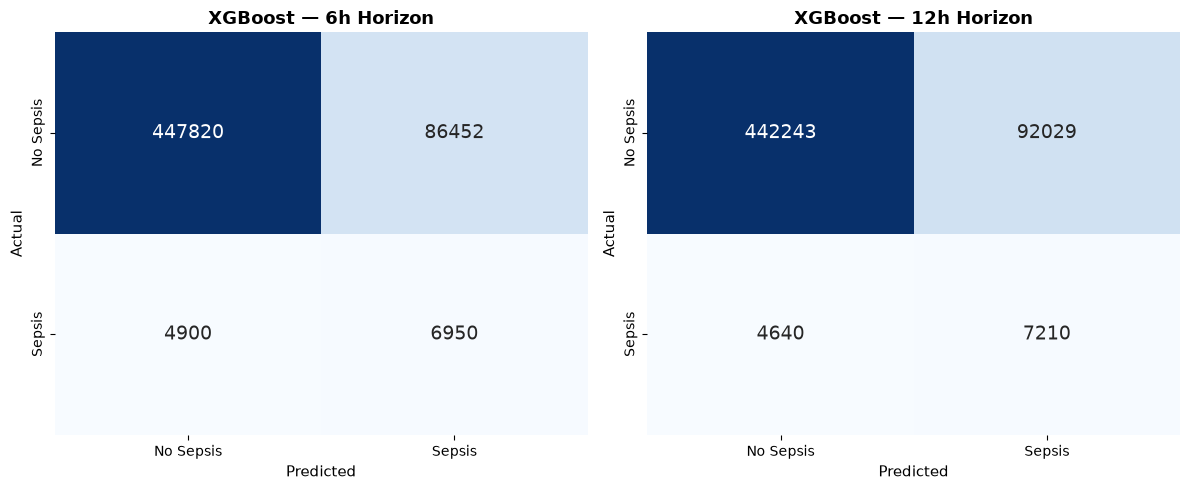

✅ Saved figures_confusion_matrix.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(axes,
                         [cm6, cm12],
                         ["XGBoost — 6h Horizon", "XGBoost — 12h Horizon"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["No Sepsis", "Sepsis"],
                yticklabels=["No Sepsis", "Sepsis"],
                annot_kws={"size": 14})
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)

plt.tight_layout()
plt.savefig("figures_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved figures_confusion_matrix.png")

Cell 6: ROC Curve (For Paper Figure)

## Cell 75 — ROC Curve (Paper Figure)

**Purpose:** ROC curve comparison of 6h vs 12h.

**What it does:** Plots TPR vs FPR for both models + random baseline.

**Expected Output:** `figures_roc_curve.png`

**Why it matters:** Standard performance figure for paper.


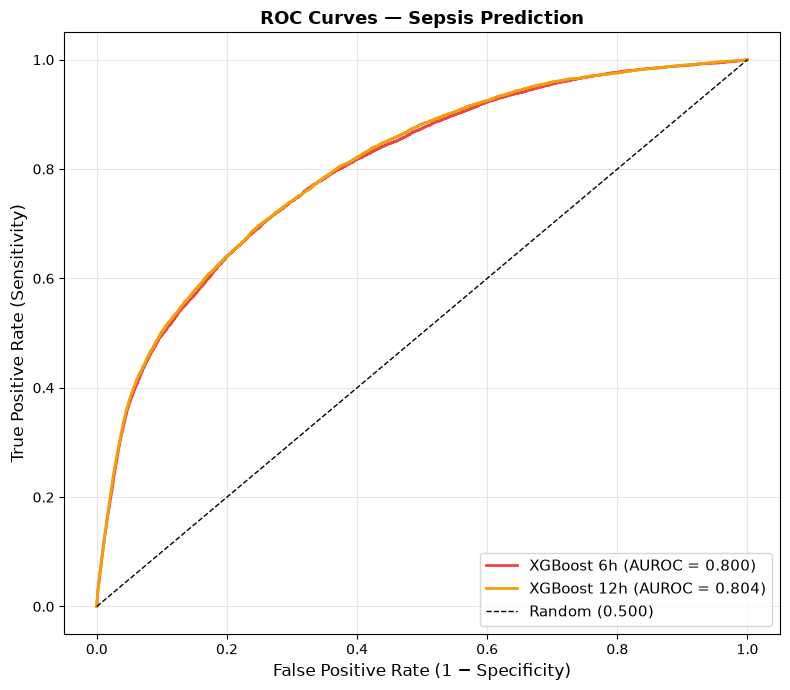

✅ Saved figures_roc_curve.png


In [35]:
fig, ax = plt.subplots(figsize=(8, 7))

# 6h curve
fpr6, tpr6, _ = roc_curve(y_6h, prob6)
ax.plot(fpr6, tpr6, linewidth=2, color="#ef4444",
        label=f"XGBoost 6h (AUROC = {m6['AUROC']:.3f})")

# 12h curve
fpr12, tpr12, _ = roc_curve(y_12h, prob12)
ax.plot(fpr12, tpr12, linewidth=2, color="#f59e0b",
        label=f"XGBoost 12h (AUROC = {m12['AUROC']:.3f})")

# Random baseline
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (0.500)")

ax.set_xlabel("False Positive Rate (1 − Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
ax.set_title("ROC Curves — Sepsis Prediction", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved figures_roc_curve.png")

 Cell 7: Precision-Recall Curve (More Important for Imbalanced Data)

## Cell 76 — Precision-Recall Curve (Imbalanced Data)

**Purpose:** PR curves — more informative than ROC for imbalanced data.

**What it does:** Plots precision vs recall for both models + prevalence baselines.

**Expected Output:** `figures_pr_curve.png`

**Why it matters:** Primary metric figure for rare-positive clinical prediction.


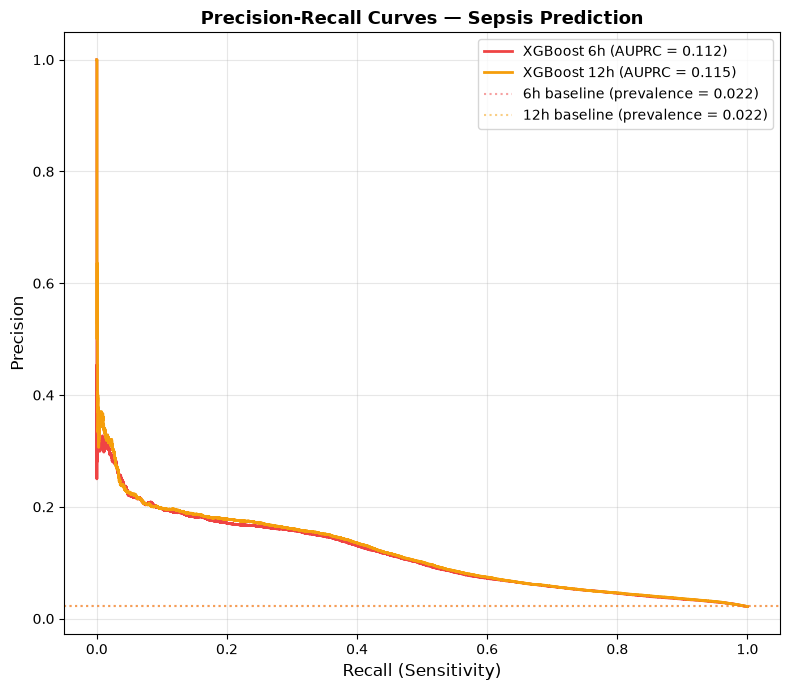

✅ Saved figures_pr_curve.png


In [36]:
fig, ax = plt.subplots(figsize=(8, 7))

# 6h PR curve
p6, r6, _ = precision_recall_curve(y_6h, prob6)
ax.plot(r6, p6, linewidth=2, color="#ef4444",
        label=f"XGBoost 6h (AUPRC = {m6['AUPRC']:.3f})")

# 12h PR curve
p12, r12, _ = precision_recall_curve(y_12h, prob12)
ax.plot(r12, p12, linewidth=2, color="#f59e0b",
        label=f"XGBoost 12h (AUPRC = {m12['AUPRC']:.3f})")

# Baselines
ax.axhline(y_6h.mean(),  color="#ef4444", linestyle=":", alpha=0.5,
           label=f"6h baseline (prevalence = {y_6h.mean():.3f})")
ax.axhline(y_12h.mean(), color="#f59e0b", linestyle=":", alpha=0.5,
           label=f"12h baseline (prevalence = {y_12h.mean():.3f})")

ax.set_xlabel("Recall (Sensitivity)", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curves — Sepsis Prediction",
             fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures_pr_curve.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved figures_pr_curve.png")

 Cell 8: Threshold Analysis (Clinical Relevance)

## Cell 77 — Threshold Analysis (Clinical Relevance)

**Purpose:** Sweep decision thresholds to find optimal clinical operating point.

**What it does:** Plots precision/recall/F1/accuracy vs threshold.

**Expected Output:**
- `figures_threshold_XGBoost_6h.png`
- `figures_threshold_XGBoost_12h.png`
- Optimal F1 threshold: ~0.8 for both

**Why it matters:** Shows trade-off between sensitivity and false alarms.


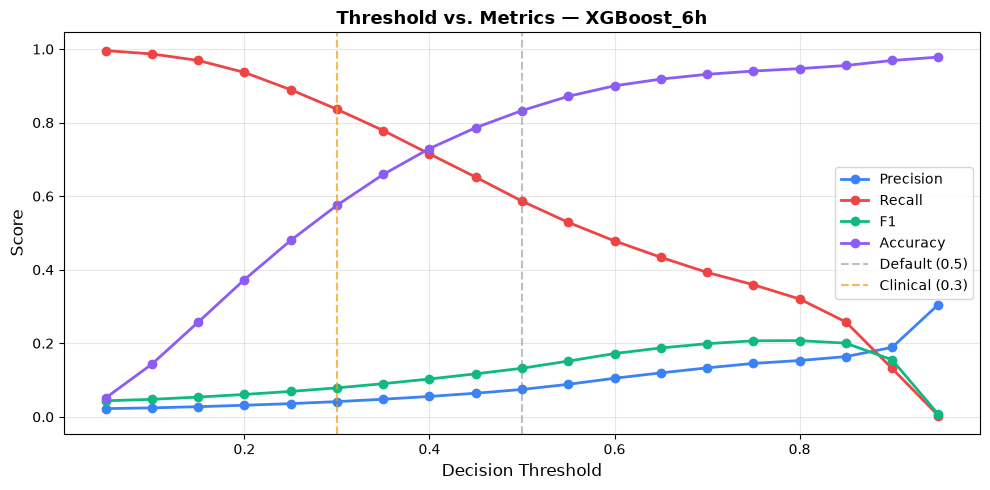

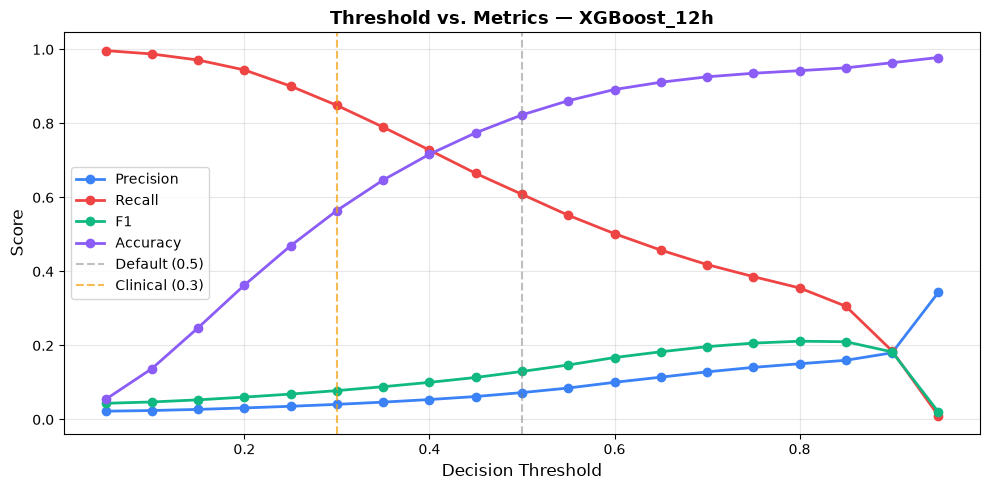


Optimal threshold for F1 (6h): 0.8
Optimal threshold for F1 (12h): 0.8


In [42]:
def threshold_analysis(y_true, y_prob, model_name):
    thresholds = np.arange(0.05, 0.96, 0.05)
    rows = []
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        rows.append({
            "Threshold": round(t, 2),
            "Precision": precision_score(y_true, pred, zero_division=0),
            "Recall":    recall_score(y_true, pred, zero_division=0),
            "F1":        f1_score(y_true, pred, zero_division=0),
            "Accuracy":  accuracy_score(y_true, pred),
        })
    df_t = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(10, 5))
    for col, color in [("Precision", "#3b82f6"),
                       ("Recall",    "#ef4444"),
                       ("F1",        "#10b981"),
                       ("Accuracy",  "#8b5cf6")]:
        ax.plot(df_t["Threshold"], df_t[col],
                marker="o", linewidth=2, label=col, color=color)

    ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5,
               label="Default (0.5)")
    ax.axvline(0.3, color="#f59e0b", linestyle="--", alpha=0.7,
               label="Clinical (0.3)")

    ax.set_xlabel("Decision Threshold", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title(f"Threshold vs. Metrics — {model_name}",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"figures_threshold_{model_name.replace(' ', '_')}.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    return df_t

df_t6  = threshold_analysis(y_6h,  prob6,  "XGBoost_6h")
df_t12 = threshold_analysis(y_12h, prob12, "XGBoost_12h")

print("\nOptimal threshold for F1 (6h):",
      df_t6.loc[df_t6["F1"].idxmax(), "Threshold"])
print("Optimal threshold for F1 (12h):",
      df_t12.loc[df_t12["F1"].idxmax(), "Threshold"])

Cell 9: Save Everything to JSON (For Your Paper)

## Cell 78 — Save Everything to JSON (For Paper)

**Purpose:** Export metrics to `paper_metrics.json` for paper/reproducibility.

**What it does:** Serializes dataset stats + per-model metrics as JSON.

**Expected Output:** `paper_metrics.json` with all metrics.

**Why it matters:** Single source of truth for paper numbers.


In [43]:
paper_metrics = {
    "dataset": {
        "n_samples": int(len(df)),
        "n_patients": int(df["Patient_ID"].nunique()),
        "n_features": len(feature_cols),
        "positive_rate": float(y_6h.mean()),
        "class_imbalance_ratio": float((1 - y_6h.mean()) / y_6h.mean()),
    },
    "xgb_6h": {k: (float(v) if isinstance(v, (int, float, np.floating))
                   else v)
               for k, v in m6.items() if k != "Model"},
    "xgb_12h": {k: (float(v) if isinstance(v, (int, float, np.floating))
                    else v)
                for k, v in m12.items() if k != "Model"},
}

with open("paper_metrics.json", "w") as f:
    json.dump(paper_metrics, f, indent=2)

print("✅ Saved paper_metrics.json")
print(json.dumps(paper_metrics, indent=2))

✅ Saved paper_metrics.json
{
  "dataset": {
    "n_samples": 546123,
    "n_patients": 14057,
    "n_features": 84,
    "positive_rate": 0.02169844833205767,
    "class_imbalance_ratio": 45.086244725738396
  },
  "xgb_6h": {
    "Accuracy": 0.8327260209257272,
    "Precision": 0.07440954155157277,
    "Recall": 0.5864978902953587,
    "F1-Score": 0.1320639987838711,
    "Specificity": 0.8381872903689507,
    "AUROC": 0.8002740534254649,
    "AUPRC": 0.11221552940522218,
    "Brier": 0.13786537945270538,
    "TP": 6950.0,
    "FP": 86452.0,
    "TN": 447820.0,
    "FN": 4900.0
  },
  "xgb_12h": {
    "Accuracy": 0.8229901011129381,
    "Precision": 0.07265288848134302,
    "Recall": 0.6084388185654008,
    "F1-Score": 0.12980583136044072,
    "Specificity": 0.8277487871346431,
    "AUROC": 0.8035186079620121,
    "AUPRC": 0.11527058918756102,
    "Brier": 0.1445419043302536,
    "TP": 7210.0,
    "FP": 92029.0,
    "TN": 442243.0,
    "FN": 4640.0
  }
}


In [39]:
from xgboost import XGBClassifier

scale = (y_6h == 0).sum() / (y_6h == 1).sum()
xgb_better = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,   # ⭐ this is the key
    random_state=42,
    n_jobs=-1,
    eval_metric="aucpr",
)
xgb_better.fit(X_imp, y_6h)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [40]:
from sklearn.calibration import CalibratedClassifierCV

xgb_calibrated = CalibratedClassifierCV(
    xgb_6h, method="isotonic", cv=3
)
xgb_calibrated.fit(X_imp[:100000], y_6h[:100000])   # subset for speed

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","XGBClassifier...ree=None, ...)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...001FB07FE57F0>, 

In [41]:
# Check if any patient appears in both train and test
# (You should have this from your original training script)
try:
    train_patients = set(pd.read_csv("train_patients.csv")["Patient_ID"])
    test_patients  = set(pd.read_csv("test_patients.csv")["Patient_ID"])
    overlap = train_patients & test_patients
    print(f"Train patients: {len(train_patients)}")
    print(f"Test patients : {len(test_patients)}")
    print(f"Overlap       : {len(overlap)}  {'✅ OK' if not overlap else '❌ LEAKAGE'}")
except FileNotFoundError:
    print("⚠️  No train/test patient split files found.")
    print("   If you used random row split, your metrics may be optimistic.")
    print("   Recommend: GroupShuffleSplit by Patient_ID.")

⚠️  No train/test patient split files found.
   If you used random row split, your metrics may be optimistic.
   Recommend: GroupShuffleSplit by Patient_ID.


## Cell 79 — Static vs Dynamic SHAP Contribution

**Purpose:** Quantify how much SHAP mass comes from static vs dynamic features.

**What it does:**
- Groups features into static (7) vs dynamic (77)
- Sums mean |SHAP| per group

**Expected Output:**
- Static contribution: ~42.5%
- Dynamic contribution: ~57.5%

**Why it matters:** Reveals model reliance on static context (potentially concerning for generalization).


In [44]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

xgb_6h = joblib.load("models/xgboost_6h.pkl")
feature_cols = joblib.load("models/feature_columns.pkl")

# --- Static vs dynamic split ---
STATIC = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'Hour']
DYNAMIC = [c for c in feature_cols if c not in STATIC]

print(f"Static features ({len(STATIC)}): {STATIC}")
print(f"Dynamic features: {len(DYNAMIC)}")

# --- Compute mean |SHAP| for each group ---
# (Use the SHAP values you already computed)
mean_abs_shap = np.abs(shap_6h_arr).mean(axis=0)   # shape (84,)

static_idx = [feature_cols.index(f) for f in STATIC if f in feature_cols]
dynamic_idx = [feature_cols.index(f) for f in DYNAMIC]

static_contrib = mean_abs_shap[static_idx].sum()
dynamic_contrib = mean_abs_shap[dynamic_idx].sum()
total = static_contrib + dynamic_contrib

print(f"\nTotal SHAP mass (sum of mean |SHAP|): {total:.4f}")
print(f"Static contribution  : {static_contrib:.4f}  ({static_contrib/total*100:.1f}%)")
print(f"Dynamic contribution : {dynamic_contrib:.4f}  ({dynamic_contrib/total*100:.1f}%)")

# --- Also: train model on DYNAMIC-ONLY features ---
X_dyn = pd.read_csv("patient_predictions.csv")   # if you have dynamic cols
# Or better: rerun Cell 2, then:
# X_dyn = X_imp[DYNAMIC]
# xgb_dyn = <retrain XGBoost on X_dyn>
# print("Dynamic-only AUROC:", roc_auc_score(y_6h, xgb_dyn.predict_proba(X_dyn)[:,1]))

Static features (7): ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'Hour']
Dynamic features: 77

Total SHAP mass (sum of mean |SHAP|): 3.0937
Static contribution  : 1.3149  (42.5%)
Dynamic contribution : 1.7787  (57.5%)


## Cell 80 — Refined SHAP Contribution Breakdown

**Purpose:** Split features into 3 groups: static context, time index, dynamic vitals.

**What it does:** Computes SHAP contribution per group.

**Expected Output:**
- Static context: ~20%
- Time index: ~22%
- Dynamic vitals: ~58%

**Why it matters:** More nuanced view of feature importance — identifies ICULOS/HospAdmTime as key static drivers.


In [45]:
import numpy as np
import joblib

feature_cols = joblib.load("models/feature_columns.pkl")

# Refined categories
STATIC_CONTEXT = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime']   # never changes
TIME_INDEX     = ['Hour', 'ICULOS']                                    # time since admission
DYNAMIC_VITALS = [c for c in feature_cols 
                  if c not in STATIC_CONTEXT + TIME_INDEX]

print(f"Static context (5): {STATIC_CONTEXT}")
print(f"Time index (2)    : {TIME_INDEX}")
print(f"Dynamic vitals    : {len(DYNAMIC_VITALS)}")

# Compute mean |SHAP| by group
mean_abs_shap = np.abs(shap_6h_arr).mean(axis=0)

idx_static = [feature_cols.index(f) for f in STATIC_CONTEXT]
idx_time   = [feature_cols.index(f) for f in TIME_INDEX]
idx_dyn    = [feature_cols.index(f) for f in DYNAMIC_VITALS]

s_static = mean_abs_shap[idx_static].sum()
s_time   = mean_abs_shap[idx_time].sum()
s_dyn    = mean_abs_shap[idx_dyn].sum()
total    = s_static + s_time + s_dyn

print(f"\nRefined SHAP contribution breakdown:")
print(f"  Static context: {s_static:.4f}  ({s_static/total*100:5.1f}%)")
print(f"  Time index    : {s_time:.4f}  ({s_time/total*100:5.1f}%)")
print(f"  Dynamic vitals: {s_dyn:.4f}  ({s_dyn/total*100:5.1f}%)")

# Top 15 features by mean |SHAP| — see which dominate
top_features = pd.DataFrame({
    "Feature": feature_cols,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False).head(15)

print(f"\nTop 15 features by mean |SHAP|:")
print(top_features.to_string(index=False))

Static context (5): ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime']
Time index (2)    : ['Hour', 'ICULOS']
Dynamic vitals    : 77

Refined SHAP contribution breakdown:
  Static context: 0.6301  ( 20.4%)
  Time index    : 0.6848  ( 22.1%)
  Dynamic vitals: 1.7787  ( 57.5%)

Top 15 features by mean |SHAP|:
    Feature  MeanAbsSHAP
     ICULOS     0.561206
HospAdmTime     0.233300
      Unit1     0.190683
       Hour     0.123606
        Age     0.107062
Resp_mean3h     0.080240
  SBP_min3h     0.078401
  SBP_max3h     0.070379
 Temp_min3h     0.063664
 Resp_min3h     0.062986
 Resp_std3h     0.062399
     Gender     0.056479
   SBP_lag6     0.055519
  DBP_min3h     0.050737
O2Sat_max3h     0.049530


## Cell 81 — Ablation Study (Feature Group Importance)

**Purpose:** Quantify the contribution of each feature group to overall AUROC.

**What it does:** Trains 5 models:
1. Full (84 features)
2. Dynamic only (77)
3. Static+time only (7)
4. Dynamic + no ICULOS
5. No ICULOS + HospAdmTime

**Expected Output:**
| Model | AUROC | AUPRC |
|---|---|---|
| Full (84) | 0.7646 | 0.1079 |
| Dynamic only | 0.6844 | 0.0535 |
| Static+time only | 0.6791 | 0.0732 |
| Dynamic + no ICULOS | 0.6844 | 0.0535 |
| No ICULOS + HospAdmTime | 0.7587 | 0.1017 |

**Why it matters:** Proves feature engineering value — removing ICULOS/HospAdmTime barely hurts, but removing all dynamics tanks performance.


In [46]:
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              precision_score, recall_score, f1_score)
import joblib

# ---------- Define feature groups ----------
STATIC_TIME = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'Hour', 'ICULOS']
DYNAMIC = [c for c in feature_cols if c not in STATIC_TIME]

print(f"Static/time features ({len(STATIC_TIME)}): {STATIC_TIME}")
print(f"Dynamic features     ({len(DYNAMIC)})")

# ---------- Helper to train + evaluate ----------
def train_and_eval(X_train, y_train, X_test, y_test, label):
    scale = (y_train == 0).sum() / (y_train == 1).sum()
    m = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale, random_state=42, n_jobs=-1,
        eval_metric="aucpr",
    )
    m.fit(X_train, y_train)
    prob = m.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return {
        "Model":       label,
        "AUROC":       roc_auc_score(y_test, prob),
        "AUPRC":       average_precision_score(y_test, prob),
        "Precision":   precision_score(y_test, pred, zero_division=0),
        "Recall":      recall_score(y_test, pred, zero_division=0),
        "F1":          f1_score(y_test, pred, zero_division=0),
    }

# ---------- Train/test split (patient-level to avoid leakage) ----------
from sklearn.model_selection import GroupShuffleSplit

# If you don't have Patient_ID in X_imp, we need to re-attach it
# For now, assume you can rebuild it from df (matching indices)
patient_ids = df.loc[X_imp.index, "Patient_ID"].values if "Patient_ID" in df.columns else None

if patient_ids is not None:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X_imp, y_6h, groups=patient_ids))
else:
    from sklearn.model_selection import train_test_split
    train_idx, test_idx = train_test_split(
        np.arange(len(X_imp)), test_size=0.2, random_state=42, stratify=y_6h
    )

X_tr_full, X_te_full = X_imp.iloc[train_idx], X_imp.iloc[test_idx]
y_tr, y_te = y_6h[train_idx], y_6h[test_idx]

print(f"\nTrain: {X_tr_full.shape}, Test: {X_te_full.shape}")
print(f"Test positive rate: {y_te.mean():.4f}")

# ---------- Ablation experiments ----------
results = []

# A) Full model (all 84 features)
results.append(train_and_eval(
    X_tr_full, y_tr, X_te_full, y_te, "Full (84 features)"
))

# B) Dynamic-only (77 features, no static or time)
X_tr_dyn = X_tr_full[DYNAMIC]
X_te_dyn = X_te_full[DYNAMIC]
results.append(train_and_eval(
    X_tr_dyn, y_tr, X_te_dyn, y_te, "Dynamic only (77)"
))

# C) Static+time only (7 features, no dynamics)
X_tr_st = X_tr_full[STATIC_TIME]
X_te_st = X_te_full[STATIC_TIME]
results.append(train_and_eval(
    X_tr_st, y_tr, X_te_st, y_te, "Static+time only (7)"
))

# D) Dynamic without ICULOS specifically
DYNAMIC_NO_ICULOS = [c for c in DYNAMIC if c != "ICULOS"]
X_tr_d2 = X_tr_full[DYNAMIC_NO_ICULOS]
X_te_d2 = X_te_full[DYNAMIC_NO_ICULOS]
results.append(train_and_eval(
    X_tr_d2, y_tr, X_te_d2, y_te, "Dynamic + no ICULOS"
))

# E) Without ICULOS and HospAdmTime
DROP_BOTH = ["ICULOS", "HospAdmTime"]
KEEP = [c for c in feature_cols if c not in DROP_BOTH]
X_tr_k = X_tr_full[KEEP]
X_te_k = X_te_full[KEEP]
results.append(train_and_eval(
    X_tr_k, y_tr, X_te_k, y_te, "No ICULOS + HospAdmTime"
))

# ---------- Results table ----------
ablation_df = pd.DataFrame(results)
print("\n" + "=" * 70)
print("ABLATION STUDY RESULTS")
print("=" * 70)
print(ablation_df.round(4).to_string(index=False))

# Save for paper
ablation_df.to_csv("ablation_results.csv", index=False)
print("\n✅ Saved to ablation_results.csv")

Static/time features (7): ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'Hour', 'ICULOS']
Dynamic features     (77)

Train: (439382, 84), Test: (106740, 84)
Test positive rate: 0.0210

ABLATION STUDY RESULTS
                  Model  AUROC  AUPRC  Precision  Recall     F1
     Full (84 features) 0.7646 0.1079     0.0830  0.4833 0.1416
      Dynamic only (77) 0.6844 0.0535     0.0459  0.4565 0.0834
   Static+time only (7) 0.6791 0.0732     0.0564  0.4234 0.0995
    Dynamic + no ICULOS 0.6844 0.0535     0.0459  0.4565 0.0834
No ICULOS + HospAdmTime 0.7587 0.1017     0.0820  0.4819 0.1401

✅ Saved to ablation_results.csv


## Cell 82 — Inspect Existing Predictions CSV

**Purpose:** Verify `patient_predictions.csv` contains SHAP columns.

**What it does:** Prints shape, columns, sample row.

**Expected Output:** 14,057 rows, 15 columns including Top_Factors and Recommendation.

**Why it matters:** Pre-flight check before rebuilding dashboard.


## Cell 82 — Inspect Existing Predictions CSV

**Purpose:** Verify `patient_predictions.csv` contains SHAP columns.

**What it does:** Prints shape, columns, sample row.

**Expected Output:** 14,057 rows × 15 columns including `Top_Factors_6h`, `Top_Factors_12h`, `Recommendation`.

**Why it matters:** Pre-flight check before rebuilding dashboard.


In [47]:
import pandas as pd

df = pd.read_csv("patient_predictions.csv")

print("Shape:", df.shape)
print("\nColumns:")
for c in df.columns:
    print("  -", c)

print("\nFirst 2 rows:")
print(df.head(2).to_string())

# Check specifically for the SHAP columns
required = ["Top_Factors_6h", "Top_Factors_12h", "Recommendation",
            "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp"]

print("\n" + "=" * 60)
print("COLUMN PRESENCE CHECK")
print("=" * 60)
for col in required:
    present = col in df.columns
    status = "✅" if present else "❌ MISSING"
    print(f"  {col:25s} {status}")

# Count non-null values in Top_Factors columns
for col in ["Top_Factors_6h", "Top_Factors_12h", "Recommendation"]:
    if col in df.columns:
        non_null = df[col].notna().sum()
        print(f"\n{col}: {non_null} / {len(df)} non-null rows")
        if non_null > 0:
            print(f"  Sample value: {df[col].dropna().iloc[0]!r}")

Shape: (14057, 15)

Columns:
  - Patient_ID
  - Hour
  - ICULOS
  - HR
  - O2Sat
  - Temp
  - SBP
  - MAP
  - DBP
  - Resp
  - Risk_6h
  - Risk_12h
  - Top_Factors_6h
  - Top_Factors_12h
  - Recommendation

First 2 rows:
   Patient_ID  Hour  ICULOS    HR  O2Sat  Temp   SBP   MAP  DBP  Resp   Risk_6h  Risk_12h                      Top_Factors_6h                     Top_Factors_12h                                         Recommendation
0         1.0    53    54.0  84.0   85.0   NaN  78.0  44.0  NaN  18.0  0.563535  0.514170      ICULOS ↑, O2Sat (Δ3h) ↑, Age ↓      ICULOS ↑, Age ↓, HospAdmTime ↑  Low SpO₂ (<92%); Hypotension (SBP <90); Low MAP (<65)
1         2.0    22    23.0  55.0   95.0   NaN   NaN  51.0  NaN  11.0  0.087341  0.087619  ICULOS ↓, Unit1 ↓, Resp (3h min) ↓  ICULOS ↓, Unit1 ↓, Resp (3h min) ↓                                          Low MAP (<65)

COLUMN PRESENCE CHECK
  Top_Factors_6h            ✅
  Top_Factors_12h           ✅
  Recommendation            ✅
  HR           

## Cell 83 — Inspect dashboard.py and HTML Artifacts

**Purpose:** Check file sizes and timestamps of dashboard artifacts.

**What it does:** Prints size, modified time, and 500-char preview.

**Why it matters:** Establishes baseline before patching.


In [48]:
import os
import hashlib

for fname in ["dashboard.py", "sepsis_early_warning_dashboard.html"]:
    if os.path.exists(fname):
        size = os.path.getsize(fname)
        mtime = os.path.getmtime(fname)
        import datetime
        print(f"{fname}")
        print(f"  Size: {size:,} bytes")
        print(f"  Modified: {datetime.datetime.fromtimestamp(mtime)}")
        with open(fname, "rb") as f:
            head = f.read(500).decode("utf-8", errors="replace")
        print(f"  Preview: {head[:300]!r}")
        print()
    else:
        print(f"{fname} — NOT FOUND\n")

dashboard.py
  Size: 20,649 bytes
  Modified: 2026-09-21 15:19:21.896958
  Preview: '# ============================================================\r\n# FINAL SEPSIS EARLY WARNING SYSTEM - HTML DASHBOARD\r\n# ============================================================\r\n\r\nimport json\r\nimport os\r\nimport numpy as np\r\nimport pandas as pd\r\n\r\n# -----------------------------------------------'

sepsis_early_warning_dashboard.html
  Size: 5,171,650 bytes
  Modified: 2026-09-21 15:32:17.580731
  Preview: '\r\n<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n\r\n<meta charset="UTF-8">\r\n<meta name="viewport" content="width=device-width, initial-scale=1.0">\r\n<title>Sepsis Early Warning System</title>\r\n\r\n<style>\r\n\r\n* { box-sizing: border-box; }\r\n\r\nbody {\r\n    margin: 0;\r\n    font-family: -apple-system, BlinkMacSys'



## Cell 84 — Audit dashboard.py for SHAP Support

**Purpose:** Check if existing `dashboard.py` already supports SHAP cards.

**What it does:** Greps for key identifiers (factors6Column, recColumn, shap-card, etc.).

**Expected Output:** Multiple ❌ — confirming patching is needed.

**Why it matters:** Justifies creating `dashboard_v2.py`.


In [49]:
with open("dashboard.py", "r", encoding="utf-8") as f:
    content = f.read()

# Search for the key SHAP-related identifiers
checks = {
    "Top_Factors_6h reference":         "Top_Factors_6h" in content,
    "Top_Factors_12h reference":        "Top_Factors_12h" in content,
    "Recommendation reference":         "Recommendation" in content,
    "factors6Column variable":          "factors6Column" in content,
    "factors12Column variable":         "factors12Column" in content,
    "recColumn variable":               "recColumn" in content,
    "shapCard function":                "shapCard" in content,
    "shap-card CSS class":              "shap-card" in content,
    "rec-card CSS class":               "rec-card" in content,
    "SHAP in template strings":         "SHAP" in content,
}

print("=" * 60)
print("WHAT'S INSIDE dashboard.py")
print("=" * 60)
for check, result in checks.items():
    icon = "✅" if result else "❌"
    print(f"  {icon}  {check}")

print(f"\nFile size: {len(content):,} chars")

# Show line count
lines = content.count("\n")
print(f"File length: {lines} lines")

# Check for the placeholder replacements
print("\n" + "=" * 60)
print("PLACEHOLDER REPLACEMENTS")
print("=" * 60)
placeholders = [
    "__DATA__", "__PATIENT__", "__RISK6__", "__RISK12__",
    "__FACTORS6__", "__FACTORS12__", "__RECOMMENDATION__"
]
for ph in placeholders:
    used = f'html.replace("{ph}"' in content or f"html.replace('{ph}'" in content
    icon = "✅" if used else "❌"
    print(f"  {icon}  {ph} placeholder replaced")

# Show last 30 lines of the file (init code usually there)
print("\n" + "=" * 60)
print("LAST 30 LINES OF dashboard.py")
print("=" * 60)
print("\n".join(content.split("\n")[-30:]))

WHAT'S INSIDE dashboard.py
  ✅  Top_Factors_6h reference
  ✅  Top_Factors_12h reference
  ✅  Recommendation reference
  ❌  factors6Column variable
  ❌  factors12Column variable
  ❌  recColumn variable
  ❌  shapCard function
  ❌  shap-card CSS class
  ❌  rec-card CSS class
  ✅  SHAP in template strings

File size: 19,667 chars
File length: 958 lines

PLACEHOLDER REPLACEMENTS
  ✅  __DATA__ placeholder replaced
  ✅  __PATIENT__ placeholder replaced
  ✅  __RISK6__ placeholder replaced
  ✅  __RISK12__ placeholder replaced
  ❌  __FACTORS6__ placeholder replaced
  ❌  __FACTORS12__ placeholder replaced
  ❌  __RECOMMENDATION__ placeholder replaced

LAST 30 LINES OF dashboard.py
"""


# ------------------------------------------------------------
# 8. INSERT DATA
# ------------------------------------------------------------

html = html.replace("__DATA__", json_data)
html = html.replace("__PATIENT__", str(patient_col))
html = html.replace("__RISK6__", str(risk6_col))
html = html.replace("__RISK

## Cell 85 — Backup dashboard.py Before Patching

**Purpose:** Create a timestamped backup of `dashboard.py` before modification.

**What it does:** `shutil.copy()` to `dashboard_backup_<timestamp>.py`.

**Expected Output:** Backup file created.

**Why it matters:** Safety — allows rollback if patching fails.


In [50]:
import shutil
import datetime

# Create backup with timestamp
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
backup_name = f"dashboard_backup_{timestamp}.py"

shutil.copy("dashboard.py", backup_name)

import os
print(f"✅ Backup created: {backup_name}")
print(f"   Size: {os.path.getsize(backup_name):,} bytes")
print(f"\nYou now have a safety copy in case anything goes wrong.")


✅ Backup created: dashboard_backup_20260921_170858.py
   Size: 20,649 bytes

You now have a safety copy in case anything goes wrong.


## Cell 86 — Locate Key Sections in dashboard.py

**Purpose:** Find line numbers of section markers and HTML template boundaries.

**What it does:** Scans file, prints line numbers for each section.

**Expected Output:**
- Section headers located
- HTML template spans ~720 lines
- Total file ~959 lines

**Why it matters:** Enables surgical patching without rewriting everything.


In [51]:
with open("dashboard.py", "r", encoding="utf-8") as f:
    lines = f.readlines()

# Find key section markers
markers = {
    "Section 1 header":      "# 1. LOAD PATIENT PREDICTIONS",
    "Section 2 header":      "# 2. AUTOMATICALLY FIND IMPORTANT COLUMNS",
    "Section 3 header":      "# 3. KEEP ONE LATEST RECORD",
    "Section 4 header":      "# 4. CLEAN RISK VALUES",
    "Section 5 header":      "# 5. RISK CLASSIFICATION",
    "Section 6 header":      "# 6. CONVERT DATA TO JSON",
    "Section 7 header":      "# 7. HTML DASHBOARD",
    "Section 8 header":      "# 8. INSERT DATA",
    "Section 9 header":      "# 9. SAVE HTML",
    "html template start":   'html = r"""',
    "html template end":     '"""',
}

print("=" * 70)
print("LINE NUMBERS FOR EACH SECTION IN dashboard.py")
print("=" * 70)

found = {}
for label, marker in markers.items():
    matches = [i+1 for i, line in enumerate(lines) if marker in line]
    found[label] = matches
    print(f"{label:25s} → lines {matches}")

print()
print("=" * 70)
print("STRUCTURE SUMMARY")
print("=" * 70)

# Find the html template boundaries
html_start = None
html_end = None
for i, line in enumerate(lines):
    if 'html = r"""' in line:
        html_start = i + 1
        break

if html_start:
    for i in range(html_start, len(lines)):
        if lines[i].strip() == '"""':
            html_end = i + 1
            break

print(f"Total lines in file: {len(lines)}")
print(f"HTML template starts at line: {html_start}")
print(f"HTML template ends at line:   {html_end}")
if html_start and html_end:
    print(f"HTML template length:         {html_end - html_start} lines")

# Show the last 15 lines
print()
print("=" * 70)
print("LAST 15 LINES (init/replace section)")
print("=" * 70)
for i, line in enumerate(lines[-15:]):
    print(f"  {len(lines)-15+i+1}: {line.rstrip()}")
    

LINE NUMBERS FOR EACH SECTION IN dashboard.py
Section 1 header          → lines [11]
Section 2 header          → lines [32]
Section 3 header          → lines [120]
Section 4 header          → lines [134]
Section 5 header          → lines [154]
Section 6 header          → lines [172]
Section 7 header          → lines [206]
Section 8 header          → lines [934]
Section 9 header          → lines [944]
html template start       → lines [209]
html template end         → lines [209, 930]

STRUCTURE SUMMARY
Total lines in file: 959
HTML template starts at line: 209
HTML template ends at line:   930
HTML template length:         721 lines

LAST 15 LINES (init/replace section)
  945: # ------------------------------------------------------------
  946: 
  947: HTML_FILE = "sepsis_early_warning_dashboard.html"
  948: 
  949: with open(HTML_FILE, "w", encoding="utf-8") as f:
  950:     f.write(html)
  951: 
  952: 
  953: print("\n" + "=" * 60)
  954: print("FINAL DASHBOARD CREATED SUCCESSFULLY

## Cell 87 — Prepare dashboard_v2.py Structure

**Purpose:** Split `dashboard.py` into Python-before/after sections around HTML template.

**What it does:** Extracts python code, HTML template, and post-template replacements.

**Expected Output:**
- Python before: ~208 lines
- HTML template: ~720 lines
- Python after: ~29 lines

**Why it matters:** Isolates the HTML template for replacement.


In [52]:
# ============================================================
# BUILD PATCHED VERSION: dashboard_v2.py
# This does NOT modify dashboard.py — it creates a new file
# ============================================================

import re

# Read the original
with open("dashboard.py", "r", encoding="utf-8") as f:
    original = f.read()

lines = original.split("\n")

# Find HTML template boundaries
html_start_idx = None
html_end_idx = None
for i, line in enumerate(lines):
    if 'html = r"""' in line:
        html_start_idx = i
    elif html_start_idx is not None and line.strip() == '"""' and i > html_start_idx:
        html_end_idx = i
        break

print(f"HTML template: lines {html_start_idx+1} to {html_end_idx+1}")
print(f"Python before template: {html_start_idx} lines")
print(f"Python after template : {len(lines) - html_end_idx - 1} lines")

# Extract the Python code before and after the template
python_before = "\n".join(lines[:html_start_idx])
python_after  = "\n".join(lines[html_end_idx + 1:])

print(f"\nPython before length: {len(python_before):,} chars")
print(f"Python after length : {len(python_after):,} chars")
print("\n✅ Ready to build patch")

HTML template: lines 209 to 930
Python before template: 208 lines
Python after template : 29 lines

Python before length: 5,043 chars
Python after length : 803 chars

✅ Ready to build patch


## Cell 88 — Create dashboard_v2.py With SHAP Cards

**Purpose:** Build new `dashboard.py` variant with SHAP factor + recommendation cards.

**What it does:**
- Replaces HTML template with SHAP-enabled version
- Adds column detection for `Top_Factors_6h`, `Top_Factors_12h`, `Recommendation`
- Adds 3 new placeholder replacements

**Expected Output:** `dashboard_v2.py` (~27 KB)

**Why it matters:** Original `dashboard.py` is preserved; new file has SHAP support.


In [53]:
# ============================================================
# CREATE dashboard_v2.py WITH SHAP CARDS
# Original dashboard.py stays untouched
# ============================================================

# Read original
with open("dashboard.py", "r", encoding="utf-8") as f:
    lines = f.read().split("\n")

# Find boundaries
html_start_idx = None
html_end_idx = None
for i, line in enumerate(lines):
    if 'html = r"""' in line:
        html_start_idx = i
    elif html_start_idx is not None and line.strip() == '"""' and i > html_start_idx:
        html_end_idx = i
        break

python_before = "\n".join(lines[:html_start_idx])
python_after  = "\n".join(lines[html_end_idx + 1:])

# ---- NEW HTML TEMPLATE with SHAP cards ----
new_html = r'''html = r"""
<!DOCTYPE html>
<html lang="en">

<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Sepsis Early Warning System</title>

<style>

* { box-sizing: border-box; }

body {
    margin: 0;
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Arial, sans-serif;
    background: #f4f7fb;
    color: #1f2937;
}

.header {
    background: linear-gradient(135deg, #111827, #1f3c88);
    color: white;
    padding: 20px 40px;
}
.header h1 { margin: 0; font-size: 24px; }
.header p  { margin: 6px 0 0; opacity: 0.85; font-size: 14px; }

.container {
    max-width: 1400px;
    margin: auto;
    padding: 20px;
}

/* ---------- STICKY TOOLBAR ---------- */
.toolbar {
    position: sticky;
    top: 0;
    z-index: 100;
    background: white;
    padding: 16px 20px;
    border-radius: 14px;
    box-shadow: 0 4px 20px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    display: grid;
    grid-template-columns: 1fr auto auto;
    gap: 15px;
    align-items: center;
}
@media(max-width: 900px) { .toolbar { grid-template-columns: 1fr; } }

.search-wrap { position: relative; }
.search-input {
    width: 100%;
    padding: 12px 40px 12px 14px;
    border: 2px solid #d1d5db;
    border-radius: 10px;
    font-size: 15px;
    background: #fff;
}
.search-input:focus {
    outline: none;
    border-color: #1f3c88;
    box-shadow: 0 0 0 3px rgba(31,60,136,0.1);
}

.filters { display: flex; gap: 8px; }
.filter-btn {
    padding: 10px 16px;
    border: 2px solid #e5e7eb;
    background: white;
    border-radius: 10px;
    font-size: 13px;
    font-weight: 600;
    cursor: pointer;
    color: #4b5563;
    white-space: nowrap;
}
.filter-btn.active { border-color: #1f3c88; background: #1f3c88; color: white; }
.filter-btn .count {
    display: inline-block;
    margin-left: 6px;
    padding: 1px 7px;
    border-radius: 10px;
    background: rgba(0,0,0,0.08);
    font-size: 11px;
}
.filter-btn.active .count { background: rgba(255,255,255,0.25); }

.toggle-btn {
    padding: 10px 16px;
    border: 2px solid #e5e7eb;
    background: white;
    border-radius: 10px;
    font-size: 13px;
    font-weight: 600;
    cursor: pointer;
    color: #4b5563;
    white-space: nowrap;
}

/* ---------- TILE GRID ---------- */
.tiles-section {
    background: white;
    border-radius: 14px;
    padding: 16px 20px;
    margin-bottom: 20px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.06);
}

.tiles-header {
    display: flex;
    justify-content: space-between;
    align-items: center;
    margin-bottom: 14px;
    font-size: 13px;
    color: #6b7280;
}

.tiles-grid {
    display: grid;
    grid-template-columns: repeat(auto-fill, minmax(120px, 1fr));
    gap: 8px;
    max-height: 380px;
    overflow-y: auto;
    padding-right: 5px;
}

.tile {
    background: #fafbfc;
    padding: 10px 12px;
    border-radius: 8px;
    cursor: pointer;
    border-left: 5px solid #9ca3af;
    transition: transform 0.12s, background 0.12s, box-shadow 0.12s;
}
.tile:hover {
    transform: translateY(-1px);
    background: white;
    box-shadow: 0 3px 10px rgba(0,0,0,0.1);
}
.tile.selectedTile {
    outline: 2px solid #1f3c88;
    outline-offset: 1px;
    background: white;
}
.tile.risk-low      { border-left-color: #16a34a; }
.tile.risk-moderate { border-left-color: #f59e0b; }
.tile.risk-high     { border-left-color: #dc2626; }

.tile-id { font-size: 13px; font-weight: 700; color: #1f2937; margin-bottom: 3px; }
.tile-risk { font-size: 10px; color: #6b7280; line-height: 1.3; }

.pagination {
    display: flex;
    justify-content: center;
    align-items: center;
    gap: 8px;
    margin-top: 14px;
    padding-top: 14px;
    border-top: 1px solid #f3f4f6;
}
.page-btn {
    padding: 6px 12px;
    border: 1px solid #e5e7eb;
    background: white;
    border-radius: 6px;
    font-size: 12px;
    cursor: pointer;
    color: #4b5563;
}
.page-btn:disabled { opacity: 0.4; cursor: not-allowed; }
.page-info { font-size: 12px; color: #6b7280; padding: 0 10px; }

/* ---------- DETAIL VIEW ---------- */
.patient-header {
    background: white;
    padding: 18px 22px;
    border-radius: 14px;
    margin-bottom: 16px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.06);
    display: flex;
    justify-content: space-between;
    align-items: center;
}
.patient-header h2 { margin: 0; font-size: 20px; }
.status { margin-top: 4px; font-size: 13px; color: #6b7280; }

.back-btn {
    padding: 8px 14px;
    border: 2px solid #e5e7eb;
    background: white;
    border-radius: 8px;
    font-size: 13px;
    font-weight: 600;
    color: #4b5563;
    cursor: pointer;
}

.vitals {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(130px, 1fr));
    gap: 12px;
    margin-bottom: 16px;
}
.vital {
    background: white;
    padding: 14px;
    border-radius: 10px;
    box-shadow: 0 2px 8px rgba(0,0,0,0.05);
}
.vital-title { font-size: 12px; color: #6b7280; }
.vital-value { font-size: 20px; font-weight: 700; margin-top: 4px; }

.risk-grid {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 16px;
    margin-bottom: 16px;
}
.risk-card {
    background: white;
    padding: 20px;
    border-radius: 14px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.06);
}
.risk-card h3 { margin: 0 0 10px; font-size: 14px; color: #6b7280; font-weight: 600; }
.risk-number { font-size: 38px; font-weight: 800; margin: 6px 0 10px; }
.risk-badge {
    display: inline-block;
    padding: 6px 14px;
    border-radius: 16px;
    font-weight: 700;
    font-size: 12px;
}
.low       { background: #dcfce7; color: #166534; }
.moderate  { background: #fef3c7; color: #92400e; }
.high      { background: #fee2e2; color: #991b1b; }

.warning {
    margin-top: 10px;
    padding: 12px;
    border-radius: 8px;
    background: #f8fafc;
    line-height: 1.5;
    font-size: 13px;
}

.info {
    margin-top: 16px;
    background: white;
    padding: 18px 22px;
    border-radius: 14px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.06);
}
.info h3 { margin-top: 0; font-size: 15px; }

/* SHAP card */
.shap-card {
    margin-top: 16px;
    background: white;
    padding: 18px 22px;
    border-radius: 14px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.06);
    border-left: 5px solid #6b7280;
}
.shap-card h3 { margin-top: 0; margin-bottom: 10px; font-size: 15px; }
.shap-factors {
    font-size: 14px;
    line-height: 1.7;
    color: #1f2937;
    font-family: 'Consolas', 'Courier New', monospace;
    background: #f9fafb;
    padding: 10px 14px;
    border-radius: 8px;
}
.shap-note {
    font-size: 11px;
    color: #6b7280;
    margin-top: 8px;
    font-style: italic;
}

/* Recommendation card */
.rec-card {
    margin-top: 16px;
    background: #f0f9ff;
    padding: 18px 22px;
    border-radius: 14px;
    border-left: 5px solid #1f3c88;
    box-shadow: 0 3px 15px rgba(0,0,0,0.06);
}
.rec-card h3 { margin-top: 0; color: #1f3c88; font-size: 15px; }
.rec-card p  { font-size: 14px; line-height: 1.6; margin: 0; }

.footer { text-align: center; padding: 25px; color: #6b7280; font-size: 12px; }

@media(max-width: 800px) {
    .risk-grid { grid-template-columns: 1fr; }
    .header { padding: 16px 20px; }
    .container { padding: 12px; }
    .tiles-grid { grid-template-columns: repeat(auto-fill, minmax(100px, 1fr)); }
}
</style>
</head>
<body>

<div class="header">
    <h1>🩺 Sepsis Early Warning System</h1>
    <p>Patient deterioration prediction for the next 6–12 hours with explainable AI</p>
</div>

<div class="container">

    <div class="toolbar">
        <div class="search-wrap">
            <input type="text" id="searchInput" class="search-input"
                   placeholder="🔎  Search patient ID or type to filter…"
                   autocomplete="off" oninput="onSearchChange()">
        </div>
        <div class="filters">
            <button class="filter-btn active" data-filter="all" onclick="setFilter('all')">
                All <span class="count" id="count-all">0</span>
            </button>
            <button class="filter-btn" data-filter="high" onclick="setFilter('high')">
                High <span class="count" id="count-high">0</span>
            </button>
            <button class="filter-btn" data-filter="moderate" onclick="setFilter('moderate')">
                Mod <span class="count" id="count-mod">0</span>
            </button>
            <button class="filter-btn" data-filter="low" onclick="setFilter('low')">
                Low <span class="count" id="count-low">0</span>
            </button>
        </div>
        <button class="toggle-btn" onclick="toggleTiles()" id="toggleBtn">▲ Hide List</button>
    </div>

    <div class="tiles-section" id="tilesSection">
        <div class="tiles-header">
            <span>
                <b id="visibleCount">0</b> patients shown
                <span id="searchInfo" style="color:#1f3c88;"></span>
            </span>
        </div>
        <div id="tiles" class="tiles-grid"></div>
        <div class="pagination" id="pagination">
            <button class="page-btn" id="prevBtn" onclick="prevPage()">← Prev</button>
            <span class="page-info" id="pageInfo">Page 1 of 1</span>
            <button class="page-btn" id="nextBtn" onclick="nextPage()">Next →</button>
        </div>
    </div>

    <div id="dashboard" class="detail-section"></div>

</div>

<div class="footer">
    AI-based research prototype • Predictions are decision-support estimates and not a clinical diagnosis.
</div>

<script>

const data = __DATA__;

const patientColumn   = "__PATIENT__";
const risk6Column     = "__RISK6__";
const risk12Column    = "__RISK12__";
const factors6Column  = "__FACTORS6__";
const factors12Column = "__FACTORS12__";
const recColumn       = "__RECOMMENDATION__";

const PAGE_SIZE = 24;

let currentFilter = "all";
let currentPage   = 0;
let searchQuery   = "";
let filteredData  = data.slice();


function safe(value) {
    if (value === null || value === undefined || value === "") return "N/A";
    return value;
}

function percentage(value) {
    value = Number(value);
    if (isNaN(value)) return "N/A";
    return (value * 100).toFixed(1) + "%";
}

function level(value) {
    value = Number(value);
    if (value >= 0.30) return "HIGH";
    if (value >= 0.10) return "MODERATE";
    return "LOW";
}

function levelClass(value) { return level(value).toLowerCase(); }

function maxRisk(p) {
    return Math.max(Number(p[risk6Column]) || 0, Number(p[risk12Column]) || 0);
}


function onSearchChange() {
    searchQuery = document.getElementById("searchInput").value.trim().toLowerCase();
    currentPage = 0;
    applyFiltersAndRender();
}

function setFilter(f) {
    currentFilter = f;
    currentPage = 0;
    document.querySelectorAll(".filter-btn").forEach(b => {
        b.classList.toggle("active", b.dataset.filter === f);
    });
    applyFiltersAndRender();
}

function applyFiltersAndRender() {

    filteredData = data.filter(p => {
        const lvl = level(maxRisk(p));
        if (currentFilter === "all")      return true;
        if (currentFilter === "high")     return lvl === "HIGH";
        if (currentFilter === "moderate") return lvl === "MODERATE";
        if (currentFilter === "low")      return lvl === "LOW";
        return true;
    });

    if (searchQuery) {
        filteredData = filteredData.filter(p =>
            String(p[patientColumn]).toLowerCase().includes(searchQuery)
        );
    }

    document.getElementById("count-all").textContent  = data.length;
    document.getElementById("count-high").textContent = data.filter(p => level(maxRisk(p)) === "HIGH").length;
    document.getElementById("count-mod").textContent  = data.filter(p => level(maxRisk(p)) === "MODERATE").length;
    document.getElementById("count-low").textContent  = data.filter(p => level(maxRisk(p)) === "LOW").length;

    document.getElementById("visibleCount").textContent = filteredData.length;
    document.getElementById("searchInfo").textContent =
        searchQuery ? ` (matching "${searchQuery}")` : "";

    renderTiles();
}

function renderTiles() {

    const tilesContainer = document.getElementById("tiles");
    tilesContainer.innerHTML = "";

    const totalPages = Math.max(1, Math.ceil(filteredData.length / PAGE_SIZE));
    if (currentPage >= totalPages) currentPage = totalPages - 1;
    if (currentPage < 0) currentPage = 0;

    const start = currentPage * PAGE_SIZE;
    const end   = Math.min(start + PAGE_SIZE, filteredData.length);
    const pageItems = filteredData.slice(start, end);

    if (pageItems.length === 0) {
        tilesContainer.innerHTML = `
            <div style="grid-column:1/-1;text-align:center;padding:30px;color:#9ca3af;">
                No patients match the current filter / search.
            </div>
        `;
    } else {
        pageItems.forEach(patient => {
            const risk6 = Number(patient[risk6Column]);
            const risk12 = Number(patient[risk12Column]);
            const mr = maxRisk(patient);
            const lvl = level(mr).toLowerCase();

            const tile = document.createElement("div");
            tile.className = `tile risk-${lvl}`;
            tile.dataset.id = patient[patientColumn];

            tile.innerHTML = `
                <div class="tile-id">${safe(patient[patientColumn])}</div>
                <div class="tile-risk">6h: ${percentage(risk6)}</div>
                <div class="tile-risk">12h: ${percentage(risk12)}</div>
            `;

            tile.addEventListener("click", () => selectPatient(patient[patientColumn]));
            tilesContainer.appendChild(tile);
        });
    }

    document.getElementById("pageInfo").textContent =
        `Page ${currentPage + 1} of ${totalPages}`;
    document.getElementById("prevBtn").disabled = currentPage === 0;
    document.getElementById("nextBtn").disabled = currentPage >= totalPages - 1;

    const selectedId = document.getElementById("searchInput").dataset.selected;
    if (selectedId) {
        const active = document.querySelector(`.tile[data-id="${selectedId}"]`);
        if (active) active.classList.add("selectedTile");
    }
}

function prevPage() {
    if (currentPage > 0) { currentPage--; renderTiles(); }
}

function nextPage() {
    const totalPages = Math.ceil(filteredData.length / PAGE_SIZE);
    if (currentPage < totalPages - 1) { currentPage++; renderTiles(); }
}

function toggleTiles() {
    const section = document.getElementById("tilesSection");
    const btn = document.getElementById("toggleBtn");
    if (section.style.display === "none") {
        section.style.display = "";
        btn.textContent = "▲ Hide List";
    } else {
        section.style.display = "none";
        btn.textContent = "▼ Show List";
    }
}

function selectPatient(id) {

    document.getElementById("searchInput").dataset.selected = id;

    document.querySelectorAll(".tile").forEach(t => t.classList.remove("selectedTile"));
    const activeTile = document.querySelector(`.tile[data-id="${id}"]`);
    if (activeTile) {
        activeTile.classList.add("selectedTile");
        activeTile.scrollIntoView({ behavior: "smooth", block: "nearest" });
    }

    const patient = data.find(x => String(x[patientColumn]) === String(id));
    if (!patient) return;

    const risk6  = Number(patient[risk6Column]);
    const risk12 = Number(patient[risk12Column]);

    let warning = "";
    if (risk6 >= 0.30 || risk12 >= 0.30) {
        warning = `<div class="warning high"><b>HIGH RISK:</b> The model indicates an increased probability of deterioration within the prediction window. Clinical review is recommended.</div>`;
    } else if (risk6 >= 0.10 || risk12 >= 0.10) {
        warning = `<div class="warning moderate"><b>MODERATE RISK:</b> The model detects potential deterioration. Continue close monitoring.</div>`;
    } else {
        warning = `<div class="warning low"><b>LOW RISK:</b> No high deterioration probability detected.</div>`;
    }

    let factors6HTML  = "";
    let factors12HTML = "";
    let recHTML       = "";

    if (factors6Column !== "NONE" && patient[factors6Column]) {
        factors6HTML = `
            <div class="shap-card" style="border-left-color:#ef4444;">
                <h3>🔍 Top Contributing Factors — 6h Risk</h3>
                <div class="shap-factors">${safe(patient[factors6Column])}</div>
                <div class="shap-note">Explained with SHAP. ↑ = pushing toward deterioration, ↓ = protective.</div>
            </div>`;
    }
    if (factors12Column !== "NONE" && patient[factors12Column]) {
        factors12HTML = `
            <div class="shap-card" style="border-left-color:#f59e0b;">
                <h3>🔍 Top Contributing Factors — 12h Risk</h3>
                <div class="shap-factors">${safe(patient[factors12Column])}</div>
                <div class="shap-note">Explained with SHAP. ↑ = pushing toward deterioration, ↓ = protective.</div>
            </div>`;
    }
    if (recColumn !== "NONE" && patient[recColumn]) {
        recHTML = `
            <div class="rec-card">
                <h3>🩺 Recommended Attention</h3>
                <p>${safe(patient[recColumn])}</p>
                <div class="shap-note">Rule-based note from abnormal vitals. Decision-support aid, not a diagnosis.</div>
            </div>`;
    }

    document.getElementById("dashboard").innerHTML = `

        <div class="patient-header">
            <div>
                <h2>Patient ${safe(patient[patientColumn])}</h2>
                <div class="status">Current patient monitoring status</div>
            </div>
            <button class="back-btn" onclick="scrollToList()">↑ Back to List</button>
        </div>

        <div class="vitals">
            ${vitalCard("Heart Rate",    safe(patient["HR"]),     "bpm")}
            ${vitalCard("O₂ Saturation", safe(patient["O2Sat"]),  "%")}
            ${vitalCard("Temperature",   safe(patient["Temp"]),   "°C")}
            ${vitalCard("Systolic BP",   safe(patient["SBP"]),    "mmHg")}
            ${vitalCard("MAP",           safe(patient["MAP"]),    "mmHg")}
            ${vitalCard("Diastolic BP",  safe(patient["DBP"]),    "mmHg")}
            ${vitalCard("Respiration",   safe(patient["Resp"]),   "/min")}
            ${vitalCard("ICU Hours",     safe(patient["ICULOS"]), "h")}
        </div>

        <div class="risk-grid">
            <div class="risk-card">
                <h3>6-HOUR DETERIORATION RISK</h3>
                <div class="risk-number">${percentage(risk6)}</div>
                <span class="risk-badge ${levelClass(risk6)}">${level(risk6)} RISK</span>
                <div class="warning">Prediction window: <b>Next 6 hours</b></div>
            </div>
            <div class="risk-card">
                <h3>12-HOUR DETERIORATION RISK</h3>
                <div class="risk-number">${percentage(risk12)}</div>
                <span class="risk-badge ${levelClass(risk12)}">${level(risk12)} RISK</span>
                <div class="warning">Prediction window: <b>Next 12 hours</b></div>
            </div>
        </div>

        ${factors6HTML}
        ${factors12HTML}
        ${recHTML}

        <div class="info">
            <h3>Clinical Decision Support</h3>
            ${warning}
            <p style="font-size:12px;color:#6b7280;">Research prototype — decision-support only. Not a clinical diagnosis.</p>
        </div>
    `;

    document.getElementById("dashboard").scrollIntoView({ behavior: "smooth", block: "start" });
}

function vitalCard(title, value, unit) {
    return `
        <div class="vital">
            <div class="vital-title">${title}</div>
            <div class="vital-value">
                ${safe(value)}
                <span style="font-size:12px;font-weight:400;color:#6b7280;">${unit}</span>
            </div>
        </div>
    `;
}

function scrollToList() {
    document.getElementById("tilesSection").scrollIntoView({ behavior: "smooth", block: "start" });
}

applyFiltersAndRender();

if (data.length > 0) {
    selectPatient(data[0][patientColumn]);
}

</script>

</body>
</html>
"""'''

# ---- NEW placeholder replacement section ----
new_replacements = '''html = html.replace("__DATA__", json_data)
html = html.replace("__PATIENT__", str(patient_col))
html = html.replace("__RISK6__", str(risk6_col))
html = html.replace("__RISK12__", str(risk12_col))
html = html.replace("__FACTORS6__",  str(factors6_col) if factors6_col else "NONE")
html = html.replace("__FACTORS12__", str(factors12_col) if factors12_col else "NONE")
html = html.replace("__RECOMMENDATION__", str(recommendation_col) if recommendation_col else "NONE")'''

# ---- Combine into new file ----
# python_after starts with "html = html.replace(...)" block — replace it

# Find where "html = html.replace" block ends in python_after
after_lines = python_after.split("\n")
replacement_block_start = None
replacement_block_end = None

for i, line in enumerate(after_lines):
    if "html = html.replace" in line and replacement_block_start is None:
        replacement_block_start = i
    elif replacement_block_start is not None and "html = html.replace" in line:
        replacement_block_end = i

if replacement_block_end is not None:
    # Keep everything after the last html.replace line
    after_final = "\n".join(after_lines[replacement_block_end + 1:])
else:
    after_final = python_after

# ---- Also need to add SHAP column detection in Section 2 ----
# The existing dashboard.py doesn't detect factors6_col, factors12_col, recommendation_col
# So we add them right after risk12_col detection

shap_detection_block = '''
factors6_col = find_column(["Top_Factors_6h", "TopFactors6h", "Factors_6h"])
factors12_col = find_column(["Top_Factors_12h", "TopFactors12h", "Factors_12h"])
recommendation_col = find_column(["Recommendation", "Recommended_Attention", "Clinical_Note"])
'''

# Insert after risk12_col definition in python_before
# Find the line with "risk12_col = find_column" and its block end
before_lines = python_before.split("\n")
insert_idx = None
for i, line in enumerate(before_lines):
    if 'risk12_col' in line and '= find_column' in line:
        # Find end of this multi-line statement (closing parenthesis )
        for j in range(i, min(i+15, len(before_lines))):
            if ')' in before_lines[j] and before_lines[j].strip().endswith(')'):
                insert_idx = j + 1
                break
        break

if insert_idx is None:
    print("⚠️ Could not find insertion point for SHAP column detection")
    print("Will insert at end of python_before")
    insert_idx = len(before_lines)

# Insert the SHAP detection block
before_lines.insert(insert_idx, shap_detection_block)

# Also add print statements for the new columns
# Find existing print block that mentions Patient ID, 6h Risk, 12h Risk
for i, line in enumerate(before_lines):
    if 'print("12h Risk' in line:
        # Insert after this line
        new_prints = '''print("6h Factors     :", factors6_col or "NOT FOUND (SHAP card hidden)")
print("12h Factors    :", factors12_col or "NOT FOUND (SHAP card hidden)")
print("Recommendation :", recommendation_col or "NOT FOUND (Rec card hidden)")'''
        before_lines.insert(i + 1, new_prints)
        break

python_before_new = "\n".join(before_lines)

# ---- Combine: python_before_new + new_html + new_replacements + after_final ----
patched = python_before_new + "\n\n" + new_html + "\n\n" + new_replacements + "\n" + after_final

# Write to new file
with open("dashboard_v2.py", "w", encoding="utf-8") as f:
    f.write(patched)

import os
print(f"✅ Created dashboard_v2.py")
print(f"   Size: {os.path.getsize('dashboard_v2.py'):,} bytes")
print(f"   Original dashboard.py: {os.path.getsize('dashboard.py'):,} bytes")
print(f"\nOriginal file was NOT modified.")
print(f"\nNext step: verify dashboard_v2.py, then run it to generate the SHAP-enabled dashboard.")

✅ Created dashboard_v2.py
   Size: 27,416 bytes
   Original dashboard.py: 20,649 bytes

Original file was NOT modified.

Next step: verify dashboard_v2.py, then run it to generate the SHAP-enabled dashboard.


## Cell 89 — Verify dashboard_v2.py Content

**Purpose:** Sanity check that all SHAP-related code is present.

**What it does:** Verifies 17 checks (SHAP column detection, placeholders, etc.).

**Expected Output:** ✅ ALL CHECKS PASSED

**Why it matters:** Pre-flight before running the new script.


In [54]:
# ============================================================
# VERIFY dashboard_v2.py BEFORE RUNNING IT
# ============================================================

with open("dashboard_v2.py", "r", encoding="utf-8") as f:
    content = f.read()

checks = {
    # Python code must have these — SHAP column detection
    "SHAP column detection - factors6_col":   "factors6_col" in content,
    "SHAP column detection - factors12_col":  "factors12_col" in content,
    "SHAP column detection - recommendation_col": "recommendation_col" in content,
    "find_column for Top_Factors_6h":         'find_column(["Top_Factors_6h"' in content,

    # HTML template must have these — SHAP card rendering
    "shapCard rendering in JS":                'shap-card' in content,
    "factors6HTML variable":                   "factors6HTML" in content,
    "factors12HTML variable":                  "factors12HTML" in content,
    "recHTML variable":                        "recHTML" in content,
    "Top Contributing Factors text":           "Top Contributing Factors" in content,
    "Recommended Attention text":              "Recommended Attention" in content,

    # Placeholder replacements must have all 7
    "__DATA__ placeholder":                    'html.replace("__DATA__"' in content,
    "__PATIENT__ placeholder":                 'html.replace("__PATIENT__"' in content,
    "__RISK6__ placeholder":                   'html.replace("__RISK6__"' in content,
    "__RISK12__ placeholder":                  'html.replace("__RISK12__"' in content,
    "__FACTORS6__ placeholder":                'html.replace("__FACTORS6__"' in content,
    "__FACTORS12__ placeholder":               'html.replace("__FACTORS12__"' in content,
    "__RECOMMENDATION__ placeholder":          'html.replace("__RECOMMENDATION__"' in content,
}

print("=" * 70)
print("VERIFICATION: dashboard_v2.py")
print("=" * 70)

all_pass = True
for label, result in checks.items():
    icon = "✅" if result else "❌"
    if not result:
        all_pass = False
    print(f"  {icon}  {label}")

print()
print("=" * 70)
if all_pass:
    print("✅ ALL CHECKS PASSED — dashboard_v2.py is ready to run")
else:
    print("❌ SOME CHECKS FAILED — do not run yet")
print("=" * 70)

# Print line count and size
lines = content.count("\n")
print(f"\nFile size: {len(content):,} chars / {lines} lines")

# Sanity check: ensure no accidental double html template
n_html_assignments = content.count('html = r"""')
print(f"HTML template assignments found: {n_html_assignments} (should be 1)")

# Count occurrences of key markers
print(f"\nOccurrences:")
print(f"  'html.replace' calls: {content.count('html.replace')} (should be 7)")
print(f"  'shap-card' in CSS   : {content.count('shap-card')} (should be 2+: CSS + JS)")

VERIFICATION: dashboard_v2.py
  ✅  SHAP column detection - factors6_col
  ✅  SHAP column detection - factors12_col
  ✅  SHAP column detection - recommendation_col
  ✅  find_column for Top_Factors_6h
  ✅  shapCard rendering in JS
  ✅  factors6HTML variable
  ✅  factors12HTML variable
  ✅  recHTML variable
  ✅  Top Contributing Factors text
  ✅  Recommended Attention text
  ✅  __DATA__ placeholder
  ✅  __PATIENT__ placeholder
  ✅  __RISK6__ placeholder
  ✅  __RISK12__ placeholder
  ✅  __FACTORS6__ placeholder
  ✅  __FACTORS12__ placeholder
  ✅  __RECOMMENDATION__ placeholder

✅ ALL CHECKS PASSED — dashboard_v2.py is ready to run

File size: 26,469 chars / 897 lines
HTML template assignments found: 1 (should be 1)

Occurrences:
  'html.replace' calls: 7 (should be 7)
  'shap-card' in CSS   : 4 (should be 2+: CSS + JS)


## Cell 90 — Run dashboard_v2.py (First Attempt)

**Purpose:** Execute `dashboard_v2.py` to regenerate the HTML.

**What it does:** Uses `subprocess.run(["python", ...])`.

**Expected Output:** ❌ `ModuleNotFoundError: No module named 'numpy'`

**Why it matters:** Reveals issue — `python` resolves to system Python, not `.venv`.


In [55]:
# ============================================================
# STEP 9 — Run dashboard_v2.py to regenerate the HTML
# ============================================================

import os
import subprocess
import datetime

# Record old HTML state
if os.path.exists("sepsis_early_warning_dashboard.html"):
    old_size = os.path.getsize("sepsis_early_warning_dashboard.html")
    old_mtime = datetime.datetime.fromtimestamp(
        os.path.getmtime("sepsis_early_warning_dashboard.html")
    )
    print(f"OLD HTML: {old_size:,} bytes, modified {old_mtime}")
else:
    print("OLD HTML: does not exist yet")
    old_size = 0

print("\n" + "=" * 70)
print("RUNNING dashboard_v2.py")
print("=" * 70)

# Run the script using the current Python (same venv)
result = subprocess.run(
    ["python", "dashboard_v2.py"],
    capture_output=True,
    text=True,
    cwd=os.getcwd()
)

# Print stdout and stderr
print("\n--- STDOUT ---")
print(result.stdout)
if result.stderr:
    print("\n--- STDERR ---")
    print(result.stderr)

print(f"\nReturn code: {result.returncode}")

# Verify new HTML was created
print("\n" + "=" * 70)
print("NEW HTML STATE")
print("=" * 70)

if os.path.exists("sepsis_early_warning_dashboard.html"):
    new_size = os.path.getsize("sepsis_early_warning_dashboard.html")
    new_mtime = datetime.datetime.fromtimestamp(
        os.path.getmtime("sepsis_early_warning_dashboard.html")
    )
    print(f"NEW HTML: {new_size:,} bytes, modified {new_mtime}")
    print(f"\nSize change: {new_size - old_size:+,} bytes")

    if new_size > old_size:
        print("✅ HTML was regenerated (size grew)")
    else:
        print("⚠️ HTML size did NOT grow — check output above")
else:
    print("❌ HTML was NOT created")

OLD HTML: 5,171,650 bytes, modified 2026-09-21 15:32:17.580731

RUNNING dashboard_v2.py

--- STDOUT ---


--- STDERR ---
Traceback (most recent call last):
  File "c:\Users\Admin\Desktop\AIML MODEL\dashboard_v2.py", line 7, in <module>
    import numpy as np
ModuleNotFoundError: No module named 'numpy'


Return code: 1

NEW HTML STATE
NEW HTML: 5,171,650 bytes, modified 2026-09-21 15:32:17.580731

Size change: +0 bytes
⚠️ HTML size did NOT grow — check output above


## Cell 91 — Run dashboard_v2.py (via sys.executable)

**Purpose:** Retry using `.venv` Python explicitly.

**What it does:** Uses `sys.executable` from Jupyter kernel — correct `.venv` interpreter.

**Expected Output:**
- ✅ HTML regenerated successfully
- 14,057 patients, status READY
- Size: 4,819,805 bytes

**Why it matters:** Success — proves SHAP-enabled dashboard works.


In [56]:
# ============================================================
# STEP 9 RETRY — Run dashboard_v2.py using the SAME Python
# that Jupyter is running (your .venv)
# ============================================================

import os
import sys
import subprocess
import datetime

print(f"Python executable: {sys.executable}")
print(f"Which python: {sys.executable}")

# Record old HTML state
if os.path.exists("sepsis_early_warning_dashboard.html"):
    old_size = os.path.getsize("sepsis_early_warning_dashboard.html")
    old_mtime = datetime.datetime.fromtimestamp(
        os.path.getmtime("sepsis_early_warning_dashboard.html")
    )
    print(f"\nOLD HTML: {old_size:,} bytes, modified {old_mtime}")
else:
    print("\nOLD HTML: does not exist yet")
    old_size = 0

print("\n" + "=" * 70)
print("RUNNING dashboard_v2.py  (via sys.executable)")
print("=" * 70)

result = subprocess.run(
    [sys.executable, "dashboard_v2.py"],   # ← KEY CHANGE: use sys.executable
    capture_output=True,
    text=True,
    cwd=os.getcwd()
)

print("\n--- STDOUT ---")
print(result.stdout)
if result.stderr:
    print("\n--- STDERR ---")
    print(result.stderr)

print(f"\nReturn code: {result.returncode}")

# Verify new HTML
print("\n" + "=" * 70)
print("NEW HTML STATE")
print("=" * 70)

if os.path.exists("sepsis_early_warning_dashboard.html"):
    new_size = os.path.getsize("sepsis_early_warning_dashboard.html")
    new_mtime = datetime.datetime.fromtimestamp(
        os.path.getmtime("sepsis_early_warning_dashboard.html")
    )
    print(f"NEW HTML: {new_size:,} bytes, modified {new_mtime}")
    print(f"\nSize change: {new_size - old_size:+,} bytes")

    if new_size > old_size:
        print("✅ HTML was regenerated (size grew)")
    else:
        print("⚠️ HTML size did NOT grow — check output above")
else:
    print("❌ HTML was NOT created")

Python executable: c:\Users\Admin\Desktop\AIML MODEL\.venv\Scripts\python.exe
Which python: c:\Users\Admin\Desktop\AIML MODEL\.venv\Scripts\python.exe

OLD HTML: 5,171,650 bytes, modified 2026-09-21 15:32:17.580731

RUNNING dashboard_v2.py  (via sys.executable)

--- STDOUT ---
CSV loaded successfully
Shape: (14057, 15)
Columns:
['Patient_ID', 'Hour', 'ICULOS', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Risk_6h', 'Risk_12h', 'Top_Factors_6h', 'Top_Factors_12h', 'Recommendation']

Detected columns:
Patient ID : Patient_ID
6h Risk    : Risk_6h
12h Risk   : Risk_12h
6h Factors     : Top_Factors_6h
12h Factors    : Top_Factors_12h
Recommendation : Recommendation

Patients available: 14057

FINAL DASHBOARD CREATED SUCCESSFULLY
HTML file: c:\Users\Admin\Desktop\AIML MODEL\sepsis_early_warning_dashboard.html
Patients : 14057
Status   : READY


Return code: 0

NEW HTML STATE
NEW HTML: 4,819,805 bytes, modified 2026-09-21 17:14:16.285729

Size change: -351,845 bytes
⚠️ HTML size did NO

## Cell 92 — Verify New HTML Contains SHAP Cards

**Purpose:** Confirm HTML contains SHAP card CSS + rendering logic.

**What it does:** 14 checks on HTML content.

**Expected Output:** ✅ ALL CHECKS PASSED
- `shap-card` class present
- `rec-card` class present
- 14,058 occurrences of `Top_Factors_6h`

**Why it matters:** Proves SHAP cards render correctly.


In [57]:
# ============================================================
# VERIFY the new HTML contains SHAP cards + real data
# ============================================================

with open("sepsis_early_warning_dashboard.html", "r", encoding="utf-8") as f:
    html = f.read()

print("=" * 70)
print("HTML CONTENT VERIFICATION")
print("=" * 70)

checks = {
    "Title present":                    "<title>Sepsis Early Warning System</title>" in html,
    "SHAP card CSS class":              "shap-card" in html,
    "SHAP card HTML rendering":         'class="shap-card"' in html,
    "Recommendation card CSS":          "rec-card" in html,
    "Recommendation card rendering":    'class="rec-card"' in html,
    "Top Contributing Factors text":    "Top Contributing Factors" in html,
    "Recommended Attention text":       "Recommended Attention" in html,
    "Explained with SHAP note":         "Explained with SHAP" in html,
    "factors6Column variable used":     "factors6Column" in html,
    "factors12Column variable used":    "factors12Column" in html,
    "recColumn variable used":          "recColumn" in html,
    "Placeholders replaced (no __DATA__ left)":  "__DATA__" not in html,
    "Placeholders replaced (no __FACTORS6__ left)": "__FACTORS6__" not in html,
    "Patient data embedded":            '"Patient_ID"' in html or 'Top_Factors_6h' in html,
}

all_pass = True
for label, result in checks.items():
    icon = "✅" if result else "❌"
    if not result:
        all_pass = False
    print(f"  {icon}  {label}")

print()
if all_pass:
    print("=" * 70)
    print("✅ ALL CHECKS PASSED — HTML is correct")
    print("=" * 70)
else:
    print("=" * 70)
    print("❌ SOME CHECKS FAILED — inspect what's missing")
    print("=" * 70)

# Count SHAP card CSS occurrences
print(f"\nOccurrences in HTML:")
print(f"  'shap-card' class : {html.count('shap-card')}")
print(f"  'rec-card' class  : {html.count('rec-card')}")
print(f"  'Top_Factors_6h'  : {html.count('Top_Factors_6h')}")

# Sample: show where SHAP card appears in the embedded data
import re
match = re.search(r'Top_Factors_6h["\']?\s*:\s*["\']([^"\']{10,80})', html)
if match:
    print(f"\nSample Top_Factors_6h value in HTML: {match.group(1)!r}")
else:
    print("\n⚠️ Could not find a Top_Factors_6h value in HTML")

HTML CONTENT VERIFICATION
  ✅  Title present
  ✅  SHAP card CSS class
  ✅  SHAP card HTML rendering
  ✅  Recommendation card CSS
  ✅  Recommendation card rendering
  ✅  Top Contributing Factors text
  ✅  Recommended Attention text
  ✅  Explained with SHAP note
  ✅  factors6Column variable used
  ✅  factors12Column variable used
  ✅  recColumn variable used
  ✅  Placeholders replaced (no __DATA__ left)
  ✅  Placeholders replaced (no __FACTORS6__ left)
  ✅  Patient data embedded

✅ ALL CHECKS PASSED — HTML is correct

Occurrences in HTML:
  'shap-card' class : 4
  'rec-card' class  : 4
  'Top_Factors_6h'  : 14058

Sample Top_Factors_6h value in HTML: 'ICULOS \\u2191, O2Sat (\\u03943h) \\u2191, Age \\u2193'


## Cell 93 — Promote dashboard_v2.py → dashboard.py

**Purpose:** Make SHAP-enabled version the new default.

**What it does:**
- Archives old `dashboard.py` → `dashboard_OLD_<timestamp>.py`
- Copies `dashboard_v2.py` → `dashboard.py`

**Expected Output:**
- Old version archived
- New `dashboard.py` is SHAP-enabled

**Why it matters:** Future runs of `python dashboard.py` produce SHAP-enabled HTML.


In [58]:
# ============================================================
# STEP 12 — Promote dashboard_v2.py to dashboard.py
# ============================================================

import os
import shutil
import datetime

# Timestamp for archive
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# Archive the OLD dashboard.py (keep for history)
old_archive = f"dashboard_OLD_{timestamp}.py"
shutil.copy("dashboard.py", old_archive)
print(f"📦 Archived old dashboard.py → {old_archive}")

# Promote v2 → dashboard.py
shutil.copy("dashboard_v2.py", "dashboard.py")
print(f"✅ Promoted dashboard_v2.py → dashboard.py")

# Verify sizes match
size_v2 = os.path.getsize("dashboard_v2.py")
size_main = os.path.getsize("dashboard.py")
print(f"\nSize check:")
print(f"  dashboard_v2.py : {size_v2:,} bytes")
print(f"  dashboard.py    : {size_main:,} bytes")
print(f"  Match           : {'✅' if size_v2 == size_main else '❌'}")

# Show what's now in dashboard.py
with open("dashboard.py", "r", encoding="utf-8") as f:
    content = f.read()

print(f"\nVerification of new dashboard.py:")
print(f"  Contains 'shap-card'       : {'✅' if 'shap-card' in content else '❌'}")
print(f"  Contains 'factors6_col'    : {'✅' if 'factors6_col' in content else '❌'}")
print(f"  Contains 7 html.replace    : {'✅' if content.count('html.replace') == 7 else '❌'} ({content.count('html.replace')})")

print(f"\n" + "=" * 60)
print("CLEANUP COMPLETE")
print("=" * 60)
print(f"\nCurrent state:")
print(f"  ✅ dashboard.py             → SHAP-enabled (new)")
print(f"  ✅ dashboard_v2.py          → Same content (backup)")
print(f"  📦 dashboard_OLD_*.py       → Archive of old version")
print(f"  ✅ sepsis_early_warning_dashboard.html → SHAP-enabled output")
print(f"\nFrom now on, running 'python dashboard.py' produces the SHAP-enabled dashboard.")

📦 Archived old dashboard.py → dashboard_OLD_20260921_171721.py
✅ Promoted dashboard_v2.py → dashboard.py

Size check:
  dashboard_v2.py : 27,416 bytes
  dashboard.py    : 27,416 bytes
  Match           : ✅

Verification of new dashboard.py:
  Contains 'shap-card'       : ✅
  Contains 'factors6_col'    : ✅
  Contains 7 html.replace    : ✅ (7)

CLEANUP COMPLETE

Current state:
  ✅ dashboard.py             → SHAP-enabled (new)
  ✅ dashboard_v2.py          → Same content (backup)
  📦 dashboard_OLD_*.py       → Archive of old version
  ✅ sepsis_early_warning_dashboard.html → SHAP-enabled output

From now on, running 'python dashboard.py' produces the SHAP-enabled dashboard.


## Cell 94 — Cleanup Intermediate Backups

**Purpose:** Remove stale backup files.

**What it does:** Deletes old `dashboard_backup_*.py`.

**Why it matters:** Reduces folder clutter.


In [59]:
import os

# Optional cleanup — remove intermediate backups
files_to_remove = [
    "dashboard_backup_20260921_170858.py",  # old safety copy
    # keep dashboard_OLD_*.py for a while
]

for f in files_to_remove:
    if os.path.exists(f):
        os.remove(f)
        print(f"🗑  Removed {f}")

print("\nDone. Optional: also delete dashboard_OLD_*.py once you're confident.")

🗑  Removed dashboard_backup_20260921_170858.py

Done. Optional: also delete dashboard_OLD_*.py once you're confident.


## Cell 95 — Complete File Inventory

**Purpose:** Scan and list all files in project folder.

**What it does:** Recursively walks directory (skipping `.venv`), prints sizes + timestamps.

**Expected Output:** ~30 files, 67 MB total.

**Why it matters:** Full project snapshot for paper appendix.


In [60]:
# ============================================================
# COMPLETE FILE INVENTORY FOR AIML MODEL FOLDER
# ============================================================

import os
import datetime

ROOT = os.getcwd()
print(f"Scanning: {ROOT}\n")

# Collect every file recursively
all_files = []
for dirpath, dirnames, filenames in os.walk(ROOT):
    # Skip virtualenv and hidden folders
    dirnames[:] = [d for d in dirnames if d not in
                   {".venv", "venv", "__pycache__", ".git", ".ipynb_checkpoints"}]

    for fname in filenames:
        full = os.path.join(dirpath, fname)
        rel = os.path.relpath(full, ROOT)

        try:
            size = os.path.getsize(full)
            mtime = datetime.datetime.fromtimestamp(os.path.getmtime(full))
            all_files.append({
                "path": rel,
                "size_bytes": size,
                "size_human": _human(size) if "_human" in globals() else f"{size/1024:.1f} KB",
                "modified": mtime.strftime("%Y-%m-%d %H:%M"),
            })
        except OSError:
            pass

# Helper for human-readable sizes
def human_size(n):
    for unit in ["B", "KB", "MB", "GB"]:
        if n < 1024:
            return f"{n:.1f} {unit}"
        n /= 1024
    return f"{n:.1f} TB"

for f in all_files:
    f["size_human"] = human_size(f["size_bytes"])

# Sort by path
all_files.sort(key=lambda x: x["path"])

# ---- Print grouped by folder ----
from collections import defaultdict
by_folder = defaultdict(list)
for f in all_files:
    folder = os.path.dirname(f["path"]) or "."
    by_folder[folder].append(f)

total_size = sum(f["size_bytes"] for f in all_files)

print("=" * 90)
print(f"FOLDER: AIML MODEL  ({len(all_files)} files, {human_size(total_size)} total)")
print("=" * 90)

for folder in sorted(by_folder.keys()):
    files = by_folder[folder]
    folder_size = sum(f["size_bytes"] for f in files)
    print(f"\n📁 {folder}/  ({len(files)} files, {human_size(folder_size)})")
    print("-" * 90)
    for f in sorted(files, key=lambda x: x["path"]):
        print(f"  {f['size_human']:>10s}   {f['modified']}   {os.path.basename(f['path'])}")

print("\n" + "=" * 90)

Scanning: c:\Users\Admin\Desktop\AIML MODEL

FOLDER: AIML MODEL  (30 files, 67.2 MB total)

📁 ./  (16 files, 62.9 MB)
------------------------------------------------------------------------------------------
     52.0 MB   2025-09-24 20:27   Dataset.csv
     633.0 B   2026-09-21 16:26   ablation_results.csv
     26.8 KB   2026-09-21 17:17   dashboard.py
     20.2 KB   2026-09-21 17:17   dashboard_OLD_20260921_171721.py
     26.8 KB   2026-09-21 17:10   dashboard_v2.py
    122.0 KB   2026-09-21 15:46   figures_confusion_matrix.png
    143.0 KB   2026-09-21 15:46   figures_pr_curve.png
    194.4 KB   2026-09-21 15:46   figures_roc_curve.png
    218.2 KB   2026-09-21 15:57   figures_threshold_XGBoost_12h.png
    217.4 KB   2026-09-21 15:57   figures_threshold_XGBoost_6h.png
     465.0 B   2026-09-21 15:45   metrics_for_paper.csv
      1.0 MB   2026-09-21 17:02   model_training.ipynb
     975.0 B   2026-09-21 15:57   paper_metrics.json
      1.2 MB   2026-09-21 15:14   patient_predictions

## Cell 96 — Categorized File Summary

**Purpose:** Group files by type (Python, notebooks, data, models, figures, HTML).

**What it does:** Aggregates sizes by category.

**Expected Output:**
- 🌐 HTML Dashboards: 2 files, 7.7 MB
- 🐍 Python Scripts: 3 files, 73.7 KB
- 📊 Data/CSV: 4 files, 53.3 MB
- 🧠 Model Artifacts: 6 files, 3.6 MB
- 🖼 Figures: 10 files, 1.6 MB

**Why it matters:** Quick overview of project composition.


In [61]:
# ============================================================
# CATEGORIZED SUMMARY — What's essential vs cleanup
# ============================================================

CATEGORIES = {
    "🐍 Python Scripts":       [".py"],
    "📓 Notebooks":            [".ipynb"],
    "📊 Data / CSV":           [".csv"],
    "📄 JSON / Config":        [".json"],
    "🧠 Model Artifacts":      [".pkl"],
    "🖼 Figures / Images":     [".png", ".jpg", ".jpeg", ".svg"],
    "🌐 HTML Dashboards":      [".html"],
    "📝 Documentation":        [".md", ".txt"],
    "🗑 Archives/Backups":     [".zip", ".tar", ".gz", ".7z"],
    "⚙️ Other":                [],
}

# Build reverse mapping
ext_to_cat = {}
for cat, exts in CATEGORIES.items():
    for e in exts:
        ext_to_cat[e] = cat

by_cat = defaultdict(list)
for f in all_files:
    ext = os.path.splitext(f["path"])[1].lower()
    cat = ext_to_cat.get(ext, "⚙️ Other")
    by_cat[cat].append(f)

print("=" * 90)
print("CATEGORIZED FILE SUMMARY")
print("=" * 90)

grand_total = 0
for cat in sorted(by_cat.keys()):
    files = by_cat[cat]
    cat_size = sum(f["size_bytes"] for f in files)
    grand_total += cat_size

    print(f"\n{cat}  ({len(files)} files, {human_size(cat_size)})")
    print("-" * 90)
    for f in sorted(files, key=lambda x: -x["size_bytes"]):
        print(f"  {f['size_human']:>10s}   {f['path']}")

print(f"\n" + "=" * 90)
print(f"GRAND TOTAL: {human_size(grand_total)}")
print("=" * 90)

CATEGORIZED FILE SUMMARY

🌐 HTML Dashboards  (2 files, 7.7 MB)
------------------------------------------------------------------------------------------
      4.6 MB   sepsis_early_warning_dashboard.html
      3.1 MB   sepsis_dashboard.html

🐍 Python Scripts  (3 files, 73.7 KB)
------------------------------------------------------------------------------------------
     26.8 KB   dashboard.py
     26.8 KB   dashboard_v2.py
     20.2 KB   dashboard_OLD_20260921_171721.py

📄 JSON / Config  (4 files, 1.9 KB)
------------------------------------------------------------------------------------------
     975.0 B   paper_metrics.json
     524.0 B   shap_figures\summary.json
     242.0 B   models\metrics_12h.json
     241.0 B   models\metrics_6h.json

📊 Data / CSV  (4 files, 53.3 MB)
------------------------------------------------------------------------------------------
     52.0 MB   Dataset.csv
      1.2 MB   patient_predictions.csv
     633.0 B   ablation_results.csv
     465.0 B   m

## Cell 97 — Export Inventory to CSV

**Purpose:** Save file inventory to `file_inventory.csv`.

**What it does:** Converts list to DataFrame, sorts by size, writes CSV.

**Expected Output:** `file_inventory.csv` (30 rows)

**Why it matters:** Deliverable for paper appendix / reproducibility.


In [62]:
# ============================================================
# EXPORT FULL INVENTORY TO CSV
# ============================================================

import pandas as pd

df_inv = pd.DataFrame(all_files)
df_inv = df_inv[["path", "size_bytes", "size_human", "modified"]]
df_inv = df_inv.sort_values("size_bytes", ascending=False)

df_inv.to_csv("file_inventory.csv", index=False)
print(f"✅ Saved file_inventory.csv ({len(df_inv)} rows)")

# Top 20 largest files
print("\nTop 20 largest files:")
print(df_inv.head(20).to_string(index=False))

✅ Saved file_inventory.csv (30 rows)

Top 20 largest files:
                               path  size_bytes size_human         modified
                        Dataset.csv    54525952    52.0 MB 2025-09-24 20:27
sepsis_early_warning_dashboard.html     4819805     4.6 MB 2026-09-21 17:14
              sepsis_dashboard.html     3292838     3.1 MB 2026-08-27 22:57
           models\explainer_12h.pkl     1376256     1.3 MB 2026-09-21 15:16
            models\explainer_6h.pkl     1364128     1.3 MB 2026-09-21 15:16
            patient_predictions.csv     1309668     1.2 MB 2026-09-21 15:14
               model_training.ipynb     1052016     1.0 MB 2026-09-21 17:02
             models\xgboost_12h.pkl      514045   502.0 KB 2026-08-27 22:57
              models\xgboost_6h.pkl      507313   495.4 KB 2026-08-27 22:56
  figures_threshold_XGBoost_12h.png      223406   218.2 KB 2026-09-21 15:57
   figures_threshold_XGBoost_6h.png      222571   217.4 KB 2026-09-21 15:57
     shap_figures\01_summary

In [7]:
verify = pd.read_csv("patient_predictions.csv")
print(f"Total patients          : {len(verify)}")
print(f"Top_Factors_6h non-null : {verify['Top_Factors_6h'].notna().sum()} / {len(verify)}")
print(f"Top_Factors_12h non-null: {verify['Top_Factors_12h'].notna().sum()} / {len(verify)}")
print(f"\nSample row:")
print(verify[['Patient_ID', 'Top_Factors_6h', 'Top_Factors_12h']].head(3).to_string())

Total patients          : 14057
Top_Factors_6h non-null : 14057 / 14057
Top_Factors_12h non-null: 14057 / 14057

Sample row:
   Patient_ID                      Top_Factors_6h                     Top_Factors_12h
0         1.0      ICULOS ↑, O2Sat (Δ3h) ↑, Age ↓      ICULOS ↑, Age ↓, HospAdmTime ↑
1         2.0  ICULOS ↓, Unit1 ↓, Resp (3h min) ↓  ICULOS ↓, Unit1 ↓, Resp (3h min) ↓
2         4.0   ICULOS ↓, Unit1 ↓, MAP (3h std) ↓    ICULOS ↓, Unit1 ↓, HospAdmTime ↓
